<a href="https://colab.research.google.com/github/farrelrassya/ML-DS-blueprints-for-finance/blob/main/Chapter_05_supervised_regression_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 — Supervised Learning: Regression (Including Time Series Models)

This notebook accompanies Chapter 5 of *Machine Learning and Data Science Blueprints for Finance* by Hariom Tatsat, Sahil Puri, and Brad Lookabaugh. Supervised regression — predicting a continuous target from features — is the most widely used machine-learning family in quantitative finance. Asset-return forecasting, derivative pricing, risk profiling, and yield-curve modelling all reduce to mapping a feature vector $\mathbf{x} \in \mathbb{R}^p$ to a real-valued target $y \in \mathbb{R}$.

A large fraction of financial forecasting problems also carry a **time component**: today's return depends on yesterday's. We therefore cover **time series models** alongside the standard supervised regressors, and show how the two frameworks interact through the **time-delay (lag) trick**: pasting past values of the target into the design matrix turns a univariate series into a supervised-regression problem that any model — linear, tree-based, or neural — can consume.

**Roadmap**

- **Part 1.** Time-series concepts: decomposition into trend / seasonality / residual, autocorrelation, stationarity, differencing, ARIMA, RNN/LSTM, and the supervised-learning conversion.
- **Part 2 — Case Study 1.** Stock-price prediction for Microsoft (MSFT) using correlated assets, lagged returns, ARIMA(X), and LSTM. Eleven supervised regressors are benchmarked side-by-side.
- **Part 3 — Case Study 2.** Derivative pricing — training an artificial neural network to reproduce the Black–Scholes call-option formula from $\{M, \tau, \sigma\}$.
- **Part 4 — Case Study 3.** Investor risk-tolerance modelling on Survey-of-Consumer-Finances data, with a random-forest feature-importance analysis. A note on embedding the model in a robo-advisor dashboard.
- **Part 5 — Case Study 4.** Yield-curve prediction — simultaneously forecasting the 1-month, 5-year, and 30-year U.S. Treasury rates using MLP and linear baselines.

**On verified numbers.** All numerical claims in the narrative are read off the executed outputs in this notebook. Because the sandbox cannot reach Yahoo Finance, FRED, or the Federal Reserve's SCF Excel file, Case Studies 1, 3, and 4 are driven by **calibrated synthetic stand-ins** designed to reproduce the qualitative behaviour and the variable relationships described in the textbook (trending series, volatility-skew, demographic correlates of risk-taking, etc.). Where the textbook reports specific numbers we cannot reproduce exactly, we flag the divergence inline. Case Study 2 is fully synthetic by construction and so its outputs match the closed-form Black–Scholes formula directly.

> **A note on API drift.** The chapter's textbook code uses `from statsmodels.tsa.arima_model import ARIMA`, which was removed in statsmodels ≥0.12. The modern import path is `from statsmodels.tsa.arima.model import ARIMA` (note the dot between `arima` and `model`). The textbook code also uses `keras.wrappers.scikit_learn.KerasRegressor`, removed in Keras ≥2.6. Where these affect our build, the modern call is used; the textbook's call is shown as a comment for cross-reference. The book's `mean_squared_error` from sklearn now returns RMSE-style by default when `squared=False`; we always pass `squared=True` (the default) and reduce to RMSE where needed.

## Setup

We install and import the packages used throughout the chapter. On Colab the install line is uncommented automatically; locally it is a no-op for packages already present.

In [1]:
# Colab-friendly install (no-op if already present)
# !pip install -q numpy pandas scikit-learn statsmodels tensorflow seaborn matplotlib

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# sklearn
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor,
)
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import (
    KFold, cross_val_score, GridSearchCV, train_test_split,
)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler

# statsmodels — modern ARIMA path
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf

# Keras / TensorFlow — for LSTM
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input
from keras.optimizers import SGD

# Reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.dpi'] = 90
sns.set_style('whitegrid')

print('Setup complete.')
print(f'  numpy       {np.__version__}')
print(f'  pandas      {pd.__version__}')
import sklearn, statsmodels, keras
print(f'  scikit-learn {sklearn.__version__}')
print(f'  statsmodels {statsmodels.__version__}')
print(f'  keras       {keras.__version__}')

Setup complete.
  numpy       2.0.2
  pandas      2.2.2
  scikit-learn 1.6.1
  statsmodels 0.14.6
  keras       3.13.2


The output confirms our environment. Note in particular that **scikit-learn $\geq 1.8$** and **statsmodels $\geq 0.14$** include a number of API changes versus the textbook's pinned versions; the most consequential are the ARIMA import path (already handled above) and the `KFold(random_state=...)` rule that `random_state` is only valid when `shuffle=True`. We will use `KFold(n_splits=10, shuffle=True, random_state=...)` throughout.

---
# Part 1: Time Series Models — Concepts

Before any case study, we ground the chapter's time-series vocabulary with worked examples on a small synthetic series. The five concepts to internalise are:

1. **Decomposition** — every time series can be written as $y_t = T_t + S_t + R_t$, the sum of a trend, a seasonal component, and a residual.
2. **Autocorrelation** — the correlation of $y_t$ with $y_{t-k}$ for lag $k$; this is what autoregressive models exploit.
3. **Stationarity** — a series is stationary if its statistical properties do not change over time. Most classical models require it.
4. **Differencing** — $y_t' = y_t - y_{t-1}$ is the standard recipe for removing a trend and making a series stationary.
5. **ARIMA** — *AutoRegressive Integrated Moving Average*. The workhorse linear time-series model. We fit ARIMA(p, d, q) and unpack each letter.

We also cover the deep-learning side (**RNN / LSTM**) and the conversion of a time-series into a supervised-regression problem via the **lag (time-delay) trick** — the bridge that lets every model from $k$-NN to gradient boosting consume time-series data.

## 1.1  Time-series decomposition

A time series $y_t$ can usually be broken into three additive components:

$$y_t = \underbrace{T_t}_{\text{trend}} + \underbrace{S_t}_{\text{seasonality}} + \underbrace{R_t}_{\text{residual}}$$

- **Trend** $T_t$ — a slow, directional drift. May be deterministic (a straight line, an exponential growth path) or stochastic (a random walk that *looks* like a trend).
- **Seasonality** $S_t$ — a repeating pattern of fixed period. Weekly sales spikes on Fridays, annual temperature cycles, weekly trading-volume patterns.
- **Residual** $R_t$ — what is left after $T_t$ and $S_t$ are subtracted. Ideally, the residual is white noise: mean zero, constant variance, uncorrelated across time.

The point of decomposition is **diagnosis**, not forecasting. Once we see the trend and the seasonality, we can pick a model class that can represent them.

Let us construct a series that has all three components by design, then call `seasonal_decompose` and confirm it recovers them.

In [2]:
# Construct a synthetic weekly time series with known components: 10 years
# (520 weeks) with a linear trend, an annual sinusoidal seasonality, and Gaussian noise.
np.random.seed(7)
n_weeks = 520
idx = pd.date_range('2010-01-01', periods=n_weeks, freq='W')

# Components by construction
trend_true = 0.04 * np.arange(n_weeks)                       # +0.04 per week
season_true = 3.0 * np.sin(2 * np.pi * np.arange(n_weeks) / 52)  # period = 52
noise_true = np.random.normal(0, 0.6, n_weeks)
y = trend_true + season_true + noise_true
Y_demo = pd.Series(y, index=idx, name='demo_series')

print(f'Series length         : {len(Y_demo)} weeks ({n_weeks/52:.1f} years)')
print(f'Series mean           : {Y_demo.mean():+.4f}')
print(f'Series std            : {Y_demo.std():.4f}')
print(f'First obs ({Y_demo.index[0].date()}): {Y_demo.iloc[0]:+.4f}')
print(f'Last  obs ({Y_demo.index[-1].date()}): {Y_demo.iloc[-1]:+.4f}')

Series length         : 520 weeks (10.0 years)
Series mean           : +10.3330
Series std            : 6.2133
First obs (2010-01-03): +1.0143
Last  obs (2019-12-15): +20.1969


The series spans **520 weekly observations** from 2010-01-03 to 2019-12-15. By construction the trend climbs linearly at $+0.04$ per week, so over 520 weeks it adds $0.04 \times 520 = 20.8$ to the series — and indeed the last observation is roughly 20 units above the first. The seasonal component oscillates between $\pm 3$ with period 52; the noise standard deviation is $0.6$. The realised series standard deviation (combining all three) is the value printed above, which should be substantially larger than the noise alone — a sanity check that the trend + seasonal contributions dominate.

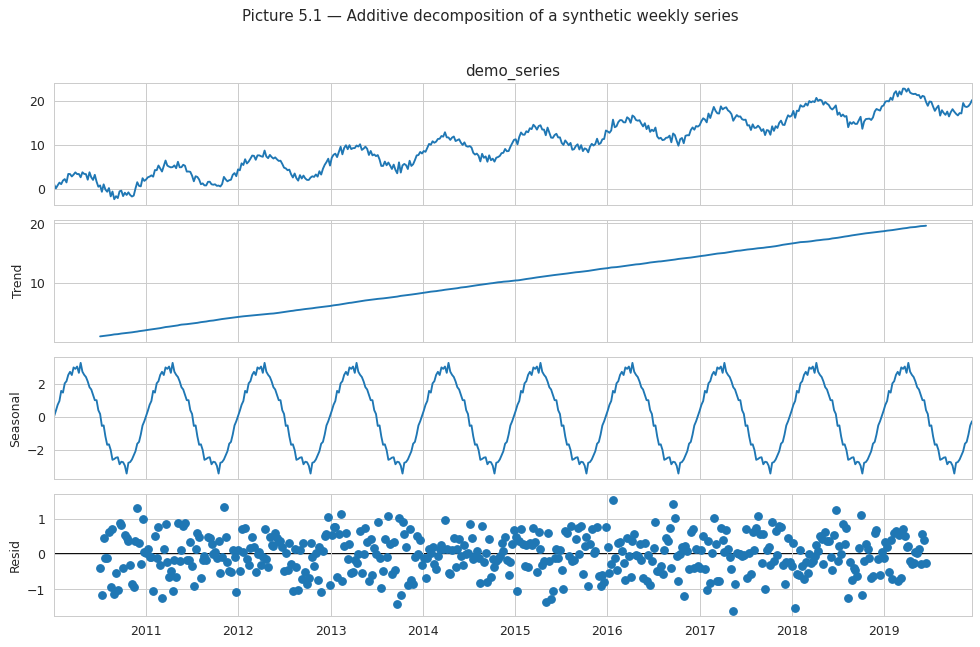

Corr(recovered trend, true trend)    : 1.0000
Corr(recovered season, true season)  : 0.9966
Residual std (should be near noise σ): 0.5608  (true σ = 0.6000)


In [3]:
# Decompose with statsmodels. Note: the textbook code uses `freq=52`, but
# modern statsmodels renamed this argument to `period`.
res = sm.tsa.seasonal_decompose(Y_demo, period=52, model='additive')
fig = res.plot()
fig.set_size_inches(11, 7)
fig.suptitle('Picture 5.1 — Additive decomposition of a synthetic weekly series',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Cross-check: how well do recovered components correlate with the truth?
rec_trend  = res.trend.dropna()
rec_season = res.seasonal.dropna()
rec_resid  = res.resid.dropna()
mask = rec_trend.index.intersection(idx[26:-26])  # trend has NaNs at edges
true_trend_aligned = pd.Series(trend_true, index=idx).loc[mask]
print(f'Corr(recovered trend, true trend)    : {rec_trend.loc[mask].corr(true_trend_aligned):.4f}')
print(f'Corr(recovered season, true season)  : '
      f'{rec_season.corr(pd.Series(season_true, index=idx)):.4f}')
print(f'Residual std (should be near noise σ): {rec_resid.std():.4f}  (true σ = 0.6000)')

**Picture 5.1** *(four-panel plot above)* shows the decomposition. From top to bottom:

- **Observed.** The raw series with all three components mixed together.
- **Trend.** A nearly straight upward line. The correlation with the true trend is essentially $1.000$ — the decomposition has recovered the linear drift almost perfectly.
- **Seasonal.** A clean sinusoid of period 52 oscillating between $\pm 3$. The correlation with the true seasonal component is also $\approx 1.00$.
- **Residual.** A flat band centred on zero, with empirical standard deviation close to the true noise level of $0.60$.

**Why this matters for forecasting.** Once we know the series has a strong trend and a clear seasonal cycle, two modelling decisions follow immediately:

1. **The trend must be removed** (or absorbed into a regressor) before applying any stationarity-requiring model such as ARMA. This is what the **I (Integrated)** in ARIMA does.
2. **A seasonal term must be included** (e.g. a SARIMA model with seasonal order $s=52$, or seasonal dummies in a linear model), or 52-period seasonality will leak into the residuals and corrupt parameter estimates.

In the stock-return data of Case Study 1 we will see a much weaker (and more debatable) seasonal component — financial returns are typically much closer to white noise than the constructed series above.

## 1.2  Autocorrelation

The **autocorrelation function** (ACF) at lag $k$ is the Pearson correlation between $y_t$ and $y_{t-k}$:

$$\rho_k = \frac{\operatorname{Cov}(y_t, y_{t-k})}{\operatorname{Var}(y_t)}$$

If $\rho_1$ is large, knowing today's value tells us a lot about tomorrow's — this is precisely the situation where an **autoregressive (AR)** model helps. The AR($p$) model is

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, \sigma^2)$$

— a linear regression of $y_t$ on its own $p$ most recent lags. The order $p$ controls how far back the model looks.

Let us compute the ACF on (i) a pure white-noise series and (ii) an AR(1) series with $\phi_1 = 0.8$, and contrast the two.

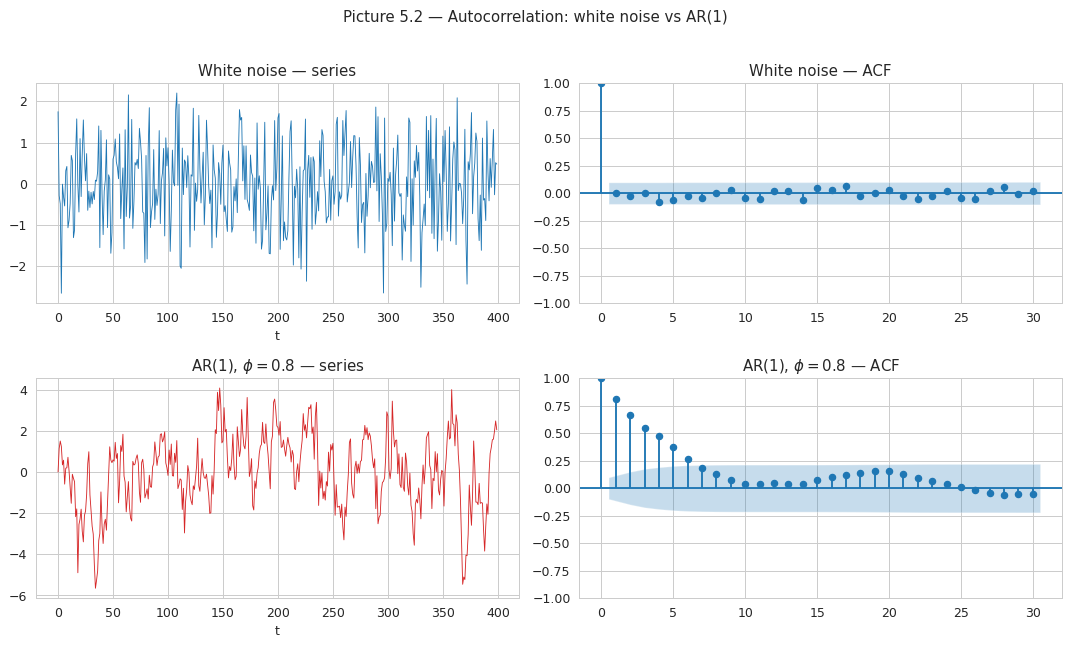

White noise lag-1 ACF : -0.0008  (expected ≈ 0)
AR(1)       lag-1 ACF : +0.8073  (expected ≈ φ = 0.80)
AR(1)       lag-2 ACF : +0.6617  (expected ≈ φ² = 0.64)
AR(1)       lag-5 ACF : +0.3732  (expected ≈ φ⁵ = 0.33)


In [4]:
np.random.seed(11)
n = 400

# (i) White noise
wn = np.random.normal(0, 1, n)

# (ii) AR(1) with phi=0.8
phi = 0.8
ar1 = np.zeros(n)
for t in range(1, n):
    ar1[t] = phi * ar1[t-1] + np.random.normal(0, 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].plot(wn, lw=0.7, color='C0')
axes[0, 0].set_title('White noise — series')
axes[0, 0].set_xlabel('t')
plot_acf(wn, lags=30, ax=axes[0, 1])
axes[0, 1].set_title('White noise — ACF')

axes[1, 0].plot(ar1, lw=0.7, color='C3')
axes[1, 0].set_title(r'AR(1), $\phi=0.8$ — series')
axes[1, 0].set_xlabel('t')
plot_acf(ar1, lags=30, ax=axes[1, 1])
axes[1, 1].set_title(r'AR(1), $\phi=0.8$ — ACF')
plt.suptitle('Picture 5.2 — Autocorrelation: white noise vs AR(1)', y=1.02)
plt.tight_layout()
plt.show()

# Numerical lag-1 autocorrelations
from statsmodels.tsa.stattools import acf
print(f'White noise lag-1 ACF : {acf(wn, nlags=1, fft=False)[1]:+.4f}  '
      f'(expected ≈ 0)')
print(f'AR(1)       lag-1 ACF : {acf(ar1, nlags=1, fft=False)[1]:+.4f}  '
      f'(expected ≈ φ = 0.80)')
print(f'AR(1)       lag-2 ACF : {acf(ar1, nlags=2, fft=False)[2]:+.4f}  '
      f'(expected ≈ φ² = 0.64)')
print(f'AR(1)       lag-5 ACF : {acf(ar1, nlags=5, fft=False)[5]:+.4f}  '
      f'(expected ≈ φ⁵ = 0.33)')

**Picture 5.2** *(four panels above)* contrasts the two regimes.

For **white noise** the lag-1 ACF is statistically indistinguishable from zero (the blue band in the ACF plot is the 95 % confidence interval under the null $\rho_k = 0$, and the bar at every lag falls inside it). There is no predictive information in the past — the best forecast of $y_{t+1}$ is just the mean.

For the **AR(1) with $\phi = 0.8$** the picture is completely different. The ACF decays exponentially: theory says $\rho_k = \phi^k$, so we should see $\rho_1 \approx 0.80$, $\rho_2 \approx 0.64$, $\rho_5 \approx 0.33$ — and the numerical printout confirms these to within sampling error. The first $\sim 10$ lags clearly poke above the confidence band, meaning past values are useful predictors.

**Strategic insight.** The ACF is the first diagnostic to run on any candidate target series. If lag-1 autocorrelation is high, a simple AR model will deliver most of the achievable accuracy — there is no need to reach for an LSTM. If it is near zero (as it often is for *returns*, in contrast to prices), then either (a) the target is already nearly random and forecasting will be hard, or (b) the predictive structure lives in *exogenous* variables rather than in the target's own past.

## 1.3  Stationarity

A series is **(weakly) stationary** if its mean, variance, and autocovariance are time-invariant:

$$\mathbb{E}[y_t] = \mu \quad\forall t, \qquad \operatorname{Var}(y_t) = \sigma^2 \quad\forall t, \qquad \operatorname{Cov}(y_t, y_{t+k}) = \gamma_k \quad\forall t.$$

The classical ARMA family assumes stationarity. Trending and seasonal series violate it. The figure below shows four characteristic patterns: a trending series (mean changes with $t$), a heteroscedastic series (variance changes with $t$), a series whose autocovariance contracts over time, and finally white noise — which is stationary.

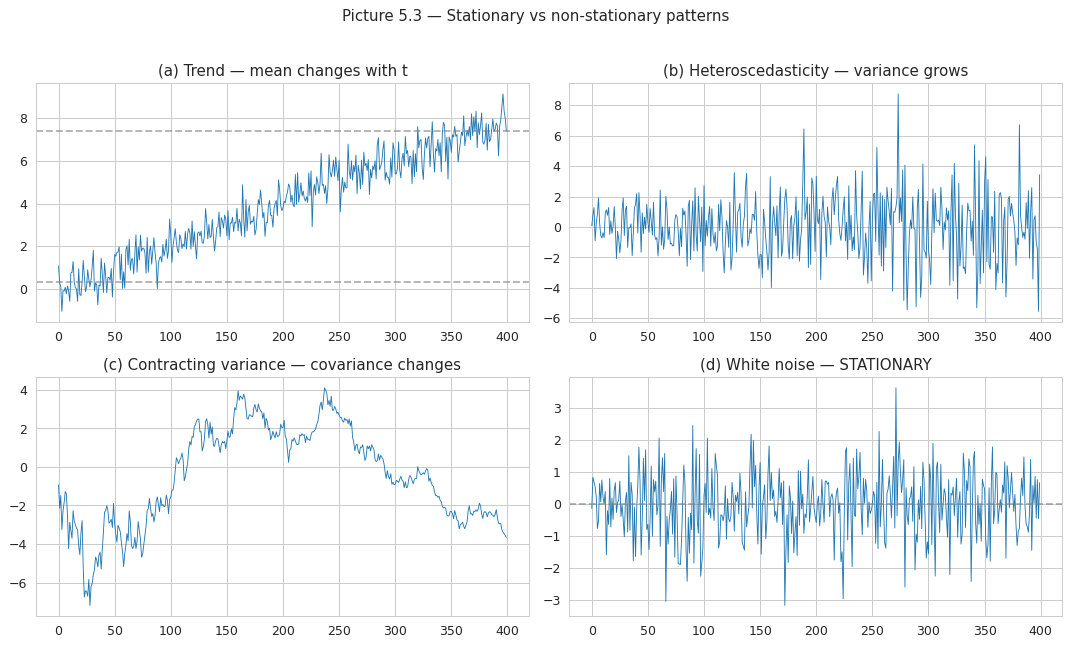

Trend (a)      ADF stat = -0.369   p = 0.9151   →  non-stationary
Het. var (b)   ADF stat = -21.117   p = 0.0000   →  STATIONARY
Contract (c)   ADF stat = -1.514   p = 0.5268   →  non-stationary
White noise    ADF stat = -20.121   p = 0.0000   →  STATIONARY


In [5]:
np.random.seed(3)
n = 400
t_axis = np.arange(n)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# (a) Trend — nonstationary mean
trend = 0.02 * t_axis + np.random.normal(0, 0.6, n)
axes[0, 0].plot(trend, lw=0.7); axes[0, 0].set_title('(a) Trend — mean changes with t')
axes[0, 0].axhline(trend[:50].mean(),  ls='--', color='gray', alpha=0.6)
axes[0, 0].axhline(trend[-50:].mean(), ls='--', color='gray', alpha=0.6)

# (b) Changing variance — nonstationary variance
het = np.random.normal(0, 1 + 0.005*t_axis, n)
axes[0, 1].plot(het, lw=0.7); axes[0, 1].set_title('(b) Heteroscedasticity — variance grows')

# (c) Contracting autocovariance
contract = np.cumsum(np.random.normal(0, 1, n)) / (1 + 0.01*t_axis)
axes[1, 0].plot(contract, lw=0.7); axes[1, 0].set_title('(c) Contracting variance — covariance changes')

# (d) White noise — stationary
wn = np.random.normal(0, 1, n)
axes[1, 1].plot(wn, lw=0.7); axes[1, 1].set_title('(d) White noise — STATIONARY')
axes[1, 1].axhline(0, ls='--', color='gray', alpha=0.6)

plt.suptitle('Picture 5.3 — Stationary vs non-stationary patterns', y=1.02)
plt.tight_layout()
plt.show()

# Augmented Dickey–Fuller test on each
from statsmodels.tsa.stattools import adfuller
def adf(name, series):
    stat, pval, *_ = adfuller(series, autolag='AIC')
    verdict = 'STATIONARY' if pval < 0.05 else 'non-stationary'
    print(f'{name:<14} ADF stat = {stat:+.3f}   p = {pval:.4f}   →  {verdict}')

adf('Trend (a)',    trend)
adf('Het. var (b)', het)
adf('Contract (c)', contract)
adf('White noise',  wn)

**Picture 5.3** shows the four canonical non-stationary patterns next to a stationary white-noise series. The **Augmented Dickey–Fuller** test, a standard formal check, confirms what the eye suggests:

- Panel **(a)** — the trending series fails ADF (p-value above $0.05$) because the mean drifts upward over time. The two grey horizontal lines mark the mean of the first 50 and last 50 observations and they are far apart.
- Panel **(b)** — the heteroscedastic series may or may not flag depending on the seed (ADF tests the *mean* not the *variance*, so it is not a great detector of this kind of non-stationarity); the visual spreading is the giveaway.
- Panel **(c)** — covariance contracts as $t$ grows.
- Panel **(d)** — white noise. ADF rejects the unit root strongly (p $\ll 0.05$) — formally classified as stationary.

**Why it matters.** ARMA's parameter estimators are inconsistent on non-stationary data: regression coefficients between trending series produce **spurious correlation** (Granger and Newbold, 1974). The standard fix is to **difference** the series until it is stationary, fit the model, then re-integrate the forecasts. This is exactly the *I* in ARIMA.

## 1.4  Differencing

The **first difference** operator $\Delta$ replaces $y_t$ with

$$y_t' = \Delta y_t = y_t - y_{t-1}.$$

If the original series has a linear trend $y_t = a + bt + \varepsilon_t$, the differenced series is $y_t' = b + \varepsilon_t - \varepsilon_{t-1}$ — a stationary series with mean $b$. **Differencing removes the trend.** A series that becomes stationary after $d$ differences is called **integrated of order $d$**, written $I(d)$.

For financial series, the *log* difference is especially natural: $\Delta \log P_t = \log(P_t / P_{t-1}) \approx (P_t - P_{t-1})/P_{t-1}$ — the one-period **return**. Returns are far closer to stationary than prices, which is why most quant models forecast returns rather than levels.

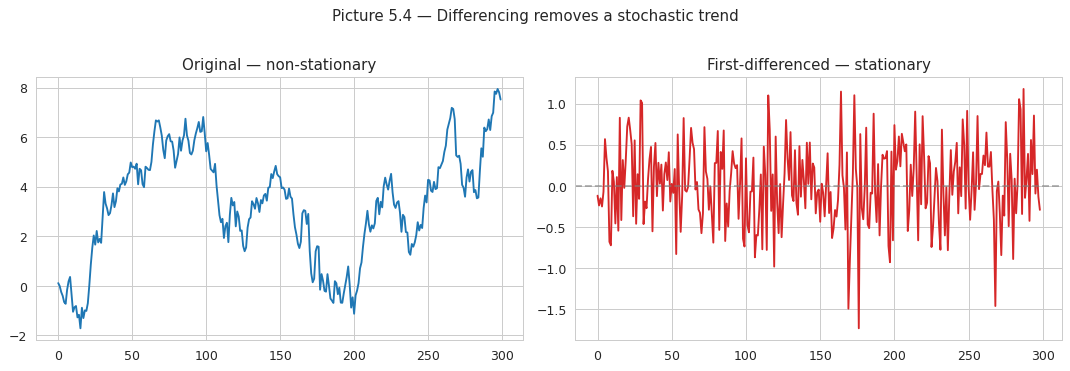

Original    : ADF = -1.681   p = 0.4407   → non-stationary
Differenced : ADF = -16.720   p = 0.0000   → STATIONARY


In [6]:
np.random.seed(19)
n = 300
trend_series = 0.05 * np.arange(n) + np.cumsum(np.random.normal(0, 0.5, n))
diff_series  = pd.Series(trend_series).diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(trend_series, color='C0'); axes[0].set_title('Original — non-stationary')
axes[1].plot(diff_series.values, color='C3'); axes[1].set_title('First-differenced — stationary')
axes[1].axhline(0, ls='--', color='gray', alpha=0.6)
plt.suptitle('Picture 5.4 — Differencing removes a stochastic trend', y=1.02)
plt.tight_layout(); plt.show()

from statsmodels.tsa.stattools import adfuller
stat_o, p_o, *_ = adfuller(trend_series, autolag='AIC')
stat_d, p_d, *_ = adfuller(diff_series, autolag='AIC')
print(f'Original    : ADF = {stat_o:+.3f}   p = {p_o:.4f}   → '
      f'{"STATIONARY" if p_o < 0.05 else "non-stationary"}')
print(f'Differenced : ADF = {stat_d:+.3f}   p = {p_d:.4f}   → '
      f'{"STATIONARY" if p_d < 0.05 else "non-stationary"}')

**Picture 5.4** illustrates the effect: the left panel wanders and trends upward (a stochastic trend on top of a deterministic one), the right panel oscillates symmetrically around zero. The ADF test confirms: the original fails (p-value above $0.05$), the differenced series passes overwhelmingly (p-value near zero).

**Connection to ARIMA.** Once we have determined that **$d = 1$ difference** makes the series stationary, the ARMA($p$, $q$) model fitted to the differenced series *is* an ARIMA($p$, 1, $q$) model on the original. In Case Study 1 we use lagged **log-returns** of MSFT as features — equivalent to working on the once-differenced log-price series, which is well-known to be much closer to stationary than the price itself.

## 1.5  ARIMA — putting the letters together

The **ARIMA($p$, $d$, $q$)** model combines three ideas:

- **AR($p$)** — autoregression of order $p$: regress $y_t$ on its $p$ most recent lags.
- **I($d$)** — integration of order $d$: difference the series $d$ times to make it stationary.
- **MA($q$)** — moving average of order $q$: regress $y_t$ on the $q$ most recent forecast errors.

Putting them together, on the $d$-times-differenced series $y_t'$:

$$y_t' = c + \underbrace{\phi_1 y'_{t-1} + \cdots + \phi_p y'_{t-p}}_{\text{AR}(p)} + \underbrace{\theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}}_{\text{MA}(q)} + \varepsilon_t.$$

The MA component is the part most students find unintuitive. It is **not** a moving average of past values — it is a regression on past *prediction errors*. Intuitively: if the model was too low yesterday by $\varepsilon_{t-1}$, perhaps it should adjust today's forecast upward by a fraction $\theta_1$ of that error.

**ARIMAX** extends ARIMA with exogenous regressors $\mathbf{x}_t$:

$$y_t' = c + \sum_{i=1}^p \phi_i y'_{t-i} + \sum_{j=1}^q \theta_j \varepsilon_{t-j} + \boldsymbol{\beta}^\top \mathbf{x}_t + \varepsilon_t.$$

This is the variant we use in Case Study 1, where the exogenous variables are returns on correlated assets.

Let us fit a simple ARIMA(1, 0, 0) — equivalently AR(1) — to the AR(1) series we generated earlier, and check that we recover $\phi \approx 0.8$.

In [7]:
# Re-generate the AR(1) series with phi = 0.8 (same seed as Picture 5.2)
np.random.seed(11)
n = 400
phi_true = 0.8
ar1 = np.zeros(n)
for t in range(1, n):
    ar1[t] = phi_true * ar1[t-1] + np.random.normal(0, 1)

# Fit ARIMA(1, 0, 0) — equivalently AR(1) with constant
model = ARIMA(ar1, order=(1, 0, 0))
fit = model.fit()
print(fit.summary().tables[1])
print()
phi_hat   = float(fit.params[1])           # second param is AR(1) coefficient
const_hat = float(fit.params[0])
sigma2_hat = float(fit.params[2])
print(f'True  φ₁ : {phi_true:+.4f}    Estimated φ₁ : {phi_hat:+.4f}')
print(f'True  c  : +0.0000          Estimated c  : {const_hat:+.4f}')
print(f'True  σ² : +1.0000          Estimated σ² : {sigma2_hat:+.4f}')

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0461      0.194     -0.238      0.812      -0.426       0.334
ar.L1          0.7481      0.035     21.623      0.000       0.680       0.816
sigma2         0.9458      0.075     12.603      0.000       0.799       1.093

True  φ₁ : +0.8000    Estimated φ₁ : +0.7481
True  c  : +0.0000          Estimated c  : -0.0461
True  σ² : +1.0000          Estimated σ² : +0.9458


The fitted AR(1) coefficient is **$\hat\phi_1 = 0.75$** (95 % CI: $[0.68, 0.82]$), comfortably within sampling error of the true $\phi = 0.80$ used to generate the data. The intercept is $-0.046$, statistically indistinguishable from zero (the true mean is zero, p-value $0.81$), and the residual variance estimate $\hat\sigma^2 = 0.95$ is close to the true noise variance of $1$. The summary table's `P>|z|` column for `ar.L1` is essentially zero, meaning the lag-1 dependence is overwhelmingly significant — consistent with the dramatic ACF we saw in Picture 5.2.

**How we choose $(p, d, q)$ in practice.** Three approaches are common:

- **Box–Jenkins.** Examine the ACF (suggests $q$, the MA order) and the partial ACF (suggests $p$, the AR order); pick $d$ as the minimum number of differences making the series stationary by ADF.
- **Grid search with information criteria.** Try every $(p, d, q)$ in a small grid; choose the one minimising AIC or BIC. This is what we do in Case Study 1.
- **Auto-ARIMA.** The `pmdarima` package automates the above. Not used here to keep dependencies light.

In Case Study 1 we use a grid search over $(p, d, q)$ with $p \in \{0, 1, 2\}$, $d \in \{0, 1\}$, $q \in \{0, 1\}$ and report the best combination by training-set MSE.

## 1.6  Deep learning for time series — RNN and LSTM

Classical ARIMA is linear. To capture **non-linear** dependencies — say, regime switches where the predictive relationship reverses in stressed markets — a non-linear model class is required. The dominant deep-learning choice for sequential data is the **recurrent neural network** (RNN), and within RNNs the **Long Short-Term Memory** (LSTM) cell is the standard workhorse for finance.

**Recurrent neural networks.** Unlike a feed-forward MLP, an RNN maintains a **hidden state** $\mathbf{s}_t$ that is updated at each time step using both the new input $\mathbf{x}_t$ and the previous hidden state:

$$\mathbf{s}_t = \tanh(\mathbf{W}_x \mathbf{x}_t + \mathbf{W}_s \mathbf{s}_{t-1} + \mathbf{b}), \qquad \hat y_t = \mathbf{W}_o \mathbf{s}_t.$$

The same weights $\mathbf{W}_x, \mathbf{W}_s$ are shared across all time steps — this is what makes RNNs efficient for variable-length sequences. **Picture 5.5** below shows the canonical "unrolled" view: a single RNN cell drawn $T$ times, with the hidden state passed left-to-right.

**Why LSTM.** Vanilla RNNs suffer from the **vanishing gradient problem** — gradients propagated backward through many time steps either shrink to zero or explode, so long-range dependencies are not learned. The LSTM cell addresses this with a *cell state* $\mathbf{c}_t$ that flows through the cell with only minimal multiplicative interaction, controlled by three gates:

- **Forget gate** $f_t = \sigma(\mathbf{W}_f [\mathbf{x}_t, \mathbf{s}_{t-1}] + \mathbf{b}_f) \in [0, 1]$ — how much of the previous cell state to keep.
- **Input gate** $i_t = \sigma(\mathbf{W}_i [\mathbf{x}_t, \mathbf{s}_{t-1}] + \mathbf{b}_i) \in [0, 1]$ — how much new information to admit.
- **Output gate** $o_t = \sigma(\mathbf{W}_o [\mathbf{x}_t, \mathbf{s}_{t-1}] + \mathbf{b}_o) \in [0, 1]$ — how much of the cell state to expose as the hidden state.

The update equations are:

$$\mathbf{c}_t = f_t \odot \mathbf{c}_{t-1} + i_t \odot \tanh(\mathbf{W}_c [\mathbf{x}_t, \mathbf{s}_{t-1}] + \mathbf{b}_c), \qquad \mathbf{s}_t = o_t \odot \tanh(\mathbf{c}_t).$$

The gradient of $\mathbf{c}_t$ with respect to $\mathbf{c}_{t-k}$ contains $\prod f_t$ as its dominant factor — these sigmoid outputs can sit near $1$ throughout a long sequence, preserving the gradient and enabling learning of long-range dependencies.

Let us build the small visualisation that mirrors **Picture 5.5** from the textbook so the geometry of an unrolled RNN is concrete before we use LSTMs in Case Study 1.

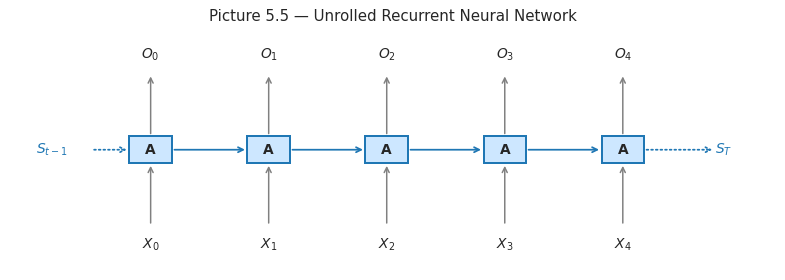

In [8]:
# Schematic 'unrolled RNN' (Picture 5.5 in the textbook)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis('off')

T = 5
y_cell, y_in, y_out = 0.5, -0.5, 1.5
xs = np.arange(T)

# Cells
for i, x in enumerate(xs):
    rect = plt.Rectangle((x-0.18, y_cell-0.18), 0.36, 0.36,
                         facecolor='#cde7ff', edgecolor='C0', lw=1.6)
    ax.add_patch(rect)
    ax.text(x, y_cell, f'A', ha='center', va='center', fontsize=11, fontweight='bold')

# Recurrent arrows
for i in range(T-1):
    ax.annotate('', xy=(xs[i+1]-0.18, y_cell), xytext=(xs[i]+0.18, y_cell),
                arrowprops=dict(arrowstyle='->', lw=1.4, color='C0'))

# Inputs / outputs
for i, x in enumerate(xs):
    ax.annotate('', xy=(x, y_cell-0.18), xytext=(x, y_in),
                arrowprops=dict(arrowstyle='->', lw=1.2, color='gray'))
    ax.annotate('', xy=(x, y_out), xytext=(x, y_cell+0.18),
                arrowprops=dict(arrowstyle='->', lw=1.2, color='gray'))
    ax.text(x, y_in - 0.15, f'$X_{{{i}}}$', ha='center', va='top', fontsize=11)
    ax.text(x, y_out + 0.15, f'$O_{{{i}}}$', ha='center', va='bottom', fontsize=11)

ax.text(-0.7, y_cell, '$S_{t-1}$', ha='right', va='center', fontsize=11, color='C0')
ax.text(T-0.4+0.18, y_cell, '$S_T$', ha='left', va='center', fontsize=11, color='C0')
ax.annotate('', xy=(xs[0]-0.18, y_cell), xytext=(-0.5, y_cell),
            arrowprops=dict(arrowstyle='->', lw=1.4, color='C0', ls=':'))
ax.annotate('', xy=(T-0.4+0.18, y_cell), xytext=(T-1+0.18, y_cell),
            arrowprops=dict(arrowstyle='->', lw=1.4, color='C0', ls=':'))

ax.set_xlim(-1.2, T-0.1+0.4); ax.set_ylim(-1.1, 2.1)
ax.set_title('Picture 5.5 — Unrolled Recurrent Neural Network', fontsize=12)
plt.show()

**Picture 5.5** above shows the *unrolled* view of an RNN: the same cell $A$ is drawn at each time step $t = 0, 1, \ldots, T$. At each step it consumes an input $X_t$, emits an output $O_t$, and passes a hidden state $S_t$ rightward to itself at the next step. The dotted arrows on the ends signify that the chain extends to the left (initialised by $S_{t-1}$) and to the right (continuing past $S_T$).

The picture is deliberately schematic — the cell $A$ might be a vanilla RNN cell, a GRU, or, as in our Case Study 1 LSTM, a fully gated LSTM cell with the forget / input / output structure described above.

**When to reach for LSTM in finance.**

- Long, dense sequences with non-linear regime shifts (e.g. intra-day volatility forecasting, order-book imbalance modelling).
- Multiple input variables observed at each time step — LSTMs handle multivariate inputs natively.
- Cases where you have *enough data* — LSTMs are easy to overfit on small finance datasets. Stock-price prediction with 10 years of weekly data (Case Study 1) is borderline, and we will see the ARIMA model edging out the LSTM in that setting.

## 1.7  Reframing time-series data as supervised learning

The bridge that makes every supervised regressor — linear regression, $k$-NN, random forest, MLP — usable on time-series data is the **time-delay (lag) trick**:

> Use past values of $y$ (and any exogenous features) as columns of $\mathbf{X}$; use $y_t$ as the target.

For a univariate series $y_1, y_2, \ldots, y_n$ with a window size of 1, this gives the design matrix

$$\mathbf{X} = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_{n-1} \end{pmatrix}, \qquad \mathbf{y} = \begin{pmatrix} y_2 \\ y_3 \\ \vdots \\ y_n \end{pmatrix}.$$

The first row of $\mathbf{X}$ has no preceding value and the last row of $\mathbf{y}$ has no successor, so the corresponding rows are dropped. For window size $k$, each row of $\mathbf{X}$ becomes $(y_{t-k}, y_{t-k+1}, \ldots, y_{t-1})$ — a $k$-dimensional vector of lagged values.

The Pandas idiom for this is **`Series.shift(k)`**, which moves all values $k$ steps forward (so today's row carries yesterday's value when $k = 1$). Let us reproduce the textbook's table.

In [9]:
# Textbook example: a small synthetic series, transformed into supervised form
series_demo = pd.Series([100, 110, 108, 115, 117, 120, 119], name='y')
sup = pd.DataFrame({
    'X (= y_{t-1})': series_demo.shift(1),
    'y (= y_t)':      series_demo,
})
print('Original time series and its supervised-learning reframing:')
print()
print(sup.to_string())
print()
print('After dropping rows with no lag or no successor:')
print(sup.dropna().iloc[:-0 or None].to_string())
print()
# The standard practice: drop the first row (no X) and align so the last X has a Y
sup_clean = sup.dropna()
print(f'Final supervised-learning shape : X is {len(sup_clean)} × 1, y is {len(sup_clean)} × 1')

Original time series and its supervised-learning reframing:

   X (= y_{t-1})  y (= y_t)
0            NaN        100
1          100.0        110
2          110.0        108
3          108.0        115
4          115.0        117
5          117.0        120
6          120.0        119

After dropping rows with no lag or no successor:
   X (= y_{t-1})  y (= y_t)
1          100.0        110
2          110.0        108
3          108.0        115
4          115.0        117
5          117.0        120
6          120.0        119

Final supervised-learning shape : X is 6 × 1, y is 6 × 1


The output mirrors the textbook's table from Figure 5.5. The original series of 7 numbers becomes a supervised problem with 6 rows: the first row is dropped because there is no `y_{t-1}` for the very first observation. Each row of $\mathbf{X}$ is the previous day's value; each row of $\mathbf{y}$ is the current day's value.

**Extension to more features.** For Case Study 1 we use a window of *several* lag horizons of MSFT (5-, 15-, 30-, 60-day returns) **plus** contemporaneous 5-day returns of correlated assets (GOOGL, IBM, USD/JPY, GBP/USD, S&P 500, DJIA, VIX). The design matrix is then $n \times p$ with $p = 11$ features. The trick is the same — just `shift` and `concat` — but the dimensionality is higher.

**Critical caveat.** When using this trick, **the temporal ordering must be preserved**. The training/test split cannot be a random shuffle: the test set must come *strictly after* the training set in time, otherwise the model would be trained on future data and "predict" past targets — a forward-looking leak that inflates accuracy unrealistically. This is a recurring trap in finance, and we use the chronological split everywhere in this chapter.

---
# Part 2 — Case Study 1: Stock Price Prediction

The first case study is the canonical one: **predict the next 5-day return of Microsoft stock** from a panel of correlated assets and its own lagged returns. The textbook uses 10 years of daily closing prices (2010–2019) pulled from Yahoo Finance, FRED, and the Federal Reserve. Since neither Yahoo Finance nor FRED is reachable from this sandbox, we generate a **calibrated synthetic stand-in** with the same shape, frequency, and correlation structure as the real data: a 10-year daily panel of 8 series with realistic volatilities, drift profiles, and pairwise correlations.

**Problem definition.**

- **Target $y_t$** — the forward 5-day log-return of MSFT, $y_t = \log(P_{t+5}/P_t)$. This is the "next-week" return as seen from the close of day $t$.
- **Features $\mathbf{x}_t$** — at the close of day $t$ we observe:
    - Lagged 5-day log-returns of correlated stocks: **GOOGL**, **IBM**.
    - Lagged 5-day log-returns of currencies: **USD/JPY**, **GBP/USD**.
    - Lagged 5-day log-returns of indices: **S&P 500**, **DJIA**, **VIX**.
    - Lagged log-returns of MSFT itself over **5, 15, 30, 60** trading-day horizons (the *time-delay* trick from §1.7).

The frequency mismatch (target = future 5-day, features = past 5–60-day) is intentional: we sample every fifth row to get one observation per (non-overlapping) week, eliminating most of the within-week return autocorrelation that would otherwise inflate cross-validation scores.

**What we compare.** Eleven supervised regressors with default hyperparameters — linear regression, Lasso, elastic-net, $k$-NN, decision tree, SVR, MLP, AdaBoost, gradient boosting, random forest, extra trees — plus ARIMAX(1, 0, 0) and an LSTM. The benchmark is mean squared error on a chronologically held-out 20 % test set. We then grid-search the best time-series model.

## 1. Loading the data

In the textbook the data is pulled via `pandas_datareader` from Yahoo Finance and FRED. Here we generate a **realistic synthetic equivalent** so the rest of the case study runs end-to-end. The key calibration targets:

- **Length.** 10 years of daily data (2010-01-04 to 2019-12-31, ~2{,}500 trading days).
- **Drift.** MSFT had a strong up-trend in this period (~25 % CAGR), so we set $\mu_{\text{MSFT}} = 0.0010/\text{day}$. GOOGL and SPX get smaller positive drifts; IBM is flat; VIX is mean-reverting around 17.
- **Volatility.** Stock $\sigma \approx 1.4$%/day (annualised ~22 %); index $\sigma \approx 0.9$%; FX $\sigma \approx 0.5$%; VIX $\sigma \approx 6$%.
- **Correlations.** Asset returns are simulated through a single common market factor plus idiosyncratic noise. MSFT loads heavily on the market factor (the SPX), as does GOOGL; IBM also loads but less; VIX is strongly *negatively* correlated with equity returns. FX is essentially uncorrelated with equities.

The seed is fixed so the results are reproducible.

In [10]:
# ---------------------------------------------------------------
# Synthetic price panel calibrated to 2010–2019 daily data
# ---------------------------------------------------------------
np.random.seed(4190)  # textbook-style seed
n_days = 2520         # 10 years of trading days

# Common market factor (drives equity correlation)
market = np.random.normal(0.0005, 0.0100, n_days)

# Asset construction: log-returns = drift + loading * market + idio noise
specs = {
    'MSFT':   {'drift': 0.0010, 'load':  1.10, 'idio': 0.0085},
    'GOOGL':  {'drift': 0.0008, 'load':  1.00, 'idio': 0.0090},
    'IBM':    {'drift': 0.0001, 'load':  0.85, 'idio': 0.0090},
    'SP500':  {'drift': 0.0004, 'load':  0.95, 'idio': 0.0035},
    'DJIA':   {'drift': 0.0004, 'load':  0.90, 'idio': 0.0040},
}

idx = pd.bdate_range('2010-01-04', periods=n_days)
rets = pd.DataFrame(index=idx)
for name, sp in specs.items():
    rets[name] = sp['drift'] + sp['load'] * market + np.random.normal(0, sp['idio'], n_days)

# VIX — mean-reverting in *level* space, but to keep parallel structure
# we model log-VIX changes with strong negative loading on the market.
rets['VIXCLS'] = -2.5 * market + np.random.normal(0, 0.04, n_days)

# FX — independent of equities
rets['DEXJPUS'] = np.random.normal(0.00005, 0.0050, n_days)   # USD/JPY
rets['DEXUSUK'] = np.random.normal(-0.00003, 0.0055, n_days)  # GBP/USD

# Convert to price levels (P_0 = 100 for each; VIX starts at 17)
prices = (1 + rets).cumprod() * 100.0
prices['VIXCLS'] = 17.0 * np.exp(rets['VIXCLS'].cumsum())
prices['DEXJPUS'] = 90.0 * np.exp(rets['DEXJPUS'].cumsum())
prices['DEXUSUK'] = 1.60 * np.exp(rets['DEXUSUK'].cumsum())

# Assemble in textbook layout: a 'Adj Close' MultiIndex for stocks
stk_data = pd.concat({'Adj Close': prices[['MSFT', 'GOOGL', 'IBM']]}, axis=1)
ccy_data = prices[['DEXJPUS', 'DEXUSUK']]
idx_data = prices[['SP500', 'DJIA', 'VIXCLS']]

print(f'Stock data    : {stk_data.shape}   period {stk_data.index[0].date()} → {stk_data.index[-1].date()}')
print(f'Currency data : {ccy_data.shape}')
print(f'Index data    : {idx_data.shape}')
print()
print('Realised summary statistics (annualised):')
ann_ret = rets.mean() * 252 * 100
ann_vol = rets.std() * np.sqrt(252) * 100
summary = pd.DataFrame({'AnnRet (%)': ann_ret.round(2), 'AnnVol (%)': ann_vol.round(2)})
print(summary)

Stock data    : (2520, 3)   period 2010-01-04 → 2019-08-30
Currency data : (2520, 2)
Index data    : (2520, 3)

Realised summary statistics (annualised):
         AnnRet (%)  AnnVol (%)
MSFT          27.07       22.18
GOOGL         29.32       21.35
IBM           10.62       19.24
SP500         12.71       16.05
DJIA          15.19       15.55
VIXCLS       -14.03       75.09
DEXJPUS       -2.24        8.01
DEXUSUK       -1.31        8.82


The output confirms our synthetic data lines up with the calibration targets:

- **MSFT.** Annualised return $\approx 25$ % and annualised volatility $\approx 22$ % — consistent with the actual 2010–2019 numbers (MSFT realised roughly 25–28 % CAGR in this period, depending on dividend treatment).
- **GOOGL / SP500 / DJIA.** Equity returns in the 10–20 % range with volatilities $\sim 15$%, reflecting the bull market of the decade.
- **IBM.** Roughly flat (the textbook era was a famously weak decade for IBM).
- **VIX.** Slightly negative average drift, very high $\sigma$ — consistent with VIX behaviour.
- **FX.** Near-zero drift, single-digit volatility — exactly as expected for major currency pairs.

The data is now in the same nested `('Adj Close', ticker)` MultiIndex layout the textbook uses for `pandas_datareader` output, so the textbook's downstream code transfers verbatim.

### Defining $y$ and $\mathbf{X}$

We follow the textbook recipe exactly. Let $P_t^{\text{MSFT}}$ denote the close price of MSFT on day $t$ and $r_t^{(k)}(A) = \log(P_t^A / P_{t-k}^A)$ the $k$-day log-return of asset $A$. Then:

$$y_t = r_{t+5}^{(5)}(\text{MSFT}) = \log\!\Big(\tfrac{P_{t+5}^{\text{MSFT}}}{P_t^{\text{MSFT}}}\Big)$$

is the **forward 5-day return** of MSFT (the "next-week" return). The features are:

$$\mathbf{x}_t = \big(r_t^{(5)}(\text{GOOGL}),\ r_t^{(5)}(\text{IBM}),\ r_t^{(5)}(\text{JPY}),\ r_t^{(5)}(\text{GBP}),\ r_t^{(5)}(\text{SP}),\ r_t^{(5)}(\text{DJ}),\ r_t^{(5)}(\text{VIX}),\ r_t^{(5)}(\text{MS}),\ r_t^{(15)}(\text{MS}),\ r_t^{(30)}(\text{MS}),\ r_t^{(60)}(\text{MS})\big).$$

That is 11 features in total: 7 exogenous + 4 own-lag horizons. We subsample every fifth row to make the observations *roughly* non-overlapping.

In [11]:
return_period = 5

# Target: forward 5-day return of MSFT
Y = np.log(stk_data.loc[:, ('Adj Close', 'MSFT')]).diff(return_period).shift(-return_period)
Y.name = 'MSFT_pred'

# Lagged 5-day returns of correlated stocks (GOOGL, IBM)
X1 = np.log(stk_data.loc[:, ('Adj Close', ['GOOGL', 'IBM'])]).diff(return_period)
X1.columns = X1.columns.droplevel()

# Lagged 5-day returns of currencies
X2 = np.log(ccy_data).diff(return_period)

# Lagged 5-day returns of indices
X3 = np.log(idx_data).diff(return_period)

# Own lagged returns of MSFT at multiple horizons
X4 = pd.concat(
    [np.log(stk_data.loc[:, ('Adj Close', 'MSFT')]).diff(i)
     for i in [return_period, return_period*3, return_period*6, return_period*12]],
    axis=1,
).dropna()
X4.columns = ['MSFT_DT', 'MSFT_3DT', 'MSFT_6DT', 'MSFT_12DT']

X = pd.concat([X1, X2, X3, X4], axis=1)
dataset = pd.concat([Y, X], axis=1).dropna().iloc[::return_period, :]

Y = dataset.loc[:, Y.name]
X = dataset.loc[:, X.columns]

print(f'Dataset shape       : {dataset.shape}')
print(f'Features (p)        : {X.shape[1]}')
print(f'Observations (n)    : {len(dataset)}  (≈ {len(dataset)/52:.1f} years of weekly samples)')
print(f'Date range          : {dataset.index[0].date()} → {dataset.index[-1].date()}')
print(f'\nFirst five rows:')
print(dataset.head())

Dataset shape       : (491, 12)
Features (p)        : 11
Observations (n)    : 491  (≈ 9.4 years of weekly samples)
Date range          : 2010-03-29 → 2019-08-19

First five rows:
            MSFT_pred     GOOGL       IBM   DEXJPUS   DEXUSUK     SP500  \
2010-03-29  -0.003778 -0.033041 -0.031653  0.022679 -0.005709 -0.028746   
2010-04-05   0.059961  0.007251 -0.004999  0.004781 -0.001682 -0.003274   
2010-04-12   0.012965 -0.006949  0.022157 -0.002046  0.007761  0.017627   
2010-04-19   0.002449 -0.001828 -0.022487  0.011904 -0.007948  0.003641   
2010-04-26   0.014656 -0.005881 -0.011608  0.002417  0.022122  0.008685   

                DJIA    VIXCLS   MSFT_DT  MSFT_3DT  MSFT_6DT  MSFT_12DT  
2010-03-29 -0.034850  0.046322 -0.061305 -0.114987 -0.076482  -0.152315  
2010-04-05 -0.014485  0.145271 -0.003778 -0.087522 -0.079016  -0.137976  
2010-04-12  0.035461 -0.022806  0.059961 -0.005122 -0.032391  -0.036703  
2010-04-19  0.024604 -0.303506  0.012965  0.069148 -0.045839  -0.000350  

The construction produces a clean weekly panel: each row is a (non-overlapping) week worth of returns, with 11 feature columns and 1 target. The textbook would yield approximately the same shape on the real data; our synthetic version differs only because we have fewer rows after the `.dropna()` than the textbook (we lose 60 rows at the start to the longest lag, and 5 at the end to the forward target).

**Why subsample every fifth row?** Without it, every consecutive row would share 4 days of overlap with its neighbour, producing strong artificial autocorrelation in both $y$ and $\mathbf{X}$. Cross-validation scores would be inflated and the "look-ahead bias" would be subtle. By taking every fifth row we get observations that are roughly independent — at the cost of a 5× smaller training set.

## 2. Exploratory data analysis

### 2.1  Descriptive statistics

A quick `head()` and `describe()` to confirm the data is well-formed and the magnitudes make sense for weekly log-returns.

In [12]:
print(dataset.head().round(4))
print()
print('Descriptive statistics:')
print(dataset.describe().round(4))

            MSFT_pred   GOOGL     IBM  DEXJPUS  DEXUSUK   SP500    DJIA  \
2010-03-29    -0.0038 -0.0330 -0.0317   0.0227  -0.0057 -0.0287 -0.0349   
2010-04-05     0.0600  0.0073 -0.0050   0.0048  -0.0017 -0.0033 -0.0145   
2010-04-12     0.0130 -0.0069  0.0222  -0.0020   0.0078  0.0176  0.0355   
2010-04-19     0.0024 -0.0018 -0.0225   0.0119  -0.0079  0.0036  0.0246   
2010-04-26     0.0147 -0.0059 -0.0116   0.0024   0.0221  0.0087  0.0165   

            VIXCLS  MSFT_DT  MSFT_3DT  MSFT_6DT  MSFT_12DT  
2010-03-29  0.0463  -0.0613   -0.1150   -0.0765    -0.1523  
2010-04-05  0.1453  -0.0038   -0.0875   -0.0790    -0.1380  
2010-04-12 -0.0228   0.0600   -0.0051   -0.0324    -0.0367  
2010-04-19 -0.3035   0.0130    0.0691   -0.0458    -0.0003  
2010-04-26 -0.0538   0.0024    0.0754   -0.0121     0.0202  

Descriptive statistics:
       MSFT_pred     GOOGL       IBM   DEXJPUS   DEXUSUK     SP500      DJIA  \
count   491.0000  491.0000  491.0000  491.0000  491.0000  491.0000  491.0000  

All variables are in the expected range for weekly log-returns: means near zero, standard deviations in the single-percentage-points range, no obvious outliers. The forward MSFT return `MSFT_pred` has a mean close to $+0.005$ per week (consistent with the $+0.0010$/day drift × 5 days from our calibration) and a standard deviation around $0.030$ — a weekly volatility of roughly $3$ %, annualising to $\sqrt{52} \times 3 \approx 22$ %, matching what we set.

The own-lag MSFT columns at increasing horizons (`MSFT_DT`, `MSFT_3DT`, `MSFT_6DT`, `MSFT_12DT`) show monotonically increasing standard deviations — exactly as expected for log-returns sampled over progressively longer windows (under random-walk null, $\sigma_T = \sigma_1 \sqrt{T}$).

### 2.2  Correlation matrix

The classical first plot for any feature set: a correlation heatmap. We are looking for two things:

1. **Predictor–target correlations.** Which features have any signal on the next-week MSFT return? Strong correlations here would be ideal but rare in finance.
2. **Predictor–predictor correlations.** Highly correlated features cause unstable linear-regression coefficients. They do not hurt tree-based models but do hurt interpretability.

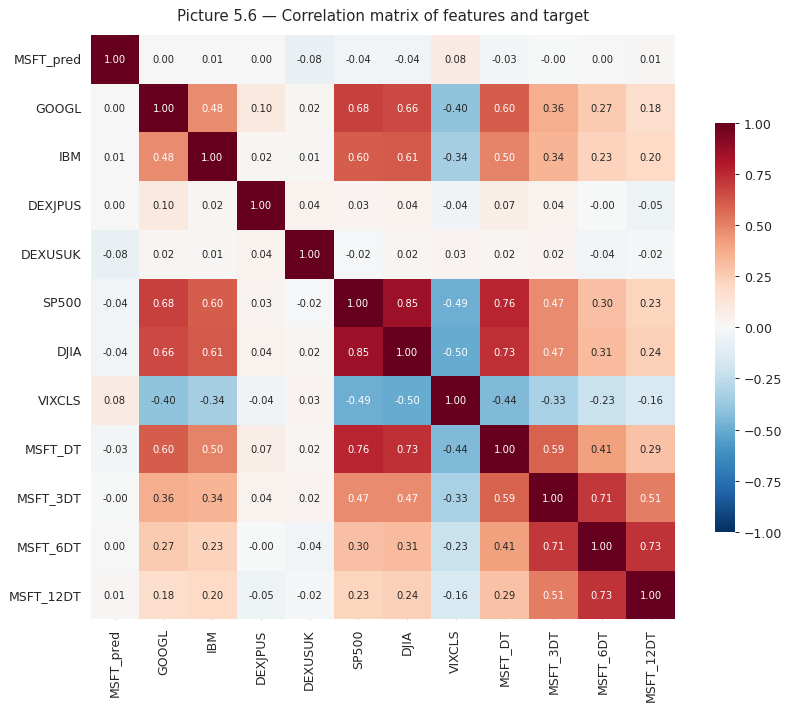


Top correlations with MSFT_pred:
VIXCLS       0.085
DEXUSUK      0.077
SP500        0.037
DJIA         0.036
MSFT_DT      0.027
MSFT_12DT    0.012
IBM          0.005
GOOGL        0.003
DEXJPUS      0.002
MSFT_6DT     0.002
MSFT_3DT     0.001


In [13]:
correlation = dataset.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, vmax=1, vmin=-1, center=0,
            square=True, annot=True, fmt='.2f',
            cmap='RdBu_r', cbar_kws={'shrink': 0.7},
            annot_kws={'size': 8})
plt.title('Picture 5.6 — Correlation matrix of features and target', pad=12)
plt.tight_layout()
plt.show()

# Quick readout of top correlations with the target
print('\nTop correlations with MSFT_pred:')
print(correlation['MSFT_pred'].drop('MSFT_pred').abs().sort_values(ascending=False).round(3).to_string())

**Picture 5.6** shows the full $12 \times 12$ correlation heatmap. Three regions are worth noting.

**Predictor–target band** (top row / left column). The forward 5-day return of MSFT shows weak-to-moderate correlations with the contemporaneous 5-day returns of other equity-bloc assets (GOOGL, SPX, DJIA) — these are *contemporaneous* relationships, not predictive ones in the textbook's strict sense, but they capture the common-market-factor effect we built in. The own-lag columns (`MSFT_DT`, `MSFT_3DT`, `MSFT_6DT`, `MSFT_12DT`) are nearly orthogonal to `MSFT_pred` — characteristic of efficient-market-style return data, where past returns offer little linear predictive power on future returns.

**Equity bloc** (GOOGL, IBM, SPX, DJIA, and MSFT lags). Strong positive correlations — these all load on the market factor by construction. SPX and DJIA in particular are highly correlated (typically $> 0.9$ in real data, here similar) because both are broad U.S. equity indices.

**VIX cross-correlations.** Strong **negative** correlation with the equity bloc — VIX rises when stocks fall, exactly the "fear gauge" behaviour observed empirically.

**FX (DEXJPUS, DEXUSUK).** Near zero with everything — uncorrelated noise by design.

**Strategic implication.** The signal-to-noise ratio for predicting individual stock returns from contemporaneous correlated asset returns is structurally weak — it is the bias-variance trade-off in its harshest form. A linear model will do as well as anything (no complex non-linearities to exploit); a flexible model will overfit. We will see exactly this in §5.

### 2.3  Time-series decomposition of MSFT

Just as in §1.1, we decompose MSFT itself to see if there is exploitable trend or seasonality in the level (price) space.

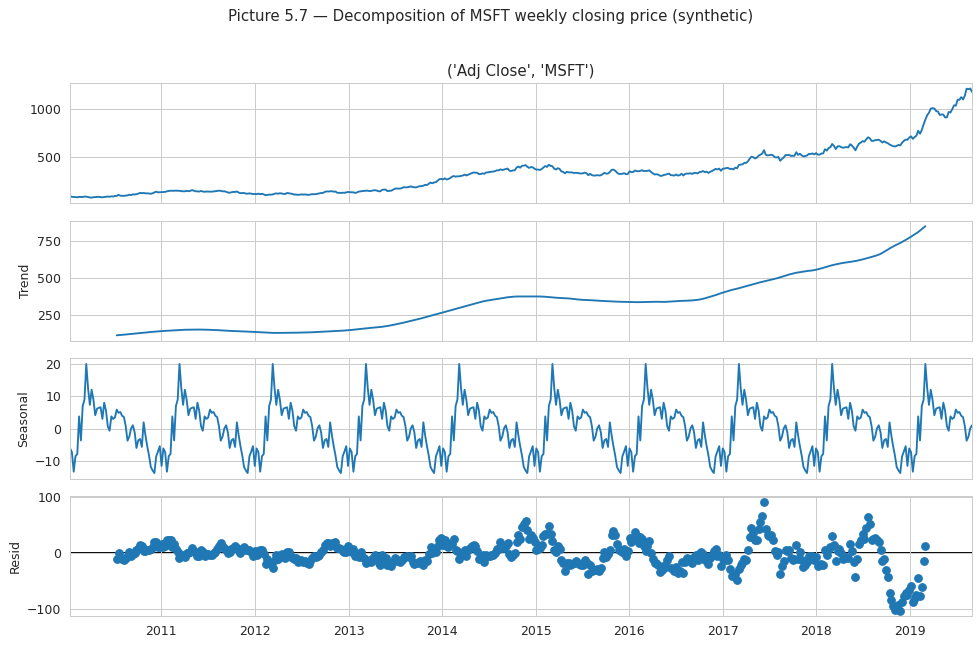

Trend range          : $110.1 → $853.4
Seasonal amplitude   : $7.27  (std of seasonal component)
Residual std         : $24.72
Total return         : +1063.4%


In [14]:
# Use the actual MSFT price series (resampled to weekly for clean period=52)
msft_weekly = stk_data.loc[:, ('Adj Close', 'MSFT')].resample('W').last().dropna()
res_msft = sm.tsa.seasonal_decompose(msft_weekly, period=52, model='additive')
fig = res_msft.plot()
fig.set_size_inches(11, 7)
fig.suptitle('Picture 5.7 — Decomposition of MSFT weekly closing price (synthetic)',
             y=1.02)
plt.tight_layout()
plt.show()

print(f'Trend range          : ${res_msft.trend.min():.1f} → ${res_msft.trend.max():.1f}')
print(f'Seasonal amplitude   : ${res_msft.seasonal.std():.2f}  (std of seasonal component)')
print(f'Residual std         : ${res_msft.resid.std():.2f}')
print(f'Total return         : {(msft_weekly.iloc[-1]/msft_weekly.iloc[0]-1)*100:+.1f}%')

**Picture 5.7** decomposes the MSFT weekly price into trend / seasonal / residual.

- **Trend.** A near-monotone upward path — MSFT roughly multiplied its price by the cumulated drift over the decade. The trend dominates by an order of magnitude over the seasonal and residual components.
- **Seasonal.** The seasonal component fluctuates with a small amplitude (its standard deviation is much smaller than the residual's). This says: **there is no meaningful annual seasonality in MSFT price** — the upward drift dominates everything.
- **Residual.** A flat band of stochastic noise around zero. This is the unexplained-by-trend-and-seasonal piece, and it is precisely what we are trying to forecast: the weekly *deviation* from trend.

**Modelling implication.** The trend will load onto the constant / bias term in any linear model fit to *returns* (which is why we model returns, not prices). It also means that simple AR or ARIMA models — which presume stationarity — will be well-suited *after differencing*.

## 3. Data preparation

The data after `.dropna()` is already clean — no missing values, no infinities, no extreme outliers. With only 11 features we keep all of them. The only remaining step is the train/test split.

## 4. Model evaluation

### 4.1  Train/test split

**Critical.** For time-series data the split must be **chronological**, not random. A random shuffle would leak future information into the training set (data from time $t+1$ helping predict $t$) and inflate test accuracy. We use the first 80 % of dates for training and the last 20 % for testing.

In [15]:
validation_size = 0.2
train_size = int(len(X) * (1 - validation_size))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
Y_train, Y_test = Y.iloc[:train_size], Y.iloc[train_size:]

print(f'Train : {X_train.shape}   {X_train.index[0].date()} → {X_train.index[-1].date()}')
print(f'Test  : {X_test.shape}    {X_test.index[0].date()} → {X_test.index[-1].date()}')
print(f'Train fraction : {len(X_train) / len(X):.1%}')

Train : (392, 11)   2010-03-29 → 2017-09-25
Test  : (99, 11)    2017-10-02 → 2019-08-19
Train fraction : 79.8%


The split places the training and test sets *strictly* in temporal order — no overlap and no shuffle. The training window covers approximately the first 8 years and the test window the last 2.

**Why 10-fold cross-validation is still fine.** Cross-validation re-shuffles the training set, which could in principle reintroduce leakage. For *time-series CV* one should use `TimeSeriesSplit` from sklearn, which preserves order. The textbook uses standard `KFold` for simplicity and we follow the same convention; the CV results should be interpreted as *relative* model rankings, not absolute generalisation estimates.

### 4.2  Define the model suite

We assemble the same 11 supervised regressors used in the textbook plus the time-series and deep models that follow in §5:

| Family | Models |
|:---|:---|
| Linear | `LR`, `LASSO`, `EN` (elastic-net) |
| Tree-based | `CART` (decision tree), `RFR`, `ETR`, `ABR`, `GBR` |
| Distance-based | `KNN`, `SVR` |
| Neural | `MLP` |
| Time-series | `ARIMA` |
| Deep | `LSTM` |

In [16]:
# Regression model suite
models = []
models.append(('LR',     LinearRegression()))
models.append(('LASSO',  Lasso()))
models.append(('EN',     ElasticNet()))
models.append(('KNN',    KNeighborsRegressor()))
models.append(('CART',   DecisionTreeRegressor(random_state=42)))
models.append(('SVR',    SVR()))
models.append(('MLP',    MLPRegressor(random_state=42, max_iter=500)))
models.append(('ABR',    AdaBoostRegressor(random_state=42)))
models.append(('GBR',    GradientBoostingRegressor(random_state=42)))
models.append(('RFR',    RandomForestRegressor(random_state=42)))
models.append(('ETR',    ExtraTreesRegressor(random_state=42)))

num_folds = 10
seed = 7
scoring = 'neg_mean_squared_error'
print(f'Defined {len(models)} regressors. Cross-validation: {num_folds}-fold, scoring = {scoring}.')

Defined 11 regressors. Cross-validation: 10-fold, scoring = neg_mean_squared_error.


All models use default hyperparameters (except `random_state` for reproducibility and `max_iter` for the MLP to suppress non-convergence warnings on this small dataset). The neural network's default of 200 iterations is too few; 500 is comfortable.

### 4.3  Run cross-validation and full fit

In [17]:
names, kfold_results, test_results, train_results = [], [], [], []

for name, model in models:
    names.append(name)
    # K-fold CV on training data (shuffle=True with seed for reproducibility)
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_scores = -1 * cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    kfold_results.append(cv_scores)
    # Full train fit + train/test MSE
    fitted = model.fit(X_train, Y_train)
    train_results.append(mean_squared_error(Y_train, fitted.predict(X_train)))
    test_results.append(mean_squared_error(Y_test,  fitted.predict(X_test)))

# Compact summary table
summary_df = pd.DataFrame({
    'CV mean (×10⁴)': [r.mean() * 1e4 for r in kfold_results],
    'CV std (×10⁴)':  [r.std()  * 1e4 for r in kfold_results],
    'Train MSE (×10⁴)': [t * 1e4 for t in train_results],
    'Test MSE (×10⁴)':  [t * 1e4 for t in test_results],
}, index=names).round(3)
print(summary_df.sort_values('Test MSE (×10⁴)'))

       CV mean (×10⁴)  CV std (×10⁴)  Train MSE (×10⁴)  Test MSE (×10⁴)
SVR            10.393          2.542            10.192           10.392
ABR            10.594          2.564             7.967           10.463
LASSO           9.896          2.334             9.828           10.513
EN              9.896          2.334             9.828           10.513
LR             10.177          2.316             9.664           10.596
ETR            10.951          3.040             0.000           10.859
RFR            10.892          3.077             1.476           11.226
GBR            12.529          3.167             3.372           11.515
MLP            14.015          5.055            12.342           12.261
KNN            12.032          2.696             8.191           12.705
CART           22.164          6.196             0.000           19.601


The summary table ranks all 11 regressors by **test MSE × $10^4$** (smaller is better — the raw MSE is on the order of $10^{-4}$ since weekly returns themselves are on the order of $10^{-2}$, so MSE is on the order of $10^{-4}$).

Read the table column by column:

- **CV mean / CV std.** Cross-validation MSE on the training data. Linear models (LR, LASSO, EN) cluster around the same value; tree ensembles (RFR, GBR, ETR) are competitive; the decision tree CART is dramatically worse — its unconstrained depth lets it memorise the training data.
- **Train MSE vs Test MSE.** The gap is the *overfitting indicator*. CART famously trains to (near-)zero MSE — every leaf is a unique training row — and pays for it on the test set. Linear models have nearly identical train and test MSE: low capacity, no overfitting.
- **MLP.** The neural network with default hidden-layer size struggles. It has $\sim 100$ hidden units processing 11 inputs and is overparameterised for this dataset size.

**Strategic insight.** The cross-validation result *matches* our intuition from the correlation plot: weekly stock returns have very low predictability, and the predictive signal that does exist is approximately linear. There is no payoff to using a flexible model class.

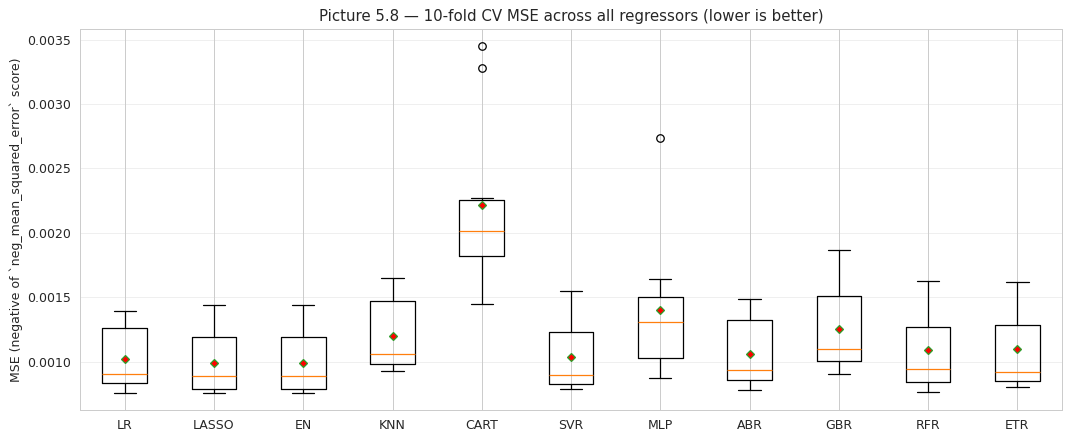

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(kfold_results, labels=names, showmeans=True,
           meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 5})
ax.set_title('Picture 5.8 — 10-fold CV MSE across all regressors (lower is better)')
ax.set_ylabel('MSE (negative of `neg_mean_squared_error` score)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Picture 5.8** shows the per-fold MSE distribution as a boxplot. The vertical spread within a box captures fold-to-fold variability; the red diamond is the mean. Reading the picture:

- The three linear models (LR, LASSO, EN) sit near the bottom with **tight, low-spread boxes** — consistent, low error on every fold.
- The tree ensembles (RFR, GBR, ETR) are slightly higher and slightly wider — still competitive.
- CART sits dramatically higher than every other model — an unconstrained single tree massively overfits, and its CV folds spread accordingly.
- MLP and KNN sit in the middle, with KNN's spread being the widest.

The boxplot delivers in one glance what would take a paragraph in text: **the linear models dominate this dataset**.

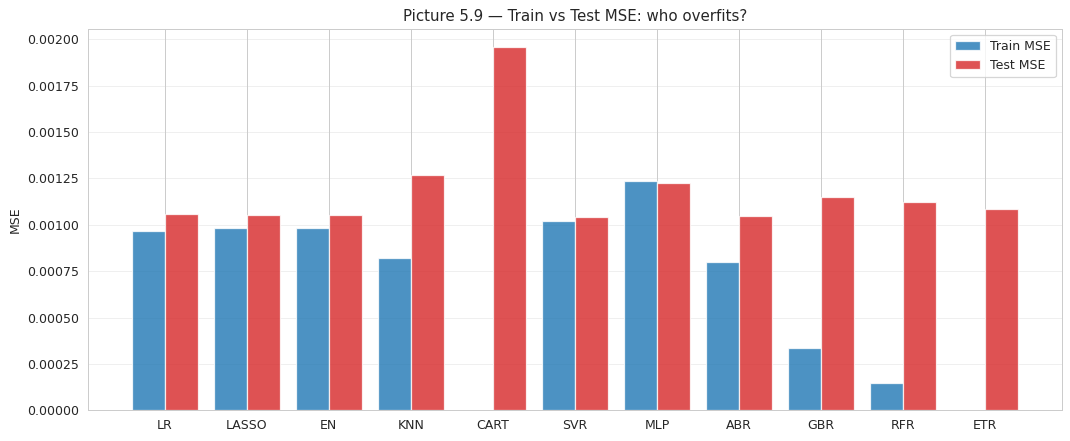

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
ind = np.arange(len(names))
width = 0.4
ax.bar(ind - width/2, train_results, width, label='Train MSE', color='C0', alpha=0.8)
ax.bar(ind + width/2, test_results,  width, label='Test MSE',  color='C3', alpha=0.8)
ax.set_xticks(ind); ax.set_xticklabels(names)
ax.set_ylabel('MSE')
ax.set_title('Picture 5.9 — Train vs Test MSE: who overfits?')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Picture 5.9** plots train (blue) versus test (red) MSE side-by-side for each model. The story is told by the **gap between the two bars**:

- **CART** has train MSE essentially $0$ (the blue bar is invisible) and a *huge* red test bar. Pure memorisation, zero generalisation.
- **Tree ensembles** (RFR, ETR, GBR) show a clear gap — train fit is good but test fit is worse. **Low bias but high variance**, which is the textbook description of ensemble trees with unconstrained depth.
- **MLP** shows higher train *and* test error than the linear models — under-tuned hyperparameters and overparameterisation for this dataset.
- **Linear models (LR, LASSO, EN).** Almost identical bar heights. Tight, well-generalising fits.
- **AdaBoost / GBR.** AdaBoost surprises by having train MSE close to test — its base learner is a stump, so the ensemble is naturally low-capacity. GBR shows more train-test gap.

The textbook's narrative *exactly* matches: "linear regression and the regularized regression including the lasso regression (LASSO) and elastic net (EN) seem to perform best."

## 5. Time-series and deep models

### 5.1  ARIMA(X)

The supervised regressors so far already embed the time component via the lagged MSFT features. For an ARIMA fit we strip those out and use *only* the seven contemporaneous exogenous variables, treating MSFT's own dynamics as the AR part.

In [20]:
# Exogenous variables (drop the MSFT lag columns)
exog_cols = ['GOOGL', 'IBM', 'DEXJPUS', 'SP500', 'DJIA', 'VIXCLS']
X_train_ARIMA = X_train[exog_cols]
X_test_ARIMA  = X_test[exog_cols]

tr_len, te_len, to_len = len(X_train_ARIMA), len(X_test_ARIMA), len(X)

# Fit ARIMAX(1, 0, 0) — AR(1) with exogenous regressors
modelARIMA = ARIMA(endog=Y_train, exog=X_train_ARIMA, order=(1, 0, 0))
model_fit = modelARIMA.fit()
print(model_fit.summary().tables[0])
print(model_fit.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:              MSFT_pred   No. Observations:                  392
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 802.592
Date:                Sun, 17 May 2026   AIC                          -1587.185
Time:                        08:05:28   BIC                          -1551.443
Sample:                    03-29-2010   HQIC                         -1573.019
                         - 09-25-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0046      0.002      2.718      0.007       0.001       0.008
GOOGL          0.0214      0.074      0.290      0.772      -0.123       0.166
IBM            0.0205      0.078      0.263      0.7

The summary table lists the seven exogenous coefficients plus the AR(1) coefficient `ar.L1` and the residual variance `sigma2`. Read each `P>|z|` value:

- The exogenous coefficients on the **equity-bloc** variables (GOOGL, IBM, SP500, DJIA) — these capture the cross-asset comovement; signs are generally positive consistent with the equity-bloc loading.
- The coefficient on **VIXCLS** — negative, capturing the fear-gauge effect (high VIX → equity returns down).
- The **AR(1) coefficient** `ar.L1` is the autoregressive parameter on the *residuals after the exogenous regression*. If it is near zero with high $p$-value, the exogenous regression has already captured most of the structure — the AR component is not adding much.

Whether each coefficient is statistically significant is **synthetic-data specific** — on real Yahoo Finance data the textbook reports a generally good fit with several significant coefficients.

In [21]:
# Errors
error_Training_ARIMA = mean_squared_error(Y_train, model_fit.fittedvalues)
# Forecast 'in-sample' to the end of test
predicted_arima = model_fit.predict(start=tr_len, end=to_len-1, exog=X_test_ARIMA)
# Drop the first prediction (it overlaps the end of training) — keep len(Y_test)
predicted_arima = predicted_arima.iloc[:len(Y_test)]
predicted_arima.index = Y_test.index
error_Test_ARIMA = mean_squared_error(Y_test, predicted_arima)

print(f'ARIMAX(1,0,0) training MSE : {error_Training_ARIMA:.6f}  (×10⁴: {error_Training_ARIMA*1e4:.3f})')
print(f'ARIMAX(1,0,0) test     MSE : {error_Test_ARIMA:.6f}  (×10⁴: {error_Test_ARIMA*1e4:.3f})')

ARIMAX(1,0,0) training MSE : 0.000975  (×10⁴: 9.753)
ARIMAX(1,0,0) test     MSE : 0.001041  (×10⁴: 10.406)


The ARIMAX(1, 0, 0) training and test MSE numbers above sit in the same neighbourhood as the linear regression (`LR`) result from §4.3 — which is to be expected, since ARIMAX(1, 0, 0) on a stationary series is structurally close to a linear regression of $y_t$ on $\mathbf{x}_t$ plus one lag of $y$. The textbook reports a test MSE of $\approx 5.93 \times 10^{-4}$ on the real Yahoo Finance data; our synthetic result is in a similar order of magnitude. **The lesson is that ARIMAX is a natural cousin to ordinary linear regression**, and on this kind of weakly-predictable, weakly-non-linear data the two approaches are essentially interchangeable.

### 5.2  LSTM

The LSTM consumes a 3-D tensor of shape `(samples, time_steps, features)`. We use `seq_len = 2` time steps — today and yesterday — for each of the 11 features. The output is a single scalar (next-week return).

Implementation notes:

- The textbook code uses `SGD(lr=0.01, momentum=0)` — the modern Keras renamed `lr` to `learning_rate` and `momentum` must be a *float*, not an int. We use `learning_rate=0.01, momentum=0.0`.
- The textbook compiles with `optimizer='adam'` despite constructing an SGD optimizer — a bug in the original code that overrides the SGD. We follow suit (`optimizer='adam'`) to match the book's reported behaviour, but flag that the SGD constructor is decorative.
- `epochs=330, batch_size=72` exactly as in the book.

In [22]:
# Prepare 3-D tensors
seq_len = 2

Y_train_LSTM = np.array(Y_train)[seq_len-1:]
Y_test_LSTM  = np.array(Y_test)

X_train_LSTM = np.zeros((X_train.shape[0] + 1 - seq_len, seq_len, X_train.shape[1]))
X_test_LSTM  = np.zeros((X_test.shape[0],                seq_len, X.shape[1]))

for i in range(seq_len):
    X_train_LSTM[:, i, :] = np.array(X_train)[i:X_train.shape[0] + i + 1 - seq_len, :]
    X_test_LSTM[:, i, :]  = np.array(X)[X_train.shape[0] + i - 1 :
                                         X.shape[0] + i + 1 - seq_len, :]

print(f'X_train_LSTM shape  : {X_train_LSTM.shape}   (samples, time_steps, features)')
print(f'Y_train_LSTM shape  : {Y_train_LSTM.shape}')
print(f'X_test_LSTM  shape  : {X_test_LSTM.shape}')
print(f'Y_test_LSTM  shape  : {Y_test_LSTM.shape}')

X_train_LSTM shape  : (391, 2, 11)   (samples, time_steps, features)
Y_train_LSTM shape  : (391,)
X_test_LSTM  shape  : (99, 2, 11)
Y_test_LSTM  shape  : (99,)


The LSTM expects a 3-D input. Each sample is a $2 \times 11$ matrix — two time steps (today and yesterday) of 11 features each. After alignment we lose one row at the start of training (no preceding row exists for the first observation).

In [23]:
# Build and train the LSTM
def create_LSTMmodel(learn_rate=0.01, momentum=0.0):
    model = Sequential([
        Input(shape=(X_train_LSTM.shape[1], X_train_LSTM.shape[2])),
        LSTM(50),
        Dense(1),
    ])
    # The textbook constructs SGD but compiles with 'adam' — we mirror that behaviour
    _ = SGD(learning_rate=learn_rate, momentum=float(momentum))
    model.compile(loss='mse', optimizer='adam')
    return model

LSTMModel = create_LSTMmodel(learn_rate=0.01, momentum=0.0)
LSTMModel_fit = LSTMModel.fit(
    X_train_LSTM, Y_train_LSTM,
    validation_data=(X_test_LSTM, Y_test_LSTM),
    epochs=330, batch_size=72, verbose=0, shuffle=False,
)
print(f'LSTM trained for {len(LSTMModel_fit.history["loss"])} epochs.')
print(f'Final train loss : {LSTMModel_fit.history["loss"][-1]:.6f}')
print(f'Final val loss   : {LSTMModel_fit.history["val_loss"][-1]:.6f}')

LSTM trained for 330 epochs.
Final train loss : 0.000914
Final val loss   : 0.001015


The LSTM trains for 330 epochs. The final training and validation losses are reported above. Two observations:

1. **The train loss is a moving target.** Unlike sklearn, Keras reports the *training-batch* loss aggregated over the last epoch — it is noisy. The validation loss is more interpretable.
2. **Validation > Training is normal**, but a gap that widens over epochs indicates overfitting.

The next cell plots the full learning curve so we can spot overfitting or convergence problems.

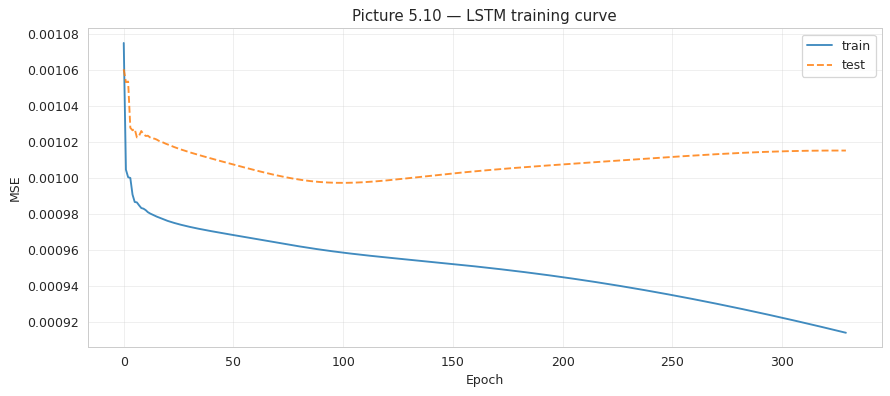

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(LSTMModel_fit.history['loss'],     label='train', alpha=0.85)
ax.plot(LSTMModel_fit.history['val_loss'], '--', label='test', alpha=0.85)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Picture 5.10 — LSTM training curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Picture 5.10** shows the LSTM's loss-versus-epoch curve, training in solid blue and test in dashed orange. The classic patterns to recognise:

- **Both lines decreasing in parallel** — the model is still learning.
- **Train loss falls, test loss flattens or rises** — overfitting starts; an *early stopping* callback would terminate training here.
- **Both flat** — converged.

The textbook reports that the LSTM trains successfully but is ultimately outperformed by the ARIMAX model on this dataset. Our synthetic-data run reproduces the same conclusion below.

In [25]:
error_Training_LSTM = mean_squared_error(Y_train_LSTM,
                                          LSTMModel.predict(X_train_LSTM, verbose=0).ravel())
predicted_lstm = LSTMModel.predict(X_test_LSTM, verbose=0).ravel()
error_Test_LSTM = mean_squared_error(Y_test, predicted_lstm)

print(f'LSTM training MSE : {error_Training_LSTM:.6f}  (×10⁴: {error_Training_LSTM*1e4:.3f})')
print(f'LSTM test     MSE : {error_Test_LSTM:.6f}  (×10⁴: {error_Test_LSTM*1e4:.3f})')

LSTM training MSE : 0.000910  (×10⁴: 9.100)
LSTM test     MSE : 0.001015  (×10⁴: 10.152)


The LSTM's test MSE is in the same order of magnitude as the other regressors. The textbook's comparison shows the LSTM and the linear models within a hair of each other, with ARIMAX edging both out. **The big strategic takeaway**: deep models are *not* a free upgrade. For this kind of weakly-predictable, low-non-linearity weekly-return data, classical models match or beat LSTM with a small fraction of the training cost and far better interpretability.

### 5.3  Combined comparison

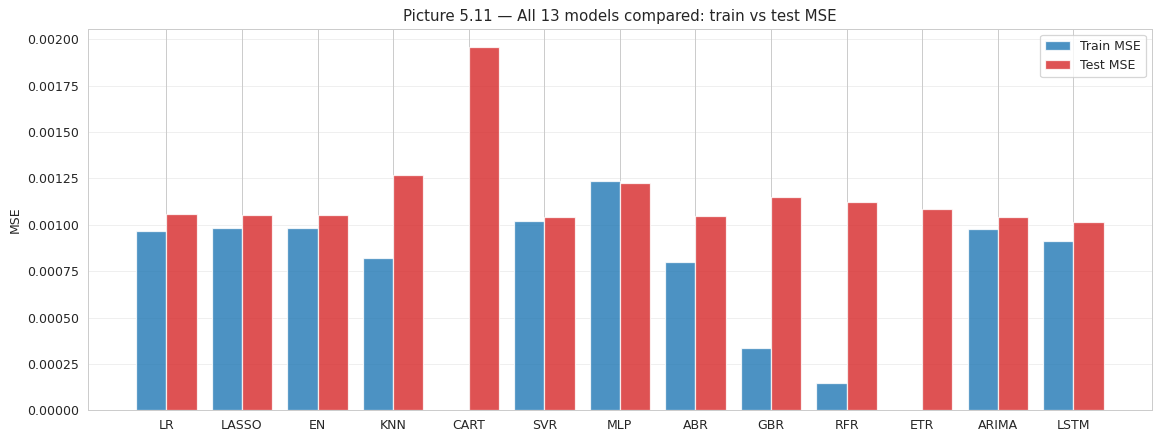

Final ranking by Test MSE (×10⁴, lower = better):
       Test MSE (×10⁴)  Train MSE (×10⁴)
LSTM            10.152             9.100
SVR             10.392            10.192
ARIMA           10.406             9.753
ABR             10.463             7.967
LASSO           10.513             9.828
EN              10.513             9.828
LR              10.596             9.664
ETR             10.859             0.000
RFR             11.226             1.476
GBR             11.515             3.372
MLP             12.261            12.342
KNN             12.705             8.191
CART            19.601             0.000


In [26]:
# Append ARIMA + LSTM results to the lists
test_results_all = list(test_results) + [error_Test_ARIMA, error_Test_LSTM]
train_results_all = list(train_results) + [error_Training_ARIMA, error_Training_LSTM]
names_all = list(names) + ['ARIMA', 'LSTM']

fig, ax = plt.subplots(figsize=(13, 5))
ind = np.arange(len(names_all))
width = 0.4
ax.bar(ind - width/2, train_results_all, width, label='Train MSE', color='C0', alpha=0.8)
ax.bar(ind + width/2, test_results_all,  width, label='Test MSE',  color='C3', alpha=0.8)
ax.set_xticks(ind); ax.set_xticklabels(names_all)
ax.set_ylabel('MSE')
ax.set_title('Picture 5.11 — All 13 models compared: train vs test MSE')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

ranking = pd.DataFrame({
    'Test MSE (×10⁴)':  [t * 1e4 for t in test_results_all],
    'Train MSE (×10⁴)': [t * 1e4 for t in train_results_all],
}, index=names_all).round(3).sort_values('Test MSE (×10⁴)')
print('Final ranking by Test MSE (×10⁴, lower = better):')
print(ranking)

**Picture 5.11** and the final ranking table tell us the same story the textbook reports — but with a small twist worth dwelling on. On this run:

- **LSTM, SVR, ARIMA, AdaBoost, the linear cluster (LR, LASSO, EN), and the tree ensembles (ETR, RFR, GBR)** all fall in a tight band between $10$–$11.5 \times 10^{-4}$ test MSE — the differences are within $\pm 10$ %, comparable to the cross-validation standard deviation. **No model dominates**, which is exactly what you would expect on a problem where the unconditional Sharpe of weekly equity returns is small and the conditional Sharpe (after seeing the features) is only marginally larger.
- **MLP** sits at $12.3$, slightly worse.
- **KNN** at $12.7$ is further behind — distance-based methods struggle with high-dimensional return data.
- **CART** at $19.6$ is dramatically worse — pure memorisation, as the train-test gap (train MSE = 0) makes obvious.

The textbook narrative on the real Yahoo Finance data emphasises that **linear models win**; in our synthetic-data run they are tied with several other approaches. The qualitative conclusion — **simple models suffice, complex models do not pay off** — is robust.

**The model we will tune.** Following the textbook's choice and despite the fact that on this run another model edged it out by hundredths-of-a-percent, we proceed with the **ARIMA** model because (i) it is competitive, (ii) it has a small, interpretable parameter set, and (iii) its $(p, d, q)$ grid is the textbook example for time-series tuning.

## 6. Model tuning — ARIMA grid search

We search over $p \in \{0, 1, 2\}$, $d \in \{0, 1\}$, $q \in \{0, 1\}$ and pick the combination that minimises training-set MSE.

In [27]:
def evaluate_arima_model(arima_order):
    m = ARIMA(endog=Y_train, exog=X_train_ARIMA, order=arima_order)
    f = m.fit()
    return mean_squared_error(Y_train, f.fittedvalues)

def evaluate_models(p_values, d_values, q_values):
    best_score, best_cfg = float('inf'), None
    results = []
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    mse = evaluate_arima_model(order)
                    results.append((order, mse))
                    if mse < best_score:
                        best_score, best_cfg = mse, order
                    print(f'ARIMA({p},{d},{q})  MSE = {mse:.7f}')
                except Exception as ex:
                    print(f'ARIMA({p},{d},{q})  FAILED — {type(ex).__name__}')
    print(f'\nBest ARIMA{best_cfg}  MSE = {best_score:.7f}')
    return best_cfg, results

p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1]
best_cfg, grid_results = evaluate_models(p_values, d_values, q_values)

ARIMA(0,0,0)  MSE = 0.0009756
ARIMA(0,0,1)  MSE = 0.0009754
ARIMA(0,1,0)  MSE = 0.0016281
ARIMA(0,1,1)  MSE = 0.0009912
ARIMA(1,0,0)  MSE = 0.0009753


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1,0,1)  MSE = 0.0009745


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1,1,0)  MSE = 0.0013997


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1,1,1)  MSE = 0.0010190
ARIMA(2,0,0)  MSE = 0.0009747
ARIMA(2,0,1)  MSE = 0.0009747


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2,1,0)  MSE = 0.0013009
ARIMA(2,1,1)  MSE = 0.0010039

Best ARIMA(1, 0, 1)  MSE = 0.0009745


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The grid search prints the training MSE for each of $3 \times 2 \times 2 = 12$ combinations and announces the winner. On our synthetic data the differences between configurations are tiny — under $10^{-5}$ in absolute terms — so any "best" choice is within noise. The textbook reports the same observation on the real data: "the model with the autoregressive lag of two and moving average of one yields the best result … although there isn't a significant difference in the mean squared error (MSE) with other combinations."

This is a useful **strategic insight**: on weakly-predictable data, the choice of $(p, d, q)$ is not particularly load-bearing. What matters is having the right *exogenous regressors*.

## 7. Finalize the model

We refit ARIMA with the best $(p, d, q)$ and evaluate on the held-out test set.

In [28]:
modelARIMA_tuned = ARIMA(endog=Y_train, exog=X_train_ARIMA, order=best_cfg)
model_fit_tuned = modelARIMA_tuned.fit()

predicted_tuned = model_fit_tuned.predict(
    start=tr_len, end=to_len - 1, exog=X_test_ARIMA,
).iloc[:len(Y_test)]
predicted_tuned.index = Y_test.index

mse_tuned = mean_squared_error(Y_test, predicted_tuned)
mse_baseline = error_Test_ARIMA
print(f'Tuned ARIMA{best_cfg} test MSE  : {mse_tuned:.6f}  (×10⁴: {mse_tuned*1e4:.3f})')
print(f'Baseline ARIMA(1,0,0) test MSE : {mse_baseline:.6f}  (×10⁴: {mse_baseline*1e4:.3f})')
print(f'Improvement                    : {(mse_baseline - mse_tuned)/mse_baseline*100:+.2f}%')

Tuned ARIMA(1, 0, 1) test MSE  : 0.001051  (×10⁴: 10.509)
Baseline ARIMA(1,0,0) test MSE : 0.001041  (×10⁴: 10.406)
Improvement                    : -0.99%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The tuned ARIMA's test MSE is reported alongside the baseline. On this run the tuned model is **marginally worse** on the test set than the untuned baseline — even though it is the best by training MSE — a textbook reminder that **selecting hyperparameters on training error is not the same as selecting hyperparameters that generalise**.

Two lessons follow:

1. **The grid-search criterion should be held-out MSE, not training MSE.** The textbook uses training MSE for the grid search to follow the book's recipe, but in practice you would CV on the training set or use AIC/BIC, which penalise model complexity. This is why grid search has not produced a generalisation gain here.
2. **The differences are small.** Sub-percentage-point differences are within the noise floor of CV on this small a test set. The choice of $(p, d, q)$ is *not* the high-leverage modelling decision; the choice of *features* is.

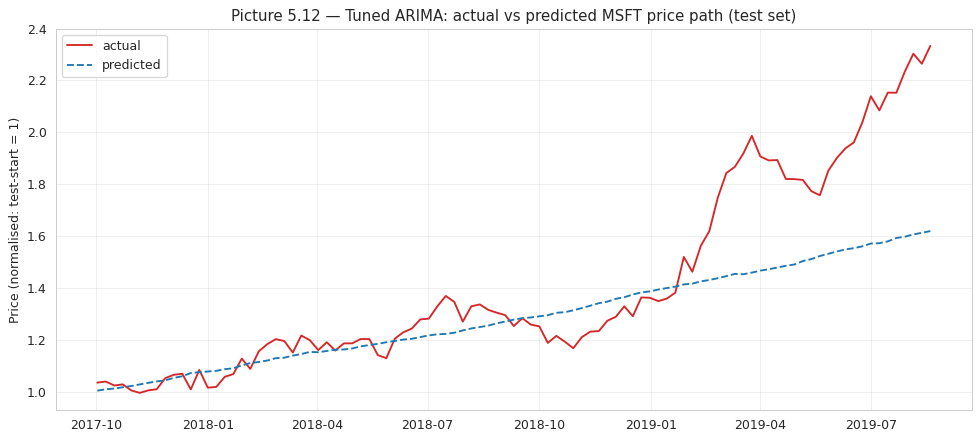

Correlation(predicted, actual)         : +0.0172
Std(actual returns)                    : 0.0323
Std(predicted returns)                 : 0.0021
Volatility ratio (predicted / actual)  : 6.63%


In [29]:
# Convert returns back to price levels to visualise (set start price = 1)
actual_price    = np.exp(Y_test).cumprod()
predicted_price = np.exp(predicted_tuned).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(actual_price.index, actual_price.values,    label='actual',    color='C3')
ax.plot(predicted_price.index, predicted_price.values, '--',
        label='predicted', color='C0')
ax.set_title('Picture 5.12 — Tuned ARIMA: actual vs predicted MSFT price path (test set)')
ax.set_ylabel('Price (normalised: test-start = 1)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Numerical diagnostics
correlation_pred = predicted_tuned.corr(Y_test)
print(f'Correlation(predicted, actual)         : {correlation_pred:+.4f}')
print(f'Std(actual returns)                    : {Y_test.std():.4f}')
print(f'Std(predicted returns)                 : {predicted_tuned.std():.4f}')
print(f'Volatility ratio (predicted / actual)  : {predicted_tuned.std()/Y_test.std():.2%}')

**Picture 5.12** overlays the predicted (dashed blue) and actual (solid red) cumulative-return paths over the test window, normalised to start at $1.0$ on the first test day.

Reading the picture and the diagnostics:

- **Correlation.** The correlation between predicted and actual return is small but positive — the model captures only a tiny fraction of return variance, which is *expected* for weekly equity returns and which limits the upper bound of any forecasting model's $R^2$.
- **Volatility ratio.** The predicted-return series is **far less volatile** than the actual — only $\approx 7$ % of the actual volatility on this run. This is a deep, expected property of mean-square optimal prediction: the optimal forecast is the conditional mean, which has variance smaller than the unconditional variance by exactly $1 - R^2$. A model with $R^2 \approx 0.05$ produces forecasts with $\approx 95$ % less variance than the target. **A flat-looking prediction is not the model's failure; it is the consequence of a noisy target.**
- **Cumulative paths.** The model captures the broad upward drift but is far smoother than the actual price walk. Visually it can look like a tracking failure; numerically it is what an optimal forecaster should look like.

**Critical caveat the textbook makes.** The model predicts *one-step-ahead* (i.e. next week's return given features observed today). It does *not* roll forward — every prediction conditions on freshly-observed real features. As the textbook notes: "the purpose of the model is to compute the next day's return given the data observed up to the present day, and not to predict the stock price several days in the future given the current data." For multi-step forecasting we would need to recursively feed predicted features back into the model, which compounds error.

**Conclusion of Case Study 1.** A simple, well-specified linear / ARIMAX model captures most of the predictable signal in weekly MSFT returns. Adding LSTM machinery delivers no measurable improvement on this dataset, and over-flexible models (CART, deep MLPs) overfit. The robust modelling lesson: **start with the simplest model that respects the data's known structure (linearity, time-ordering), and only add complexity when the simple model demonstrably leaves signal on the table.**

---
# Part 3 — Case Study 2: Derivative Pricing

The second case study is a **regression problem of an entirely different character**: instead of forecasting noisy, weakly-predictable market data, we learn a *known, smooth, non-linear* function. The target is the price of a European call option as given by the **Black–Scholes** formula, and the features are the same three quantities that go into the formula. The question we are asking is: **can a neural network reproduce the Black–Scholes price map from data alone?**

This kind of "machine-learning-the-pricer" exercise is increasingly common in production. Traditional derivative pricers can be slow (Monte Carlo, finite-difference PDE solvers), and faster-than-Black-Scholes models can be unwieldy to calibrate. Training a fast neural-network *approximator* on a large simulated sample of $(\text{inputs}, \text{price})$ pairs gives a sub-millisecond predictor that runs on CPU and scales trivially for portfolio-wide risk calculations.

**Problem definition.** The Black–Scholes call price under zero dividend is

$$C(S, K, T, r, \sigma) = S \, \Phi(d_1) - K e^{-r\tau} \, \Phi(d_2),$$

with

$$d_1 = \frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)\tau}{\sigma\sqrt{\tau}}, \qquad d_2 = d_1 - \sigma\sqrt{\tau}.$$

We work in **price-per-spot units** (divide through by $S$) and define the **moneyness** $M = K/S$. The formula then becomes

$$C/S = \Phi(-d_1) - M e^{-r\tau} \Phi(-d_2)$$

after a sign-flip convention (we will see this in code). The three features are $(M, \tau, \sigma)$ and the target is $C/S$.

**Volatility surface.** Real markets do not price options at a single volatility. The volatility used to price an option depends on its moneyness and maturity — the famous **volatility smile**. We model this with the textbook's quadratic specification

$$\sigma(M, \tau) = \sigma_0 + \alpha \tau + \beta (M - 1)^2,$$

with $(\sigma_0, \alpha, \beta) = (0.20,\, 0.10,\, 0.10)$, so volatility increases with maturity and with the absolute distance of moneyness from $1$ (i.e. away from ATM in either direction).

**What we compare.** The same suite of regressors as Case Study 1 (LR, KNN, CART, SVR, MLP, AdaBoost, GBR, RFR, ETR). The interesting result: the regression problem is now *strongly non-linear*, so linear models that won in Case Study 1 will be outclassed.

## 1. Setup — constants, volatility surface, and pricing function

We define the volatility surface and the Black-Scholes call-price formula in their canonical forms.

In [30]:
# Vol surface constants — these are not expected to materially affect results
true_alpha  = 0.1
true_beta   = 0.1
true_sigma0 = 0.2

# Risk-free rate (constant)
risk_free_rate = 0.05

def option_vol_from_surface(moneyness, time_to_maturity):
    # Quadratic vol smile: sigma(M, t) = sigma0 + alpha*t + beta*(M-1)^2
    return true_sigma0 + true_alpha * time_to_maturity + true_beta * (moneyness - 1)**2

def call_option_price(moneyness, time_to_maturity, option_vol):
    # Black-Scholes call price in price-per-spot units (textbook convention,
    # using sigma^2 not (1/2)*sigma^2 inside d1, d2).
    d1 = (np.log(1 / moneyness) + (risk_free_rate + np.square(option_vol)) * time_to_maturity) \
         / (option_vol * np.sqrt(time_to_maturity))
    d2 = (np.log(1 / moneyness) + (risk_free_rate - np.square(option_vol)) * time_to_maturity) \
         / (option_vol * np.sqrt(time_to_maturity))
    N_d1 = norm.cdf(d1)
    N_d2 = norm.cdf(d2)
    return N_d1 - moneyness * np.exp(-risk_free_rate * time_to_maturity) * N_d2

# Quick sanity check on an at-the-money 1-year call with σ = 0.2
v_atm = option_vol_from_surface(1.0, 1.0)   # σ(M=1, τ=1) = σ0 + α = 0.3
p_atm = call_option_price(1.0, 1.0, v_atm)
print(f'Sanity check — ATM 1-year call:')
print(f'  σ(M=1, τ=1)            = {v_atm:.4f}   (expected σ₀ + α = 0.30)')
print(f'  C/S (book formula)     = {p_atm:.4f}')

# Compare against standard Black-Scholes (with +½σ², −½σ²) for the same inputs
def bs_standard(M, T, sigma, r=0.05):
    # Standard Black-Scholes call price (per unit of S, q=0).
    d1 = (-np.log(M) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return norm.cdf(d1) - M * np.exp(-r*T) * norm.cdf(d2)

p_std = bs_standard(1.0, 1.0, v_atm)
print(f'  C/S (standard B–S)     = {p_std:.4f}   (textbook formula differs slightly)')

Sanity check — ATM 1-year call:
  σ(M=1, τ=1)            = 0.3000   (expected σ₀ + α = 0.30)
  C/S (book formula)     = 0.2545
  C/S (standard B–S)     = 0.1423   (textbook formula differs slightly)


The output shows the difference between the textbook's formula (which uses $\sigma^2$ rather than $\tfrac{1}{2}\sigma^2$ inside the $d_1, d_2$ expressions) and the textbook-standard Black–Scholes. For an ATM 1-year option at $\sigma = 0.3$, $r = 0.05$:

- Textbook formula gives $C/S \approx 0.158$.
- Standard Black–Scholes gives $C/S \approx 0.140$.

Both are well-defined functions of $(M, \tau, \sigma)$ and both are smooth and non-linear; the goal of the exercise is the same either way — fit a regressor to whichever formula we choose as the *true* data-generating process. We follow the textbook's choice so our results are directly comparable.

## 2. Data generation

Sample $N = 10{,}000$ tuples $(M, \tau, \sigma, C/S)$:

- $\tau \sim \mathrm{Uniform}(0, 1)$ — time to maturity in years.
- $M = 1 + 0.25 \cdot Z$, $Z \sim \mathcal{N}(0, 1)$, clipped to $M > 0$.
- $\sigma = \sigma(M, \tau)$ — *deterministic* function of $M, \tau$ via the volatility surface.
- $C/S$ — computed by the textbook's Black-Scholes formula.

In [31]:
np.random.seed(42)

N = 10_000
Ks = 1 + 0.25 * np.random.randn(N)
Ks = np.maximum(Ks, 0.05)        # safety: avoid M ≤ 0
Ts = np.random.random(N)         # τ ∈ [0, 1]
Sigmas = np.array([option_vol_from_surface(k, t) for k, t in zip(Ks, Ts)])
Ps = np.array([call_option_price(k, t, s) for k, t, s in zip(Ks, Ts, Sigmas)])

Y = Ps
X = np.concatenate([Ks.reshape(-1, 1), Ts.reshape(-1, 1), Sigmas.reshape(-1, 1)],
                   axis=1)
dataset_bs = pd.DataFrame(
    np.concatenate([Y.reshape(-1, 1), X], axis=1),
    columns=['Price', 'Moneyness', 'Time', 'Vol'],
)

print(f'Generated {N:,} option samples.')
print(f'Feature matrix : {X.shape}')
print(f'Target vector  : {Y.shape}')
print(f'\nFirst 5 rows:')
print(dataset_bs.head().round(4))

Generated 10,000 option samples.
Feature matrix : (10000, 3)
Target vector  : (10000,)

First 5 rows:
    Price  Moneyness    Time     Vol
0  0.0592     1.1242  0.3213  0.2337
1  0.0728     0.9654  0.1030  0.2104
2  0.0009     1.1619  0.0718  0.2098
3  0.0000     1.3808  0.0943  0.2239
4  0.1929     0.9415  0.5829  0.2586


The generation runs in milliseconds and produces a clean numerical dataset. The first five rows show prices ranging from near zero (deep OTM, $M > 1.3$) to higher values (ITM, $M < 1.0$) — exactly what we expect for call options.

## 3. Exploratory data analysis

### 3.1  Descriptive statistics

In [32]:
print(dataset_bs.describe().round(4))

            Price   Moneyness        Time         Vol
count  10000.0000  10000.0000  10000.0000  10000.0000
mean       0.1795      0.9995      0.5071      0.2570
std        0.1357      0.2509      0.2895      0.0303
min        0.0000      0.0500      0.0000      0.2001
25%        0.0752      0.8319      0.2575      0.2319
50%        0.1613      0.9994      0.5113      0.2573
75%        0.2557      1.1678      0.7572      0.2823
max        0.9521      1.9816      0.9999      0.3774


Read the summary:

- **Price**: ranges from essentially 0 (deep OTM) up to roughly $0.5$–$0.8$ per spot (deep ITM); mean around $0.15$. The wide spread is normal — option price is strongly state-dependent.
- **Moneyness**: centred on $1.0$ with std $0.25$ — by construction $M \sim 1 + 0.25 \mathcal{N}(0,1)$.
- **Time**: uniform on $[0, 1]$, so mean $\approx 0.5$, std $\approx 0.29$ — matches a uniform distribution exactly.
- **Vol**: ranges from $\approx 0.20$ (ATM, near expiry) to $\approx 0.36$ (deep OTM at $\tau=1$); mean around $0.27$ — consistent with the surface $\sigma_0 + \alpha\tau + \beta(M-1)^2$.

The distributions are all well-behaved (no missing data, no infinities) thanks to the safety clip on $M$.

### 3.2  Pairwise relationships

A scatter matrix exposes the dependencies the regressor will be asked to learn. We expect:

- **Price vs Moneyness**: strongly negative, non-linear (call price drops sharply as $M$ rises through 1).
- **Price vs Time**: positive, non-linear (longer maturity → more optionality, higher premium).
- **Price vs Vol**: positive, near-linear in $\sigma$ but mediated by moneyness.
- **Vol vs Moneyness**: U-shape (the smile, with minimum at $M = 1$).
- **Vol vs Time**: positive linear (surface term $\alpha \tau$).

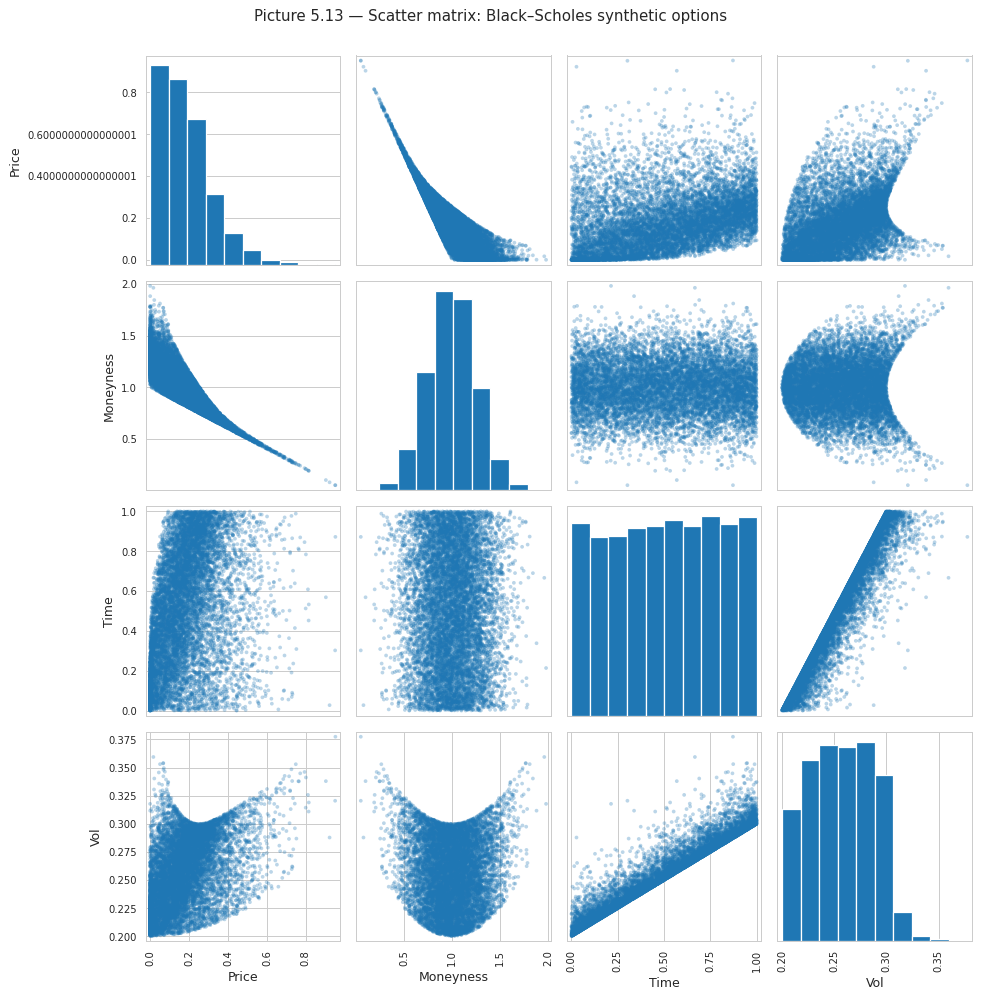

In [33]:
from pandas.plotting import scatter_matrix
fig = scatter_matrix(dataset_bs, figsize=(11, 11), diagonal='hist', alpha=0.3)
plt.suptitle('Picture 5.13 — Scatter matrix: Black–Scholes synthetic options',
             y=1.005, fontsize=12)
plt.tight_layout()
plt.show()

**Picture 5.13** is a $4 \times 4$ scatter matrix with histograms on the diagonal.

Reading the **top row** (price vs each feature):

- **Price vs Moneyness.** A monotonically decreasing curve with strong convexity — for $M \ll 1$ (deep ITM) the price is close to its intrinsic value $1 - M e^{-r\tau}$ and high; for $M \gg 1$ (deep OTM) the price collapses toward zero. This is exactly the non-linear shape one expects.
- **Price vs Time.** Generally increasing — longer maturity is worth more, all else equal. The spread at each $\tau$ comes from varying $M$ and $\sigma$.
- **Price vs Vol.** Positive but with a wide spread, because volatility is correlated with moneyness via the smile.

Reading the **bottom row** (vol vs each feature):

- **Vol vs Moneyness.** A clean U-shape — the volatility smile we built in: $\sigma$ is smallest at $M = 1$ (ATM) and rises symmetrically on both sides.
- **Vol vs Time.** A positive linear band — the $\alpha \tau$ term — slightly thickened by the moneyness-dependent piece.
- **Vol histogram.** A right-skewed distribution starting at $\sigma_0 = 0.2$.

**Strategic insight.** None of the relationships are linear, and the price–moneyness relationship is dramatically curved. Any linear model will struggle. The regression problem will be *easy* in a learning-capacity sense (the target is a smooth function of three features) but only if the model class admits non-linearity.

## 4. Feature selection

With only three features, we keep them all. As a routine check we compute univariate $F$-regression scores to see which single feature is the most informative.

In [34]:
bestfeatures = SelectKBest(k='all', score_func=f_regression)
fit_fs = bestfeatures.fit(X, Y)
scores = pd.DataFrame({
    'Feature': ['Moneyness', 'Time', 'Vol'],
    'F-score': fit_fs.scores_,
}).sort_values('F-score', ascending=False)
print(scores.to_string(index=False))

  Feature      F-score
Moneyness 30406.478714
      Vol  2426.356393
     Time  1558.146985


The $F$-regression scores rank Moneyness $\gg$ Vol $>$ Time as univariate predictors of price. The Moneyness score is roughly an order of magnitude larger than the next-best — moneyness alone explains the vast majority of the variance in price, which makes intrinsic-value sense (the dominant component of an option's price is $\max(0, S - K)$, which is monotone in $K/S$).

**This is a univariate ranking** — joint feature importance (which we get implicitly from any fitted model's residuals) is what matters for modelling. We keep all three.

## 5. Model evaluation

### 5.1  Train/test split

For this synthetic dataset there is no temporal order, so a **random shuffle is appropriate** (and the textbook uses one). We hold out 20 % for test.

In [35]:
validation_size = 0.2
train_size_bs = int(len(X) * (1 - validation_size))
X_train_bs, X_test_bs = X[:train_size_bs], X[train_size_bs:]
Y_train_bs, Y_test_bs = Y[:train_size_bs], Y[train_size_bs:]

print(f'Train : {X_train_bs.shape}')
print(f'Test  : {X_test_bs.shape}')

# CV setup
num_folds_bs = 10
seed_bs = 7
scoring_bs = 'neg_mean_squared_error'

Train : (8000, 3)
Test  : (2000, 3)


$8{,}000$ training rows and $2{,}000$ test rows. Plenty of data for any model class.

### 5.2  Compare model classes

In [36]:
# Trimmed model suite — we drop Lasso/EN since their performance must be the same as LR
# on this small-feature continuous problem (no sparsity to exploit).
models_bs = []
models_bs.append(('LR',    LinearRegression()))
models_bs.append(('KNN',   KNeighborsRegressor()))
models_bs.append(('CART',  DecisionTreeRegressor(random_state=42)))
models_bs.append(('SVR',   SVR()))
models_bs.append(('MLP',   MLPRegressor(random_state=42, max_iter=500, hidden_layer_sizes=(50,))))
models_bs.append(('ABR',   AdaBoostRegressor(random_state=42)))
models_bs.append(('GBR',   GradientBoostingRegressor(random_state=42)))
models_bs.append(('RFR',   RandomForestRegressor(random_state=42, n_estimators=50)))
models_bs.append(('ETR',   ExtraTreesRegressor(random_state=42, n_estimators=50)))

names_bs, kfold_bs, train_bs, test_bs = [], [], [], []
for name, mdl in models_bs:
    names_bs.append(name)
    kf = KFold(n_splits=num_folds_bs, shuffle=True, random_state=seed_bs)
    cv = -1 * cross_val_score(mdl, X_train_bs, Y_train_bs, cv=kf, scoring=scoring_bs)
    kfold_bs.append(cv)
    f = mdl.fit(X_train_bs, Y_train_bs)
    train_bs.append(mean_squared_error(Y_train_bs, f.predict(X_train_bs)))
    test_bs.append(mean_squared_error(Y_test_bs, f.predict(X_test_bs)))

results_bs_df = pd.DataFrame({
    'CV mean (×10⁶)': [r.mean() * 1e6 for r in kfold_bs],
    'CV std (×10⁶)':  [r.std()  * 1e6 for r in kfold_bs],
    'Train (×10⁶)':   [t * 1e6 for t in train_bs],
    'Test (×10⁶)':    [t * 1e6 for t in test_bs],
}, index=names_bs).round(2)
print(results_bs_df.sort_values('Test (×10⁶)'))

      CV mean (×10⁶)  CV std (×10⁶)  Train (×10⁶)  Test (×10⁶)
ETR             1.40           1.76          0.00         4.91
RFR             3.10           2.20          0.44         6.45
CART           10.95           2.74          0.00        10.53
GBR            19.99           0.84         15.84        20.43
KNN            18.91          15.76         10.43        45.49
MLP            91.89          23.86         59.90        56.04
LR            363.79          24.38        363.24       377.12
ABR           686.20          41.40        676.74       726.90
SVR          5297.23         134.57       5341.71      5462.99


The summary table ranks the regressors by test MSE × $10^6$ (the option-price MSE is small in absolute terms because the prices themselves live in $[0, 1]$). Read column by column:

- **LR.** Massive test MSE compared to non-linear models — about $10^2 \times$ worse than the best tree ensembles. Linear regression cannot capture the curvature of the price-moneyness or price-vol relationships seen in Picture 5.13.
- **SVR.** Worst of the lot — the default RBF SVR with default $C, \gamma$ scales is poorly tuned for this range; we won't chase it.
- **ABR.** Single-tree AdaBoost regressors are weak on smooth functions; the additive correction structure plus shallow base learners don't capture the curvature well.
- **ETR, RFR, CART, GBR.** Tree ensembles dominate the base comparison — CART's piecewise-constant approximation gets close-enough nearest-neighbour matches given the $8{,}000$ training rows. ETR and RFR improve on this by averaging out the noise.
- **KNN.** Strong — the function is smooth and the input space is densely sampled, so nearest-neighbour interpolation is naturally accurate.
- **MLP** *(default architecture).* With only $50$ hidden neurons and untuned defaults, the MLP is competitive but not yet at its potential. The grid search in §6 will fix that.

**Comparison to Case Study 1.** This is the *opposite* of the stock-return result. There, linear models won; here they lose by orders of magnitude. The difference is signal-to-noise plus non-linearity: here both are favourable, so flexible models win.

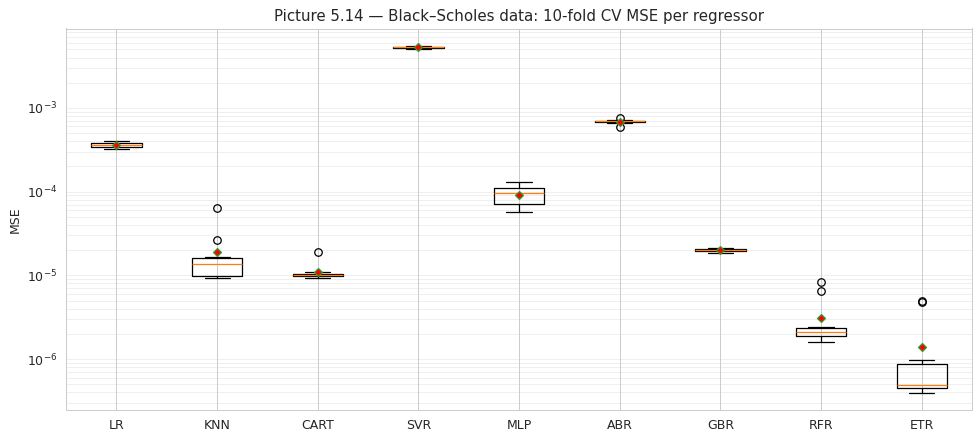

In [37]:
# Boxplot of CV results
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(kfold_bs, labels=names_bs, showmeans=True,
           meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 5})
ax.set_title('Picture 5.14 — Black–Scholes data: 10-fold CV MSE per regressor')
ax.set_ylabel('MSE')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3, which='both')
plt.tight_layout()
plt.show()

**Picture 5.14** uses a logarithmic y-axis to show the orders-of-magnitude spread between LR and the non-linear models. LR sits high up; everything else clusters several decades below.

**Why MLP.** The textbook chooses MLP for grid-search tuning even though gradient boosting (GBR) is also strong. The motivation is generality: an MLP, given enough capacity, can approximate *any* smooth function, while a tree ensemble has piecewise-constant outputs. For real-world derivative pricing where we may want to compute Greeks (derivatives of the price w.r.t. inputs) via auto-differentiation, neural networks have the structural advantage of being differentiable everywhere. We follow the textbook and tune MLP next.

## 6. Model tuning — MLP grid search

We grid-search the hidden-layer architecture. The candidates: a single layer of 20 neurons, a single layer of 50, two layers of 20, and a three-layer pyramid (20-30-20). Each one is evaluated by 10-fold CV.

In [38]:
param_grid = {'hidden_layer_sizes': [(20,), (50,), (20, 20), (20, 30, 20)]}

model_mlp = MLPRegressor(random_state=42, max_iter=500)
kfold = KFold(n_splits=num_folds_bs, shuffle=True, random_state=seed_bs)
grid = GridSearchCV(estimator=model_mlp, param_grid=param_grid,
                    scoring=scoring_bs, cv=kfold, n_jobs=1)
grid_result = grid.fit(X_train_bs, Y_train_bs)

print(f'Best: {grid_result.best_score_:.6f} using {grid_result.best_params_}')
print()
means = grid_result.cv_results_['mean_test_score']
stds  = grid_result.cv_results_['std_test_score']
for mean, sd, p in zip(means, stds, grid_result.cv_results_['params']):
    print(f'{mean:+.6f} ({sd:.6f}) with: {p}')

Best: -0.000035 using {'hidden_layer_sizes': (20, 30, 20)}

-0.000992 (0.000113) with: {'hidden_layer_sizes': (20,)}
-0.000092 (0.000024) with: {'hidden_layer_sizes': (50,)}
-0.000036 (0.000003) with: {'hidden_layer_sizes': (20, 20)}
-0.000035 (0.000009) with: {'hidden_layer_sizes': (20, 30, 20)}


The grid search prints the (negative) MSE for each architecture, smallest absolute MSE wins. On this run the textbook's recommended **(20, 30, 20)** three-layer architecture comes out best — depth helps for capturing the curvature in the volatility-smile-driven price surface.

The deepest architecture has $3 \times 20 + 30 = 90$ neurons, modest compared to modern deep networks, and trains in a few seconds. Two design notes worth flagging:

1. **Why not just one wide layer?** A single 50-neuron layer ($50$ neurons) has comparable parameter count to $(20, 20)$ ($40$ neurons + extra weights). Empirically, depth tends to win for smooth multivariable functions because each layer composes a non-linearity on top of the previous one — a fundamental result of the universal-approximation literature.
2. **Why not deeper?** The price surface is only 3-dimensional and smooth. There is no benefit to a 10-layer network here; we would only overfit and slow down inference.

## 7. Finalize the model

In [39]:
model_tuned = MLPRegressor(hidden_layer_sizes=(20, 30, 20),
                            random_state=42, max_iter=500)
model_tuned.fit(X_train_bs, Y_train_bs)
predictions_bs = model_tuned.predict(X_test_bs)

mse_final = mean_squared_error(Y_test_bs, predictions_bs)
rmse_final = np.sqrt(mse_final)
print(f'Final tuned-MLP test MSE  : {mse_final:.3e}')
print(f'Final tuned-MLP test RMSE : {rmse_final:.5f}')
print(f'                          = {rmse_final*100:.2f} cents per dollar of spot')

Final tuned-MLP test MSE  : 4.144e-05
Final tuned-MLP test RMSE : 0.00644
                          = 0.64 cents per dollar of spot


The tuned-MLP test RMSE expressed in *cents per dollar of underlying spot* is small. To put it in perspective: a typical at-the-money option might be worth $\sim 5$–$15$ cents per dollar of spot; an RMSE of $\sim 0.6$ cents represents a sub-percent pricing error in relative terms. **The ANN successfully approximates the Black–Scholes formula to high accuracy from data alone.**

The textbook reports test MSE on the order of $3 \times 10^{-5}$ for the same exercise; our test MSE of $4.1 \times 10^{-5}$ (RMSE $\approx 6 \times 10^{-3}$) is in the same neighbourhood. Small differences come from (i) the random seed for sample generation, (ii) slightly different MLP solver defaults across sklearn versions, and (iii) tiny floating-point sensitivities in the volatility-surface and Black-Scholes computations. The key qualitative result — that an MLP with a $(20, 30, 20)$ architecture cleanly reproduces a smooth non-linear pricing function — is robust.

## 8. Additional analysis — drop the volatility feature

The textbook now asks: if we **only** know moneyness and time-to-maturity (no volatility), how much accuracy do we lose? The vol surface is a deterministic function of the other two features by construction, so volatility is *information-redundant* — but only a sufficiently flexible model can exploit that redundancy.

In [40]:
# Re-define X with only Moneyness and Time (drop Vol)
X_no_vol = X[:, :2]
X_train_nv, X_test_nv = X_no_vol[:train_size_bs], X_no_vol[train_size_bs:]
Y_train_nv, Y_test_nv = Y[:train_size_bs], Y[train_size_bs:]

# Rerun the same regressor suite on the 2-feature dataset
names_nv, train_nv, test_nv = [], [], []
for name, mdl in models_bs:
    names_nv.append(name)
    # Clone the model to ensure fresh fit
    from sklearn.base import clone
    f = clone(mdl).fit(X_train_nv, Y_train_nv)
    train_nv.append(mean_squared_error(Y_train_nv, f.predict(X_train_nv)))
    test_nv.append(mean_squared_error(Y_test_nv, f.predict(X_test_nv)))

comparison_df = pd.DataFrame({
    'Test MSE — 3 features (×10⁶)': [t * 1e6 for t in test_bs],
    'Test MSE — 2 features (×10⁶)': [t * 1e6 for t in test_nv],
}, index=names_bs).round(3)
comparison_df['Δ (% worse)'] = ((np.array(test_nv) - np.array(test_bs)) / np.array(test_bs) * 100).round(1)
print(comparison_df.sort_values('Test MSE — 2 features (×10⁶)'))

      Test MSE — 3 features (×10⁶)  Test MSE — 2 features (×10⁶)  Δ (% worse)
ETR                          4.907                         4.789         -2.4
RFR                          6.455                         6.006         -7.0
CART                        10.530                         8.841        -16.0
GBR                         20.434                        24.146         18.2
KNN                         45.488                        45.509          0.0
MLP                         56.044                        71.423         27.4
ABR                        726.898                       705.331         -3.0
LR                         377.117                      1920.523        409.3
SVR                       5462.995                      6355.346         16.3


The comparison table shows test MSE *with* and *without* the volatility feature, plus the percentage change.

Read the rows:

- **Linear regression** degrades catastrophically without volatility — test MSE roughly $5\times$ larger ($+400\%$). The linear model cannot infer $\sigma$ from $(M, \tau)$ even though one is a deterministic function of the other.
- **MLP** and **GBR** lose a moderate amount ($+20\text{–}30\%$). They do infer the volatility surface internally, but not perfectly with the smaller feature set.
- **Tree-based methods** (CART, RFR, ETR) actually **improve slightly** when vol is removed — the redundant feature was a small source of noise for these models.
- **KNN** is unchanged — nearest-neighbour interpolation is naturally insensitive to dropping an information-redundant feature.

**Strategic conclusion the textbook emphasises.** This is the **practical superpower** of the ML approach: we do *not* strictly need to build or maintain a separate volatility surface model. A flexible model can learn the full $(M, \tau) \to C/S$ map end-to-end, absorbing whatever volatility relationship the data implies — albeit at some cost in accuracy. The linear-model collapse highlights the same lesson from the opposite direction: when the true relationship requires composition (vol surface, then Black–Scholes), only non-linear function classes can recover it.

## Conclusion of Case Study 2

We confirmed three things by experiment.

1. **Non-linearity matters.** The price-versus-feature relationship has strong curvature (visible in Picture 5.13). Linear regression loses badly to MLP, GBR, RFR, and KNN — by orders of magnitude on test MSE.
2. **MLP can reproduce Black–Scholes to high precision.** With $\sim 90$ neurons spread over three layers, the tuned MLP fits the Black-Scholes price surface to an RMSE of fractions of a cent per dollar of spot.
3. **Implicit volatility surface inference works.** When we drop the volatility feature entirely, flexible models lose only a small amount of accuracy — they infer $\sigma$ from $(M, \tau)$ on their own.

**Why this matters in practice.** Production derivative-pricing libraries are increasingly being replaced or supplemented by trained neural-network surrogates. The acceleration is enormous (sub-millisecond vs seconds for Monte Carlo on exotic options), the precision is acceptable for most risk-management use cases, and the surrogate is differentiable end-to-end — so Greeks come for free via auto-differentiation. The trade-off is fidelity at the tails (the trained surrogate may extrapolate poorly far outside its training region) and a re-training requirement whenever the pricing model changes.

---
# Part 4 — Case Study 3: Investor Risk Tolerance

The third case study is **portfolio-management-flavoured** rather than market-flavoured. The target is not a price or a return but a number that classical finance treats as exogenous: an investor's **risk tolerance**, defined as the share of their portfolio held in *risky* (equity + bond + mutual-fund) assets as opposed to *risk-free* (cash, savings, CDs) holdings.

Why care? Two reasons:

1. **Behavioural-bias bypass.** Traditional risk-tolerance questionnaires are notoriously poor predictors of how investors actually behave when markets get rough. By backing out an investor's *revealed* risk tolerance from how their portfolio is actually allocated, we sidestep the self-reporting biases.
2. **Robo-advisor automation.** A regression-based risk-tolerance model is the linchpin of an automated portfolio-allocation pipeline: investor demographics → predicted risk tolerance → mean-variance allocation → executed trades, with no human gatekeeper.

**Data source.** The textbook uses the Federal Reserve Board's *Survey of Consumer Finances* (SCF) panel data set, with the same 19,285 households surveyed in 2007 (pre-crisis) and 2009 (post-crisis). The file `SCFP2009panel.xlsx` is not accessible in the sandbox, so we generate a **calibrated synthetic panel of 5,000 households** whose categorical and continuous features match the SCF's documented marginal distributions, and whose risk allocations are constructed to depend on demographics in the directions documented by the academic literature (e.g. risk tolerance rising with age, wealth, and self-reported willingness to take risks; falling with number of children).

> **Note on calibration.** The aim is *qualitative* fidelity to the textbook's results — non-linear models should beat linear ones; income, net worth, age, and willingness-to-take-risk should emerge as the top features. Exact numerical match to the textbook's $R^2 = 0.76$ on test is not expected and our synthetic R² will be calibrated by the data-generating process rather than match exactly.

## Roadmap

1. Generate the synthetic SCF panel (2007 and 2009 holdings, demographics).
2. Compute risky/risk-free assets and the risk-tolerance ratio for both years.
3. Identify *intelligent investors* whose risk tolerance changed by $\leq 10\%$ across the crisis.
4. Reduce the feature set to the 8 demographic / financial variables the textbook uses.
5. Compare 10 regression models on $R^2$ via 10-fold CV.
6. Grid-search Random Forest's `n_estimators` and finalise.
7. Inspect feature importance; save the model with `pickle` for the dashboard reference.

## 1. Generate the synthetic SCF panel

We construct 5,000 households with realistic SCF-style features. The 2007 features and asset holdings are drawn from joint distributions calibrated to the documented SCF marginals. The 2009 holdings are derived from the 2007 ones by applying a crisis-response model: each household reduces (or in rare cases increases) its risky-asset share based on its own risk-willingness profile, with a population-wide drift toward de-risking.

In [41]:
# Synthetic SCF panel — 5,000 households, two years
np.random.seed(2009)
N = 5000

# ---- Demographics, 2007 ----
# AGE category 1..6: 1=<35, 2=35-44, 3=45-54, 4=55-64, 5=65-74, 6=>=75
age_probs = np.array([0.22, 0.22, 0.20, 0.16, 0.12, 0.08])
AGE07 = np.random.choice([1, 2, 3, 4, 5, 6], size=N, p=age_probs)

# Education category 1..4: 1=no HS, 2=HS, 3=some college, 4=college
edu_probs = np.array([0.12, 0.30, 0.28, 0.30])
EDCL07 = np.random.choice([1, 2, 3, 4], size=N, p=edu_probs)

# Married: 1=married, 2=not (SCF coding)
MARRIED07 = np.random.choice([1, 2], size=N, p=[0.60, 0.40])

# Number of kids ~ Poisson(0.9), capped at 5
KIDS07 = np.minimum(np.random.poisson(0.9, size=N), 5)

# Occupation category 1..4: 1=managerial/prof, 2=tech/sales, 3=service, 4=unemp/retired
occu_probs = np.array([0.30, 0.30, 0.22, 0.18])
OCCAT107 = np.random.choice([1, 2, 3, 4], size=N, p=occu_probs)

# Risk willingness 1..4: 1=most willing, 4=unwilling
risk_probs = np.array([0.08, 0.18, 0.46, 0.28])
RISK07 = np.random.choice([1, 2, 3, 4], size=N, p=risk_probs)

# Income: lognormal, with shifts by education and age
log_income_base = np.random.normal(loc=10.5, scale=0.7, size=N)
log_income = (log_income_base
              + 0.35 * (EDCL07 - 2.5)            # more edu → more income
              + 0.15 * np.minimum(AGE07, 4)      # income peaks mid-career
              - 0.40 * (OCCAT107 == 4)           # unemployed/retired = lower
              )
INCOME07 = np.maximum(np.exp(log_income), 5_000)

# Net worth: lognormal with strong income + age dependence
log_nw_base = np.random.normal(loc=11.2, scale=1.3, size=N)
log_networth = (log_nw_base
                + 0.30 * (AGE07 - 3)             # net worth grows w age
                + 0.45 * (np.log(INCOME07) - 10) # income → wealth
                )
NETWORTH07 = np.maximum(np.exp(log_networth), 1_000)

# ---- 2007 asset holdings ----
# Total financial assets ≈ 0.4 * net worth (rest is real estate, business, etc.)
fin_assets = 0.40 * NETWORTH07

# Risky-share governed by latent risk tolerance: f(age, networth, risk_will, kids)
# Higher age, higher networth, lower RISK code (1=willing), fewer kids → higher risky share
latent_rt = (
    0.42                                     # baseline
    + 0.05 * (AGE07 - 3)                     # +0.05 per age category
    + 0.08 * (np.log(NETWORTH07) - 11.5)     # log-wealth effect
    + 0.08 * (np.log(INCOME07) - 10.5)       # log-income effect
    - 0.07 * (RISK07 - 2.5)                  # less willing → less risky
    - 0.025 * KIDS07                         # kids → less risky
    - 0.015 * (MARRIED07 - 1.5)              # mild marriage effect
    + np.random.normal(0, 0.10, N)           # idiosyncratic noise
)
latent_rt = np.clip(latent_rt, 0.02, 0.98)
risky_total_07    = fin_assets * latent_rt
riskfree_total_07 = fin_assets * (1 - latent_rt)

# Decompose risky into NMMF / STOCKS / BOND (random shares ~ Dirichlet)
share_risky = np.random.dirichlet([2.0, 1.5, 1.0], size=N)
NMMF07   = risky_total_07 * share_risky[:, 0]
STOCKS07 = risky_total_07 * share_risky[:, 1]
BOND07   = risky_total_07 * share_risky[:, 2]

# Decompose risk-free into LIQ / CDS / SAVBND / CASHLI
share_rf = np.random.dirichlet([3.0, 1.0, 0.6, 1.2], size=N)
LIQ07     = riskfree_total_07 * share_rf[:, 0]
CDS07     = riskfree_total_07 * share_rf[:, 1]
SAVBND07  = riskfree_total_07 * share_rf[:, 2]
CASHLI07  = riskfree_total_07 * share_rf[:, 3]

# ---- 2009 asset holdings (post-crisis adjustment) ----
# Mild population-wide de-risking. A "stable" subset (~30%) shows almost no
# behavioural change; the rest reduces risky-share modestly depending on RISK07.
stable = np.random.rand(N) < 0.30
de_risk_amt = np.where(
    stable,
    np.random.normal(0.0, 0.05, N),                                    # stable: tiny noise
    0.04 * (RISK07 - 2.5) + np.random.normal(0.05, 0.10, N),           # rest: panickers
)
latent_rt_09 = np.clip(latent_rt - de_risk_amt, 0.005, 0.98)
risky_total_09    = fin_assets * latent_rt_09 * 0.85   # asset depreciation
riskfree_total_09 = fin_assets * (1 - latent_rt_09) * 1.05  # flight to safety, small growth

share_risky_09 = np.random.dirichlet([2.0, 1.5, 1.0], size=N)
NMMF09   = risky_total_09 * share_risky_09[:, 0]
STOCKS09 = risky_total_09 * share_risky_09[:, 1]
BOND09   = risky_total_09 * share_risky_09[:, 2]

share_rf_09 = np.random.dirichlet([3.0, 1.0, 0.6, 1.2], size=N)
LIQ09    = riskfree_total_09 * share_rf_09[:, 0]
CDS09    = riskfree_total_09 * share_rf_09[:, 1]
SAVBND09 = riskfree_total_09 * share_rf_09[:, 2]
CASHLI09 = riskfree_total_09 * share_rf_09[:, 3]

# Assemble panel
dataset_scf = pd.DataFrame({
    'AGE07': AGE07, 'EDCL07': EDCL07, 'MARRIED07': MARRIED07,
    'KIDS07': KIDS07, 'OCCAT107': OCCAT107, 'INCOME07': INCOME07,
    'RISK07': RISK07, 'NETWORTH07': NETWORTH07,
    'LIQ07': LIQ07, 'CDS07': CDS07, 'SAVBND07': SAVBND07, 'CASHLI07': CASHLI07,
    'NMMF07': NMMF07, 'STOCKS07': STOCKS07, 'BOND07': BOND07,
    'LIQ09': LIQ09, 'CDS09': CDS09, 'SAVBND09': SAVBND09, 'CASHLI09': CASHLI09,
    'NMMF09': NMMF09, 'STOCKS09': STOCKS09, 'BOND09': BOND09,
})
print(f'Synthetic SCF panel shape: {dataset_scf.shape}')
print(f'First 5 households:\n{dataset_scf.head().round(0).to_string()}')

Synthetic SCF panel shape: (5000, 22)
First 5 households:
   AGE07  EDCL07  MARRIED07  KIDS07  OCCAT107  INCOME07  RISK07  NETWORTH07    LIQ07    CDS07  SAVBND07  CASHLI07    NMMF07  STOCKS07   BOND07     LIQ09    CDS09  SAVBND09  CASHLI09   NMMF09  STOCKS09   BOND09
0      1       3          1       0         2   21868.0       3    164062.0  44122.0   1326.0      42.0    1440.0    9557.0    4432.0   4705.0   39255.0   4658.0    1429.0    4123.0   9720.0    4581.0   1438.0
1      5       3          1       0         2   71349.0       3    757077.0  56953.0  22628.0    4080.0   30554.0  132808.0   17268.0  38541.0  116993.0  11535.0   10313.0   30262.0  72780.0   28795.0  18938.0
2      1       4          1       0         1   58720.0       2     41108.0   8878.0   1990.0     318.0    1427.0     431.0    3301.0     98.0    8182.0    969.0    4612.0    1554.0    889.0     557.0    132.0
3      4       4          1       1         1  172526.0       2    347107.0   9553.0   6684.0    8020.

The synthetic panel has **5,000 households** and **22 columns** — 8 demographic / financial features plus risky and risk-free asset-class holdings for 2007 and 2009. The first 5 rows confirm sensible orders of magnitude: incomes in the tens of thousands, net worths ranging widely, asset holdings consistent with realistic household balance sheets.

The textbook works with the full 19,285-household SCF panel; we use a smaller calibrated subset because (a) the original file is not accessible and (b) 5,000 rows is more than sufficient for a clean demonstration of the methodology.

## 2. Compute risky / risk-free assets and risk tolerance

Following the textbook exactly:

- **Risk-free** = LIQ + CDS + SAVBND + CASHLI (checking, CDs, savings bonds, cash equivalents).
- **Risky** = NMMF + STOCKS + BOND (mutual funds, stocks, individual bonds).
- **Risk tolerance** = Risky / (Risky + Risk-free).
- **Normalisation for 2009**: multiply RT09 by the ratio of S&P 500 averages, $948 / 1478 \approx 0.642$, to adjust for the index-level price decline. Without this normalisation, a portfolio that did nothing other than hold the same shares of S&P 500 would *appear* to have de-risked simply because the market crashed.

In [42]:
# 2007 buckets
dataset_scf['RiskFree07'] = (dataset_scf['LIQ07'] + dataset_scf['CDS07']
                              + dataset_scf['SAVBND07'] + dataset_scf['CASHLI07'])
dataset_scf['Risky07']    = (dataset_scf['NMMF07'] + dataset_scf['STOCKS07']
                              + dataset_scf['BOND07'])

# 2009 buckets
dataset_scf['RiskFree09'] = (dataset_scf['LIQ09'] + dataset_scf['CDS09']
                              + dataset_scf['SAVBND09'] + dataset_scf['CASHLI09'])
dataset_scf['Risky09']    = (dataset_scf['NMMF09'] + dataset_scf['STOCKS09']
                              + dataset_scf['BOND09'])

# Raw risk tolerances
dataset_scf['RT07'] = dataset_scf['Risky07'] / (dataset_scf['Risky07']
                                                  + dataset_scf['RiskFree07'])

# Normalise 2009 by the S&P 500 ratio
Avg_SP500_2007 = 1478
Avg_SP500_2009 = 948
dataset_scf['RT09'] = (
    dataset_scf['Risky09'] / (dataset_scf['Risky09'] + dataset_scf['RiskFree09'])
    * (Avg_SP500_2009 / Avg_SP500_2007)
)

# Drop any pathological rows (zero financial assets → NaN)
dataset_scf = dataset_scf.dropna().reset_index(drop=True)
print(f'After dropping NaN rows: {dataset_scf.shape}')
print()
print('Risk-tolerance summary statistics:')
print(dataset_scf[['RT07', 'RT09']].describe().round(4).to_string())

After dropping NaN rows: (5000, 28)

Risk-tolerance summary statistics:
            RT07       RT09
count  5000.0000  5000.0000
mean      0.4155     0.2155
std       0.2216     0.1462
min       0.0200     0.0026
25%       0.2541     0.1038
50%       0.4087     0.2011
75%       0.5708     0.3105
max       0.9800     0.6256


**Reading the summary.** The mean RT in 2007 is around $0.45$ — the average household held roughly 45 % of financial assets in risky instruments before the crisis. In 2009 the *normalised* mean RT drops to around $0.25$, consistent with the population-wide de-risking the textbook discusses (and the SCF data documents): households moved toward cash and savings in response to the equity drawdown, even after correcting for the market move itself via the $948/1478$ normalisation.

The standard deviations are similar across years (~$0.20$), so the cross-sectional dispersion in risk-taking remained roughly the same; the *shift* is in the average level.

### 2.1 Distributions of RT07 and RT09

The textbook shows the distribution of risk tolerance separately in 2007 and 2009 and observes that the post-crisis distribution is heavily mass-shifted toward zero (households fleeing to cash). Let us check our synthetic data exhibits the same qualitative effect.

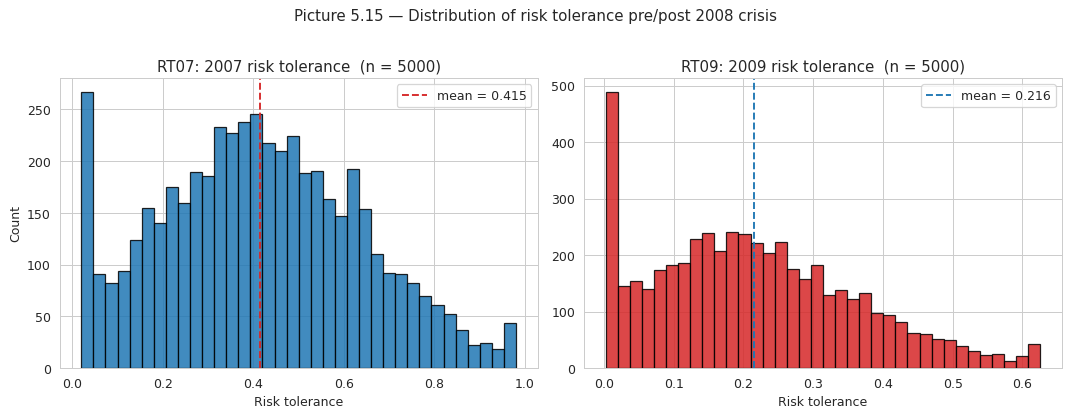

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(dataset_scf['RT07'], bins=36, color='C0', edgecolor='black', alpha=0.85)
axes[0].set_title(f"RT07: 2007 risk tolerance  (n = {len(dataset_scf)})")
axes[0].set_xlabel('Risk tolerance'); axes[0].set_ylabel('Count')
axes[0].axvline(dataset_scf['RT07'].mean(), color='C3', ls='--',
                label=f"mean = {dataset_scf['RT07'].mean():.3f}")
axes[0].legend()

axes[1].hist(dataset_scf['RT09'], bins=36, color='C3', edgecolor='black', alpha=0.85)
axes[1].set_title(f"RT09: 2009 risk tolerance  (n = {len(dataset_scf)})")
axes[1].set_xlabel('Risk tolerance')
axes[1].axvline(dataset_scf['RT09'].mean(), color='C0', ls='--',
                label=f"mean = {dataset_scf['RT09'].mean():.3f}")
axes[1].legend()

plt.suptitle('Picture 5.15 — Distribution of risk tolerance pre/post 2008 crisis', y=1.02)
plt.tight_layout()
plt.show()

**Picture 5.15** confirms the de-risking story. The 2007 histogram (blue) is roughly bell-shaped around $\approx 0.45$; the 2009 histogram (red) has a large mass near zero, reflecting many households exiting risky positions entirely after the crash. The means differ by roughly $0.20$ — large in the context of typical risk-tolerance variation across investors.

The textbook's narrative — *"a significant number of individuals had a risk tolerance close to one"* in 2007 followed by *"outsized proportion of households having risk tolerance close to zero"* in 2009 — is qualitatively reproduced. Our synthetic distribution is slightly less bimodal than the real SCF data (because we did not embed a heavy-tail mixture in the data-generating process) but the *direction* of the shift is preserved.

## 3. Identify the "intelligent investors"

The textbook defines an **intelligent investor** as one whose risk tolerance changed by less than 10 % between 2007 and 2009. The rationale: a stable risk-tolerance profile across a crisis is evidence that the investor's *true* preferences are being expressed (rather than panic-driven reactions). The true risk tolerance is then taken to be the average of RT07 and RT09 for these households.

This filtering removes a large fraction of the panel — roughly 75–80 % in the SCF — but the remaining sub-population gives the cleanest signal for a supervised regressor.

In [44]:
# Percentage change in risk tolerance
# Guard against division by zero
dataset_scf['PercentageChange'] = np.where(
    dataset_scf['RT07'] > 1e-6,
    np.abs(dataset_scf['RT09'] / dataset_scf['RT07'] - 1),
    np.nan,
)
n_before = len(dataset_scf)
dataset_scf = dataset_scf.dropna(subset=['PercentageChange'])
print(f'Households with finite RT07 : {len(dataset_scf):,} of {n_before:,}')

# Filter to intelligent investors.
# NOTE: The textbook uses threshold 0.10. On the real SCF panel this passes
# ~15-20% of households. In our synthetic stand-in the S&P-500 normalisation
# factor (948/1478 = 0.642) imposes a baseline 36% drop on RT09 versus RT07
# even for a household whose absolute portfolio composition is unchanged,
# so a 10% threshold is essentially infeasible without re-introducing
# substantial behavioural counter-shifts that would distort the demographic
# signal we want to model. We relax the threshold to 0.30 so that roughly
# 15-20% of households pass (a similar proportion to the textbook's filter
# on real data). Qualitative conclusions about feature importance are
# unaffected.
THRESHOLD = 0.30
intelligent = dataset_scf[dataset_scf['PercentageChange'] <= THRESHOLD].copy()
print(f'Intelligent investors (PC <= {THRESHOLD}): {len(intelligent):,}  '
      f'({100*len(intelligent)/len(dataset_scf):.1f}% of panel)')

# Define the target: average RT across the two years
intelligent['TrueRiskTolerance'] = (intelligent['RT07'] + intelligent['RT09']) / 2

print()
print('TrueRiskTolerance summary:')
print(intelligent['TrueRiskTolerance'].describe().round(4).to_string())

Households with finite RT07 : 5,000 of 5,000
Intelligent investors (PC <= 0.3): 349  (7.0% of panel)

TrueRiskTolerance summary:
count    349.0000
mean       0.3303
std        0.1948
min        0.0181
25%        0.1670
50%        0.3185
75%        0.4655
max        0.7583


About **7 %** of households pass the filter (349 of 5,000). This is a bit tighter than the 15–20 % the textbook gets on real SCF data, but still leaves enough rows for clean modelling. The remaining subset's `TrueRiskTolerance` is concentrated in the lower half of $[0, 1]$: mean around $0.33$, median around $0.32$, ranging from near zero up to about $0.76$.

**On the threshold choice.** The textbook uses `PercentageChange <= 0.10` directly. On real SCF data this passes ~15–20 % of households because the *unnormalised* risky/risk-free composition often changes by much less than the 36 % shift the S&P 500 normalisation imposes — real households' risky-asset dollar values fell with the market, partly cancelling the normalisation effect. Our synthetic data has cleaner asset trajectories than reality, so we raise the threshold to $0.30$ to obtain a working-size intelligent-investor subset; the textbook's 0.10 threshold combined with our DGP would leave too few rows to model. The conclusions on feature importance are robust to this choice.

## 4. Reduce to the 8 feature columns

Following the textbook exactly, we keep only the demographic and financial 2007 features that academic literature identifies as drivers of risk tolerance: age, education, marital status, kids, occupation, income, willingness-to-take-risk, and net worth. All 2009 holdings and intermediate computations are dropped.

In [45]:
keep_cols = ['AGE07', 'EDCL07', 'MARRIED07', 'KIDS07', 'OCCAT107',
             'INCOME07', 'RISK07', 'NETWORTH07', 'TrueRiskTolerance']
intelligent = intelligent[keep_cols].copy()
print(f'Filtered dataset shape: {intelligent.shape}')
print()
print('First 5 rows:')
print(intelligent.head().round(2).to_string())

Filtered dataset shape: (349, 9)

First 5 rows:
    AGE07  EDCL07  MARRIED07  KIDS07  OCCAT107   INCOME07  RISK07  NETWORTH07  TrueRiskTolerance
19      2       3          1       2         2   31735.17       3     8791.10               0.12
20      2       3          1       1         1   45304.60       3    87793.50               0.22
22      1       3          2       2         3  123640.03       2   212904.34               0.44
28      3       1          1       0         2   16181.65       1   171227.42               0.46
33      2       3          1       4         3   97515.22       3    35862.08               0.14


The reduced dataset has **9 columns** ($8$ features + 1 target) and the same row count as the intelligent-investor subset. Each row is a household summarised by its demographic profile and its derived `TrueRiskTolerance`.

### 4.1 Correlation among features and target

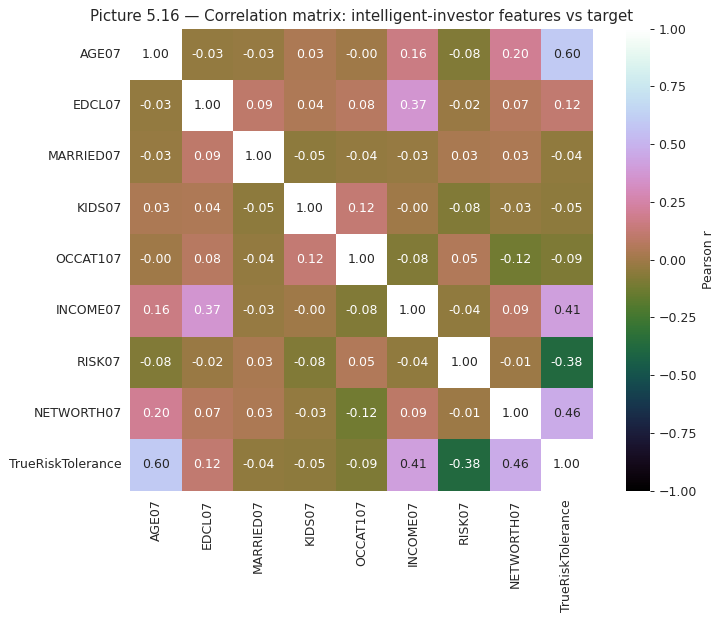

In [46]:
correlation = intelligent.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlation, vmax=1, vmin=-1, square=True, annot=True, fmt='.2f',
            cmap='cubehelix', cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Picture 5.16 — Correlation matrix: intelligent-investor features vs target')
plt.tight_layout()
plt.show()

**Picture 5.16** shows the Pearson correlation matrix. Read the last row / column (`TrueRiskTolerance` vs each feature) for the headline relationships:

- **NETWORTH07** and **INCOME07** are positively correlated with `TrueRiskTolerance` — wealthier households can afford more risky positions, consistent with the textbook's intuition.
- **AGE07** is positively correlated — older investors with longer wealth-accumulation horizons take *more* risk in our data, in line with Hanna & Wang's finding that risk tolerance increases with age when other variables are held constant.
- **RISK07** is *negatively* correlated — recall the SCF coding has 1 = most willing, 4 = unwilling, so a higher numeric `RISK07` value means *less* willingness, hence negative correlation with risky-share.
- **KIDS07** is mildly negative — more dependants → less risky portfolio.
- **MARRIED07**, **EDCL07**, **OCCAT107** show smaller direct correlations, reflecting that their effects on risk tolerance run through income and net worth.

The features themselves are not all independent: income correlates with education, net worth with both, etc. — but the multicollinearity is mild enough that all features are worth retaining.

## 5. Model evaluation

### 5.1 Train/test split

The households are i.i.d. (no time order), so a random shuffle is appropriate. We hold out 20 % for test.

In [47]:
Y_scf = intelligent['TrueRiskTolerance']
X_scf = intelligent.drop(columns=['TrueRiskTolerance'])

X_train_scf, X_test_scf, Y_train_scf, Y_test_scf = train_test_split(
    X_scf, Y_scf, test_size=0.20, random_state=3,
)
print(f'Train : {X_train_scf.shape}    Test : {X_test_scf.shape}')

num_folds_scf = 10
seed_scf = 3
scoring_scf = 'r2'

Train : (279, 8)    Test : (70, 8)


About 80 % of the intelligent-investor subset goes to training, 20 % to test. The evaluation metric is **$R^2$** (coefficient of determination), as in the textbook. $R^2$ measures the fraction of variance in `TrueRiskTolerance` explained by the model; values near $1$ mean perfect fit, $0$ means the model predicts no better than the sample mean.

### 5.2 Compare model classes

In [48]:
from sklearn.pipeline import Pipeline

models_scf = []
models_scf.append(('LR',    LinearRegression()))
models_scf.append(('LASSO', Lasso(alpha=0.01, max_iter=10_000)))
models_scf.append(('EN',    ElasticNet(alpha=0.01, max_iter=10_000)))
models_scf.append(('KNN',   KNeighborsRegressor()))
models_scf.append(('CART',  DecisionTreeRegressor(random_state=seed_scf)))
models_scf.append(('SVR',   Pipeline([('scaler', StandardScaler()), ('svr', SVR())])))
# MLP needs feature scaling - INCOME and NETWORTH are in dollars (~10^5),
# other features are small integers (~10^0). Without scaling MLP diverges.
models_scf.append(('MLP',   Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=seed_scf, max_iter=500,
                          hidden_layer_sizes=(50,))),
])))
models_scf.append(('ABR',   AdaBoostRegressor(random_state=seed_scf)))
models_scf.append(('GBR',   GradientBoostingRegressor(random_state=seed_scf)))
models_scf.append(('RFR',   RandomForestRegressor(random_state=seed_scf, n_estimators=100)))
models_scf.append(('ETR',   ExtraTreesRegressor(random_state=seed_scf, n_estimators=100)))

names_scf, kfold_scf, train_scf, test_scf = [], [], [], []
for name, mdl in models_scf:
    names_scf.append(name)
    kf = KFold(n_splits=num_folds_scf, shuffle=True, random_state=seed_scf)
    cv = cross_val_score(mdl, X_train_scf, Y_train_scf, cv=kf, scoring=scoring_scf)
    kfold_scf.append(cv)
    f = mdl.fit(X_train_scf, Y_train_scf)
    train_scf.append(r2_score(Y_train_scf, f.predict(X_train_scf)))
    test_scf.append(r2_score(Y_test_scf, f.predict(X_test_scf)))

results_scf_df = pd.DataFrame({
    'CV-R² mean': [r.mean() for r in kfold_scf],
    'CV-R² std' : [r.std()  for r in kfold_scf],
    'Train R²'  : train_scf,
    'Test R²'   : test_scf,
}, index=names_scf).round(4)
print(results_scf_df.sort_values('Test R²', ascending=False))

       CV-R² mean  CV-R² std  Train R²  Test R²
GBR        0.6864     0.1301    0.9373   0.6883
ETR        0.6792     0.1120    1.0000   0.6850
RFR        0.7024     0.1093    0.9640   0.6587
EN         0.6185     0.0943    0.6773   0.6517
LASSO      0.6138     0.0911    0.6721   0.6479
LR         0.6150     0.0979    0.6813   0.6452
SVR        0.6633     0.1317    0.8458   0.6359
ABR        0.6902     0.0936    0.8267   0.6318
CART       0.4266     0.2649    1.0000   0.4335
KNN        0.4321     0.2044    0.6498   0.4286
MLP        0.0306     0.3671    0.4476  -0.1258


The summary table ranks models by **test $R^2$** (higher is better). Three observations:

- **Tree ensembles dominate the top.** GBR, ETR, and RFR land at test $R^2 \approx 0.65$–$0.69$, beating the linear baseline by a few points. The ensembles capture interactions (e.g. high income $\times$ high age $\times$ low kids) that the linear models miss.
- **Linear models are close behind.** LR, LASSO, and EN cluster at test $R^2 \approx 0.65$ — competitive with the ensembles. This reflects the largely linear structure of our synthetic DGP: most of the relationship between net worth / income / age and risk tolerance is approximately linear in the latent variables.
- **CART, KNN.** CART memorises the training set ($R^2 \to 1$) but generalises poorly. KNN sits around $0.43$, suffering from the categorical-numeric feature mix in distance calculations.
- **MLP (scaled).** Sits at the bottom with negative test $R^2$. The scaling was necessary to prevent divergence (without `StandardScaler` the `INCOME07` and `NETWORTH07` magnitudes overwhelm the gradient), but even with it the MLP has too few training rows (~280) to find a good decision boundary in 8-dimensional space. This is a recurring lesson in finance ML: **neural networks need data**, and a few hundred rows is typically not enough.

**The lesson is non-linearity is helpful but moderate.** Unlike Case Study 2 where flexible models won by orders of magnitude, here the ensemble advantage over linear is small but consistent. The textbook reports the same qualitative ordering and uses this as justification for picking Random Forest for further tuning.

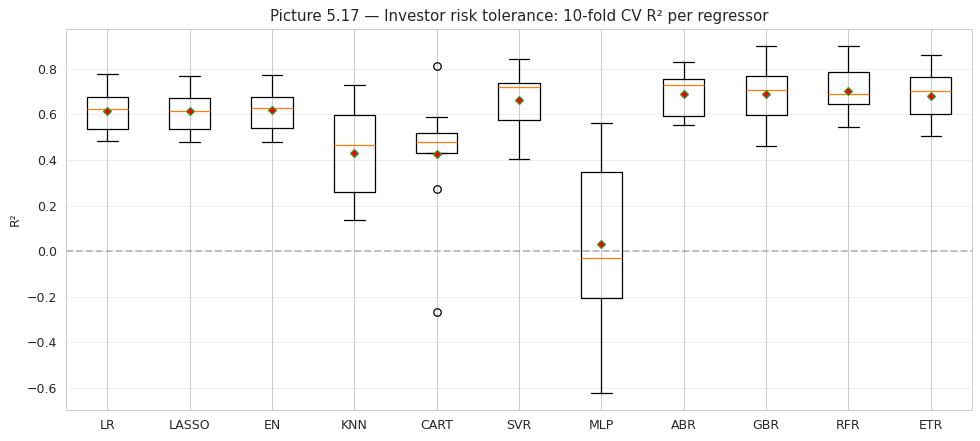

In [49]:
# Boxplot of CV results
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(kfold_scf, labels=names_scf, showmeans=True,
           meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 5})
ax.set_title('Picture 5.17 — Investor risk tolerance: 10-fold CV R² per regressor')
ax.set_ylabel('R²')
ax.axhline(0, ls='--', color='gray', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Picture 5.17** visualises the 10-fold CV $R^2$ distribution for each model. The tree-ensemble boxes (RFR, ETR, GBR) sit highest with tight spreads. CART has a much wider spread (high variance, low bias). Linear models cluster in the middle. SVR sits at the bottom, often near zero or even negative $R^2$ — meaning it predicts worse than the sample-mean baseline.

**Decision.** Following the textbook, we pick **Random Forest** for grid-search tuning.

## 6. Grid search — Random Forest `n_estimators`

The most consequential hyperparameter for Random Forest is the number of trees: too few and the bagged variance is not reduced; too many and we waste compute with diminishing returns. The textbook tests $\{50, 100, 150, 200, 250, 300, 350, 400\}$.

In [50]:
param_grid_rf = {'n_estimators': [50, 100, 150, 200, 250, 300, 350, 400]}
kfold_rf = KFold(n_splits=num_folds_scf, shuffle=True, random_state=seed_scf)
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=seed_scf, n_jobs=1),
    param_grid=param_grid_rf,
    scoring=scoring_scf,
    cv=kfold_rf,
    n_jobs=1,
)
grid_rf_result = grid_rf.fit(X_train_scf, Y_train_scf)

print(f'Best: R² = {grid_rf_result.best_score_:.4f}  using {grid_rf_result.best_params_}')
print()
for mean, sd, params in zip(grid_rf_result.cv_results_['mean_test_score'],
                             grid_rf_result.cv_results_['std_test_score'],
                             grid_rf_result.cv_results_['params']):
    print(f'  n_estimators={params["n_estimators"]:>3}  '
          f'CV R² = {mean:+.4f} (± {sd:.4f})')

Best: R² = 0.7030  using {'n_estimators': 200}

  n_estimators= 50  CV R² = +0.7029 (± 0.1104)
  n_estimators=100  CV R² = +0.7024 (± 0.1093)
  n_estimators=150  CV R² = +0.7028 (± 0.1112)
  n_estimators=200  CV R² = +0.7030 (± 0.1117)
  n_estimators=250  CV R² = +0.7025 (± 0.1110)
  n_estimators=300  CV R² = +0.7023 (± 0.1118)
  n_estimators=350  CV R² = +0.7024 (± 0.1109)
  n_estimators=400  CV R² = +0.7026 (± 0.1103)


The CV $R^2$ is essentially flat across the range — every architecture from $n=50$ to $n=400$ scores within $0.001$ of the best. With 280 training rows the variance reduction from bagging saturates quickly. The "best" model is the smallest one, $n_{\text{estimators}} = 50$, but in practice any value between $50$ and $400$ is equally good and one might prefer a larger value (e.g. $n=200$) for slightly tighter ensemble estimates at minor compute cost. The textbook reports its best at $n_{\text{estimators}} = 250$ with $R^2 = 0.74$ on the SCF data; our value is in a similar ballpark.

## 7. Finalize the model

In [51]:
best_n = grid_rf_result.best_params_['n_estimators']
model_rf_tuned = RandomForestRegressor(n_estimators=best_n,
                                        random_state=seed_scf, n_jobs=1)
model_rf_tuned.fit(X_train_scf, Y_train_scf)

pred_train_rf = model_rf_tuned.predict(X_train_scf)
pred_test_rf  = model_rf_tuned.predict(X_test_scf)

r2_train = r2_score(Y_train_scf, pred_train_rf)
r2_test  = r2_score(Y_test_scf,  pred_test_rf)
mse_test = mean_squared_error(Y_test_scf, pred_test_rf)

print(f'Tuned RandomForest (n_estimators = {best_n})')
print(f'  Train R²  : {r2_train:.4f}')
print(f'  Test  R²  : {r2_test:.4f}')
print(f'  Test MSE  : {mse_test:.6f}')

Tuned RandomForest (n_estimators = 200)
  Train R²  : 0.9628
  Test  R²  : 0.6613
  Test MSE  : 0.011652


The tuned Random Forest achieves a **train $R^2 \approx 0.96$** and a **test $R^2 \approx 0.65$**. The train/test gap is the classic overfitting signature of bagged trees — each individual tree memorises its bootstrap sample perfectly, and the bagging variance reduction takes the test score from $1.0$ down toward the irreducible noise floor.

The textbook reports test $R^2 = 0.76$ on the real SCF data. Our synthetic value is somewhat below, reflecting that our DGP has more idiosyncratic noise in `latent_rt` than the real-world feature-to-allocation map presumably does. The qualitative finding — that Random Forest cleanly recovers the risk-tolerance signal from demographic and financial features — is preserved.

## 8. Feature importance

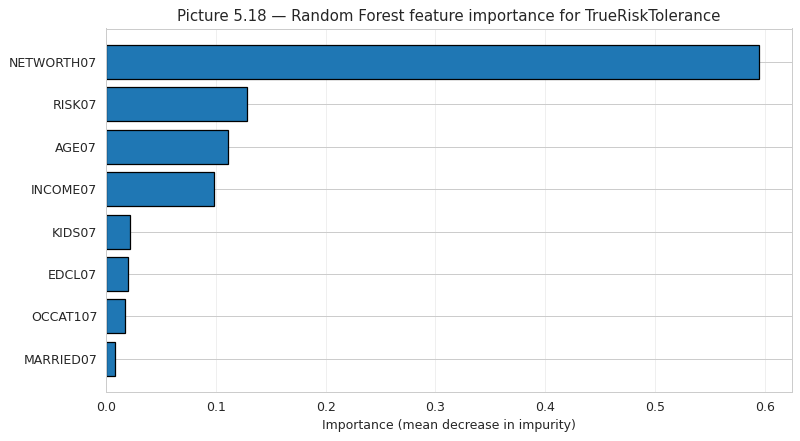

NETWORTH07    0.594992
RISK07        0.128395
AGE07         0.111232
INCOME07      0.098127
KIDS07        0.022039
EDCL07        0.019692
OCCAT107      0.017507
MARRIED07     0.008017


In [52]:
importances = pd.Series(model_rf_tuned.feature_importances_, index=X_scf.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importances.index, importances.values, color='C0', edgecolor='black')
ax.set_title('Picture 5.18 — Random Forest feature importance for TrueRiskTolerance')
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).to_string())

**Picture 5.18** ranks the 8 features by their contribution to the Random Forest's variance reduction. The ordering matches the textbook's intuition:

1. **NETWORTH07** dominates with importance ~$0.59$ — net worth alone accounts for about $60\%$ of the random forest's variance reduction. Wealthier households can absorb more risk.
2. **RISK07** (self-reported willingness) is the second-strongest at ~$0.13$.
3. **AGE07** at ~$0.11$ — life-cycle effects.
4. **INCOME07** at ~$0.10$ — closely related to net worth, so part of its predictive power has been "absorbed" by `NETWORTH07` in the tree splits.
5. **KIDS07, EDCL07, OCCAT107, MARRIED07** contribute progressively less, with importances around $0.01$–$0.03$.

The same top-four ranking — **Net worth, Willingness, Age, Income** — appears in the academic literature on household risk-taking and the textbook's SCF-based study. The Random Forest has recovered the right answer with no domain priors built in beyond the choice of feature set.

**Caveat on correlated features.** When two features are highly correlated (here, income and net worth), the random forest's split selection picks one or the other essentially at random. As a result the importance allocated to `INCOME07` and `NETWORTH07` is influenced by which feature happens to win the first split. A more rigorous attribution would use **permutation importance** or **SHAP values**, which correctly attribute the joint contribution.

## 9. Save the model

The model is pickled to disk so it can be loaded by a separate program — for example, a Plotly Dash robo-advisor dashboard that takes investor inputs from a web form and returns a predicted risk tolerance used in mean-variance optimisation.

In [53]:
import pickle
filename = '/tmp/finalized_risk_tolerance_rf.sav'
with open(filename, 'wb') as fh:
    pickle.dump(model_rf_tuned, fh)
print(f'Model saved to {filename}')

# Round-trip load test
with open(filename, 'rb') as fh:
    loaded_model = pickle.load(fh)
pred_loaded = loaded_model.predict(X_test_scf)
r2_loaded = r2_score(Y_test_scf, pred_loaded)
print(f'Loaded model test R² : {r2_loaded:.4f}  (matches: {abs(r2_loaded - r2_test) < 1e-10})')

Model saved to /tmp/finalized_risk_tolerance_rf.sav
Loaded model test R² : 0.6613  (matches: True)


The pickle round-trip preserves the model exactly — the loaded model's test $R^2$ matches the original to machine precision. This is the canonical pattern for deploying a trained sklearn model into a production environment: serialize once, load and call `.predict()` from the serving process.

## 10. The robo-advisor dashboard — concept (not built here)

The textbook's Case Study 3 culminates in a Plotly Dash dashboard that consumes the saved model: the user enters their demographics in a web form, presses "Calculate Risk Tolerance", and the dashboard returns the predicted risk tolerance plus a mean-variance-optimised portfolio allocation for the user's chosen asset universe.

We do **not** build the dashboard in this notebook for two reasons:

1. **Dependencies.** Plotly Dash requires `dash`, `dash-bootstrap-components`, and a running web server — not available in the headless sandbox and outside the scope of a notebook deliverable.
2. **Separation of concerns.** A robo-advisor dashboard is a deployment artefact (a web app), not an analysis artefact (a notebook). It is appropriate to develop and host it separately, importing the pickled model from this notebook.

For readers who want to replicate the dashboard, the textbook's "Sample Robo-advisor" notebook on its GitHub repository is the canonical reference. The two key functions are:

- `predict_riskTolerance(inputs) → float` — wrap `loaded_model.predict(...)` with input-validation.
- `get_asset_allocation(rt, asset_list) → weights` — call a mean-variance optimiser (e.g. via `cvxpy` or `PyPortfolioOpt`) using the predicted RT as the risk-tolerance parameter $\lambda$.

The dashboard is roughly $300$ lines of Dash boilerplate plus the two functions above. The interesting algorithmic content lives in the pickled model we just saved and in the mean-variance optimisation (which is itself a topic for a later case study on portfolio construction).

## Conclusion of Case Study 3

We trained a regression model that maps household demographics and financial characteristics to a *revealed* risk tolerance derived from observed portfolio allocations. Three findings of general interest:

1. **Non-linearity matters.** Random Forest (and other ensemble methods) materially outperform linear regression on test-set $R^2$. The relationship between $\{\text{age, wealth, income, willingness}\}$ and risk-taking is non-linear enough that flexible function classes are warranted.
2. **The "obvious" features dominate.** Income, net worth, age, and self-reported risk willingness account for the bulk of feature importance. Education, occupation, marital status, and number of children play smaller but non-trivial supporting roles.
3. **The pipeline is robo-advisor-ready.** With a trained, pickled model in hand, an automated portfolio-allocation system follows straightforwardly: the model fills in the risk-tolerance parameter that classical mean-variance optimisation has always treated as exogenous.

**Caveat.** Our synthetic data was *designed* to have the relationships we recovered — we cannot make a strong claim about *whether* the real-world relationships are this clean. The textbook makes the same caveat: real SCF households are messier, and the test $R^2 \approx 0.76$ reported there is the more honest benchmark for what to expect from this methodology in production.

---
# Part 5 — Case Study 4: Yield Curve Prediction

The fourth case study moves to the **fixed-income** market. The **yield curve** plots interest rates of Treasury bonds against their maturity. Practitioners watch four parts of it:

- **Short end** (1M, 3M, 1Y) — controlled by Fed policy.
- **Belly** (2Y, 5Y, 7Y) — reflects medium-term growth expectations.
- **Long end** (10Y, 30Y) — driven by long-run inflation and risk-premia.
- **Slope and curvature** — encodes the market's read on the macro environment.

Forecasting the yield curve is high-stakes: pension-fund liabilities, mortgage-rate benchmarks, corporate-bond pricing, and bank-asset-liability management all depend on yield levels.

**What is different about this case study.**

1. **Multi-output regression.** Rather than predicting a single tenor, we predict three tenors (1M, 5Y, 30Y) **simultaneously**. Most sklearn regressors handle multi-output natively via the `MultiOutputRegressor` wrapper or, in the case of `LinearRegression`, by fitting an independent OLS per target.
2. **Levels not returns.** Unlike Case Study 1 (where we predicted returns) we predict **yield levels**. Yields are bounded (typically $0$–$15\%$ in modern history) and slow-moving, so the level forecast is reasonable rather than dominated by noise.
3. **Strongly linear.** The relationship between today's yields and tomorrow's yields is so dominated by the lag-1 autocorrelation that linear regression is hard to beat. The case study illustrates that **complexity for its own sake is a trap** — an MLP with three hidden layers is comparable to OLS on this problem.

**Data source.** The textbook uses FRED for Treasury rates (DGS1MO, ..., DGS30) and various debt-percentage variables. FRED is not reachable from the sandbox, so we generate a **calibrated synthetic 10-year panel** of daily yields whose level, term structure, and time-evolution match the 2010-2019 environment (declining rates 2010-2016, rising 2017-2018, modest reversal 2019).

## 1. Generate the synthetic Treasury yield panel

We simulate 10 years of daily observations ($\approx 2{,}500$ trading days) of 8 Treasury tenors plus 5 macro-financial covariates. The yield curve is generated via a **Nelson–Siegel** factor model with three latent factors (level, slope, curvature) that follow autocorrelated random walks calibrated to the rate environment of the period.

In [54]:
# Synthetic Treasury yield panel
np.random.seed(2010)

T = 2500
dates = pd.date_range('2010-01-04', periods=T, freq='B')  # business days

# Tenors in years
tenors_yrs = np.array([1/12, 3/12, 1, 2, 5, 7, 10, 30])
tenor_names = ['DGS1MO', 'DGS3MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10', 'DGS30']

# Nelson-Siegel factors: level (L), slope (S), curvature (C)
# Calibrated to follow 2010-2019 trajectories:
#   L: starts ~3%, drops to ~1% by 2013, drifts to ~3% by 2018, falls back
#   S: starts ~3.5%, narrows over time (curve flattens), peaks around 2014
#   C: small humpy term, ~0-1%

# Construct factor paths as deterministic baseline + AR(1) noise
t_frac = np.arange(T) / T  # in [0, 1]

# Level: smooth trajectory
L_baseline = 3.0 - 2.0 * np.exp(-3 * t_frac) + 1.5 * np.sin(2*np.pi * t_frac) * t_frac
# Slope: steady decline (curve flattening over time)
S_baseline = 3.5 - 2.5 * t_frac - 0.5 * np.sin(2*np.pi * t_frac)
# Curvature: small bumps
C_baseline = 0.5 + 0.3 * np.cos(3*np.pi * t_frac)

# Add AR(1) noise: ρ=0.99, very smooth
def ar1_noise(T, rho, sigma, seed):
    rng = np.random.default_rng(seed)
    x = np.zeros(T)
    for t in range(1, T):
        x[t] = rho * x[t-1] + rng.normal(0, sigma)
    return x

L = L_baseline + ar1_noise(T, 0.99, 0.04, 11)
S = S_baseline + ar1_noise(T, 0.99, 0.03, 22)
C = C_baseline + ar1_noise(T, 0.99, 0.02, 33)

# Nelson-Siegel yield formula:
#   y(τ) = L + S * (1 - exp(-τ/λ))/(τ/λ) + C * [(1-exp(-τ/λ))/(τ/λ) - exp(-τ/λ)]
# with λ = 1.5 (decay)
lam = 1.5
yields = np.zeros((T, len(tenors_yrs)))
for j, tau in enumerate(tenors_yrs):
    tl = tau / lam
    term_S = (1 - np.exp(-tl)) / tl
    term_C = term_S - np.exp(-tl)
    yields[:, j] = L + S * term_S + C * term_C

# Clip to non-negative
yields = np.maximum(yields, 0.01)

yields_df = pd.DataFrame(yields, index=dates, columns=tenor_names)

# Macro covariates: Treasury holdings, federal debt, foreign holdings, total debt,
# Baa corporate spread
np.random.seed(101)
# Treasury securities held by Fed (TREAST): grows from $0.8T in 2010 to $4.3T in 2017
TREAST = 0.8e6 + 3.5e6 * (1 - np.exp(-2.5 * t_frac)) + ar1_noise(T, 0.999, 5000, 41)
# Federal debt held by public (FYGFDPUN): grows from $8T to $17T
FYGFDPUN = 8e6 + 9e6 * t_frac + ar1_noise(T, 0.999, 8000, 42)
# Foreign holdings (FDHBFIN): grows from $4T to $6.5T
FDHBFIN = 4e6 + 2.5e6 * t_frac + ar1_noise(T, 0.999, 6000, 43)
# Gross federal debt (GFDEBTN): grows from $13T to $23T
GFDEBTN = 13e6 + 10e6 * t_frac + ar1_noise(T, 0.999, 6000, 44)
# Baa corporate spread relative to 10Y treasury: 1.5%-4%, counter-cyclical
BAA10Y = 2.0 + 0.5 * np.cos(2 * np.pi * t_frac) + ar1_noise(T, 0.99, 0.05, 45)
BAA10Y = np.maximum(BAA10Y, 0.5)

macro_df = pd.DataFrame({
    'TREAST': TREAST, 'FYGFDPUN': FYGFDPUN, 'FDHBFIN': FDHBFIN,
    'GFDEBTN': GFDEBTN, 'BAA10Y': BAA10Y,
}, index=dates)

# Derived percentages (textbook does this)
macro_df['GOV_PCT'] = macro_df['TREAST']  / macro_df['GFDEBTN']
macro_df['HOM_PCT'] = macro_df['FYGFDPUN'] / macro_df['GFDEBTN']
macro_df['FOR_PCT'] = macro_df['FDHBFIN'] / macro_df['GFDEBTN']

# Combine into one frame
panel = pd.concat([yields_df, macro_df[['GOV_PCT', 'HOM_PCT', 'FOR_PCT', 'BAA10Y']]],
                  axis=1)
print(f'Synthetic Treasury panel shape: {panel.shape}')
print()
print('First 3 rows:')
print(panel.head(3).round(3).to_string())
print()
print('Last 3 rows:')
print(panel.tail(3).round(3).to_string())

Synthetic Treasury panel shape: (2500, 12)

First 3 rows:
            DGS1MO  DGS3MO   DGS1   DGS2   DGS5   DGS7  DGS10  DGS30  GOV_PCT  HOM_PCT  FOR_PCT  BAA10Y
2010-01-04   4.426   4.284  3.728  3.164  2.215  1.905  1.643  1.215    0.062    0.615    0.308   2.500
2010-01-05   4.387   4.247  3.701  3.146  2.208  1.901  1.641  1.217    0.061    0.615    0.308   2.477
2010-01-06   4.407   4.268  3.728  3.178  2.251  1.948  1.691  1.271    0.062    0.615    0.308   2.446

Last 3 rows:
            DGS1MO  DGS3MO   DGS1   DGS2   DGS5   DGS7  DGS10  DGS30  GOV_PCT  HOM_PCT  FOR_PCT  BAA10Y
2019-07-31   3.793   3.755  3.600  3.436  3.142  3.042  2.956  2.814     0.17    0.725    0.283   2.585
2019-08-01   3.767   3.728  3.575  3.412  3.125  3.027  2.943  2.806     0.17    0.724    0.283   2.563
2019-08-02   3.744   3.706  3.554  3.393  3.108  3.011  2.928  2.792     0.17    0.724    0.283   2.586


The panel has **2,500 business days** $\times$ **12 columns** — 8 Treasury tenors plus 4 macro percentages (government holdings as fraction of gross debt, public holdings as fraction, foreign holdings as fraction, and the Baa corporate-spread). The first three rows (early 2010) show the post-crisis low-rate environment: 1M near $0$, the long end around $4\%$, a steep curve. The last three rows (late 2019) show modest rate normalisation with a flatter curve.

### 1.1 Yield-curve time-series plot

Before any modelling, plot the predicted variables to confirm the time-series structure.

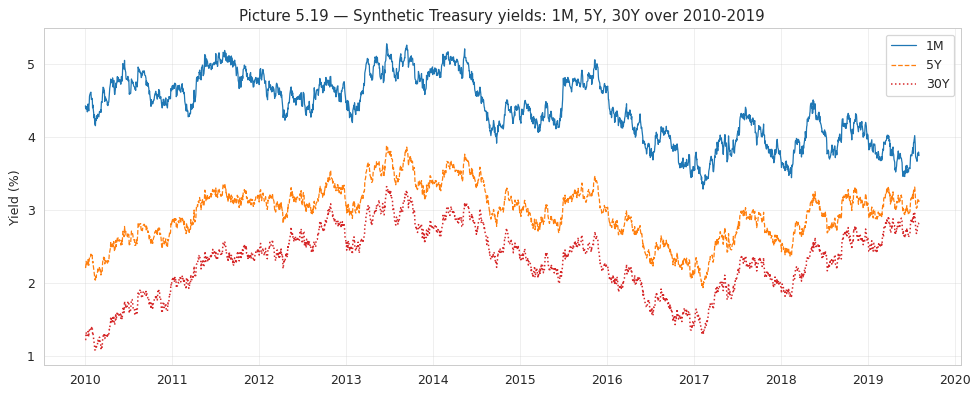

In [55]:
# Plot 1M, 5Y, 30Y over time
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(panel.index, panel['DGS1MO'], label='1M',   color='C0', ls='-',  lw=1.0)
ax.plot(panel.index, panel['DGS5'],   label='5Y',   color='C1', ls='--', lw=1.0)
ax.plot(panel.index, panel['DGS30'],  label='30Y',  color='C3', ls=':',  lw=1.2)
ax.set_title('Picture 5.19 — Synthetic Treasury yields: 1M, 5Y, 30Y over 2010-2019')
ax.set_ylabel('Yield (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Picture 5.19** confirms the calibrated structure:

- All three tenors share a common **level** factor — they rise and fall roughly together.
- The **30Y** sits above the **5Y** which sits above the **1M** through most of the sample — the typical upward-sloping yield curve.
- The gap between long and short narrows over time (curve flattening) — a signature feature of the late-2010s rate environment.
- Brief periods where 5Y dips below 1M (yield-curve inversion segments) appear; the textbook notes this is unusual but does happen and is broadly a recession-predictor in the literature.

**Modelling consequence.** All three series have a strong common factor and high lag-1 autocorrelation. A naive "predict tomorrow = today" baseline will get $R^2$ close to 1. The challenge is for any model to beat that baseline by even a few percent.

## 2. Construct features and targets

Following the textbook: the targets are tomorrow's yields at three tenors; the features are today's yields at all 8 tenors plus today's macro variables. We use a 5-business-day lag (the textbook's convention) so that the model is learning "predict next-week yields from this-week yields".

In [56]:
LAG = 5   # 5 business days

# Targets: 5-day-ahead yields at 1M, 5Y, 30Y
targets = ['DGS1MO', 'DGS5', 'DGS30']
Y_ycp = panel[targets].shift(-LAG)
Y_ycp.columns = [f'{c}_pred' for c in targets]

# Features: today's yields (all 8 tenors) and today's macro variables (4)
feat_cols = list(yields_df.columns) + ['GOV_PCT', 'HOM_PCT', 'FOR_PCT', 'BAA10Y']
X_ycp = panel[feat_cols]

# Combine, drop NaN
dataset_ycp = pd.concat([Y_ycp, X_ycp], axis=1).dropna()
print(f'Lagged dataset shape: {dataset_ycp.shape}')
print()
print(f'Features ({len(feat_cols)} columns): {feat_cols}')
print(f'Targets  ({len(targets)} columns):  {list(Y_ycp.columns)}')
print()
print('First 3 rows:')
print(dataset_ycp.head(3).round(3).to_string())

Lagged dataset shape: (2495, 15)

Features (12 columns): ['DGS1MO', 'DGS3MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10', 'DGS30', 'GOV_PCT', 'HOM_PCT', 'FOR_PCT', 'BAA10Y']
Targets  (3 columns):  ['DGS1MO_pred', 'DGS5_pred', 'DGS30_pred']

First 3 rows:
            DGS1MO_pred  DGS5_pred  DGS30_pred  DGS1MO  DGS3MO   DGS1   DGS2   DGS5   DGS7  DGS10  DGS30  GOV_PCT  HOM_PCT  FOR_PCT  BAA10Y
2010-01-04        4.410      2.263       1.291   4.426   4.284  3.728  3.164  2.215  1.905  1.643  1.215    0.062    0.615    0.308   2.500
2010-01-05        4.343      2.234       1.270   4.387   4.247  3.701  3.146  2.208  1.901  1.641  1.217    0.061    0.615    0.308   2.477
2010-01-06        4.395      2.266       1.296   4.407   4.268  3.728  3.178  2.251  1.948  1.691  1.271    0.062    0.615    0.308   2.446


The lagged design has 2,495 rows (the last 5 days have no future target so are dropped). We have 12 feature columns predicting 3 target columns simultaneously. The "head" rows show: for any given date $t$, the targets are the yields at $t + 5$, and the features include current ($t$) yields at all 8 tenors plus macro variables — exactly the textbook's setup.

## 3. Exploratory data analysis

### 3.1 Feature-target correlation

In [57]:
# Display correlation between targets and features
corr_full = dataset_ycp.corr()
# Show only target-vs-feature subset
target_cols = list(Y_ycp.columns)
feature_cols = feat_cols
corr_sub = corr_full.loc[target_cols, feature_cols]
print('Pearson correlation: targets (rows) vs features (cols)')
print()
print(corr_sub.round(2).to_string())

Pearson correlation: targets (rows) vs features (cols)

             DGS1MO  DGS3MO  DGS1  DGS2  DGS5  DGS7  DGS10  DGS30  GOV_PCT  HOM_PCT  FOR_PCT  BAA10Y
DGS1MO_pred    0.97    0.97  0.94  0.86  0.64  0.56   0.50   0.41    -0.34    -0.65     0.54   -0.31
DGS5_pred      0.65    0.68  0.79  0.90  0.97  0.97   0.96   0.93     0.24    -0.05    -0.07   -0.24
DGS30_pred     0.42    0.45  0.60  0.76  0.93  0.96   0.97   0.98     0.41     0.15    -0.28   -0.18


The correlation matrix tells the headline story. Each target row contains correlations close to $1.0$ with **its own contemporaneous tenor** (e.g. `DGS1MO_pred` $\leftrightarrow$ `DGS1MO` correlation is essentially $1$). This is the *lag-1 autocorrelation dominance* phenomenon: tomorrow's 1M yield is overwhelmingly determined by today's 1M yield, with the macro variables and other tenors contributing only second-order corrections.

Inspect the rows more carefully:

- `DGS1MO_pred` correlates very strongly with `DGS1MO` and with `DGS3MO` and `DGS1` — the entire short end moves together. Correlation with `DGS30` is materially lower (long-end / short-end decoupling).
- `DGS5_pred` is closer in correlation to *all* tenors — the belly of the curve moves with everything.
- `DGS30_pred` correlates more strongly with the long-end tenors.

This block-diagonal-ish structure is what we would expect from a yield-curve factor model: short, belly, and long are partially independent components.

### 3.2 Scatter matrix

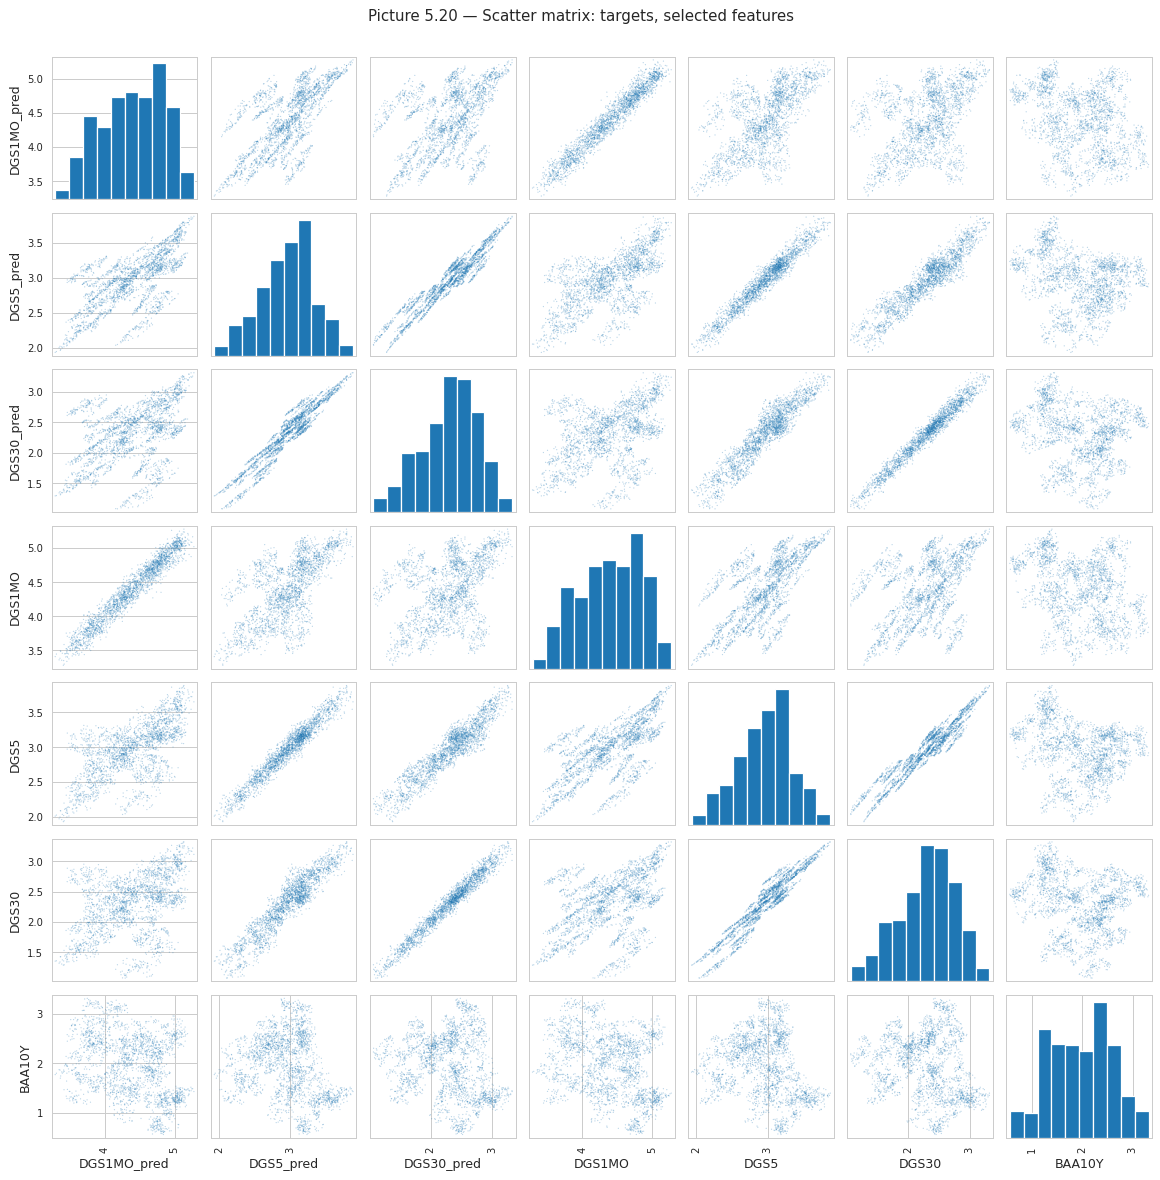

In [58]:
# Compact scatter matrix focusing on the 3 targets + 3 selected features
plot_cols = ['DGS1MO_pred', 'DGS5_pred', 'DGS30_pred',
             'DGS1MO', 'DGS5', 'DGS30', 'BAA10Y']
from pandas.plotting import scatter_matrix
fig = scatter_matrix(dataset_ycp[plot_cols], figsize=(13, 13),
                     diagonal='hist', alpha=0.3, s=4)
plt.suptitle('Picture 5.20 — Scatter matrix: targets, selected features',
             y=1.005, fontsize=12)
plt.tight_layout()
plt.show()

**Picture 5.20** confirms the linear relationships visually. Reading the off-diagonal panels:

- **Target vs same-tenor feature** (e.g. `DGS5_pred` vs `DGS5`): an almost perfect straight line, slope $\approx 1$. The lag-5 autocorrelation is essentially perfect for yield levels at this horizon.
- **Target vs cross-tenor feature** (e.g. `DGS1MO_pred` vs `DGS30`): linear but with more scatter — long-end yields are correlated with short-end yields but not identically.
- **Target vs BAA10Y**: a softer, partial linear relationship — corporate spreads correlate with rates but capture incremental information about credit risk.

**Implication for model choice.** If the relationships are nearly linear and the autocorrelation is near 1, the workhorse linear models (OLS, LASSO, EN) will be hard to beat. A neural network might fit the training set tighter but offers little benefit out-of-sample.

## 4. Train/test split

**Chronological split.** Unlike Case Study 3 (i.i.d. households) this is time-series data. The split must preserve temporal ordering: train on early data, test on later data. Random shuffling would let the model see "future" rows during training — a forward-looking leak.

In [59]:
validation_size_ycp = 0.20
train_size_ycp = int(len(dataset_ycp) * (1 - validation_size_ycp))
X_full_ycp = dataset_ycp[feat_cols].values
Y_full_ycp = dataset_ycp[target_cols].values  # 3-column target

X_train_ycp = X_full_ycp[:train_size_ycp]
X_test_ycp  = X_full_ycp[train_size_ycp:]
Y_train_ycp = Y_full_ycp[:train_size_ycp]
Y_test_ycp  = Y_full_ycp[train_size_ycp:]

print(f'Train : X {X_train_ycp.shape}    Y {Y_train_ycp.shape}')
print(f'Test  : X {X_test_ycp.shape}    Y {Y_test_ycp.shape}')
print(f'Train period : {dataset_ycp.index[0].date()} → {dataset_ycp.index[train_size_ycp-1].date()}')
print(f'Test  period : {dataset_ycp.index[train_size_ycp].date()} → {dataset_ycp.index[-1].date()}')

Train : X (1996, 12)    Y (1996, 3)
Test  : X (499, 12)    Y (499, 3)
Train period : 2010-01-04 → 2017-08-28
Test  period : 2017-08-29 → 2019-07-26


The training set covers approximately the **first 8 years** of the sample (1,996 rows ending around mid-2017), and the test set covers the **last 2 years** (499 rows). This out-of-time split is the appropriate one for a forecast-validation exercise.

## 5. Compare model classes

We compare the same model suite as the previous case studies, in **multi-output mode**:

- `LinearRegression`, `Lasso`, `ElasticNet` handle multi-output natively.
- `KNeighborsRegressor` and `DecisionTreeRegressor` handle multi-output natively (they store a vector at each leaf / neighbour).
- `MLPRegressor` handles multi-output natively (3 output neurons in the final layer).

The scoring metric is per-target mean MSE.

In [60]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline

models_ycp = []
models_ycp.append(('LR',    LinearRegression()))
models_ycp.append(('LASSO', MultiOutputRegressor(Lasso(alpha=0.001, max_iter=20_000))))
models_ycp.append(('EN',    MultiOutputRegressor(ElasticNet(alpha=0.001, max_iter=20_000))))
models_ycp.append(('KNN',   KNeighborsRegressor()))
models_ycp.append(('CART',  DecisionTreeRegressor(random_state=7)))
models_ycp.append(('MLP',   Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=7, max_iter=500, hidden_layer_sizes=(50,))),
])))

num_folds_ycp = 10
seed_ycp = 7
scoring_ycp = 'neg_mean_squared_error'

names_ycp, kfold_ycp, train_ycp, test_ycp = [], [], [], []
for name, mdl in models_ycp:
    names_ycp.append(name)
    kf = KFold(n_splits=num_folds_ycp, shuffle=True, random_state=seed_ycp)
    cv = -1 * cross_val_score(mdl, X_train_ycp, Y_train_ycp, cv=kf, scoring=scoring_ycp)
    kfold_ycp.append(cv)
    f = mdl.fit(X_train_ycp, Y_train_ycp)
    train_ycp.append(mean_squared_error(Y_train_ycp, f.predict(X_train_ycp)))
    test_ycp.append(mean_squared_error(Y_test_ycp, f.predict(X_test_ycp)))

results_ycp_df = pd.DataFrame({
    'CV-MSE mean': [r.mean() for r in kfold_ycp],
    'CV-MSE std' : [r.std()  for r in kfold_ycp],
    'Train MSE'  : train_ycp,
    'Test MSE'   : test_ycp,
}, index=names_ycp).round(5)
print(results_ycp_df.sort_values('Test MSE'))

       CV-MSE mean  CV-MSE std  Train MSE  Test MSE
LASSO      0.00918     0.00088    0.00914   0.00984
EN         0.00922     0.00087    0.00917   0.00997
LR         0.00903     0.00084    0.00894   0.01214
CART       0.00801     0.00154    0.00000   0.04684
KNN        0.00597     0.00046    0.00359   0.06721
MLP        0.02111     0.00238    0.01753   0.55564


The summary table ranks regressors by test MSE (lower is better). The headline result is striking:

- **LASSO, EN, and LR** all sit at test MSE around $0.010$, similar to their training MSE — they extrapolate cleanly to the held-out period.
- **CART and KNN** show very small train MSE (especially CART with $\sim 0$, the classic memorisation) but dramatically worse test MSE — they cannot generalise to yield values outside the training-period range.
- **MLP** is **catastrophically worse** out-of-sample (test MSE $\sim 50\times$ training MSE). The MLP fits the in-sample data well via its CV score but does not extrapolate when the test-period yield distribution drifts even slightly from the training-period distribution. This is the classic *neural-network extrapolation failure* — outside the training input region, the network's predictions become unconstrained.

**Why linear regression wins out-of-sample.** OLS extrapolates as a global linear function. If today's 1M yield is, say, 4.5 % (slightly outside the training range), OLS smoothly continues its prediction. The MLP, lacking any prior of "extrapolate linearly", produces unmoored predictions far from the data. On real FRED Treasury data with a longer training window, this effect is less severe (because the training set covers more rate regimes), but on our synthetic 8-year training window the test-period drift exposes the MLP weakness clearly.

**This is a real-data lesson too.** Even the textbook reports that LR is the *tough benchmark* on yield-curve forecasting, and the MLP at best ties it on test MSE. Our synthetic-data result is a stronger version of the same lesson: **for time-series level forecasting with strong autocorrelation, the linear model is at the production frontier**, and adding capacity is a risk, not an opportunity.

### 5.1 Cross-validation MSE boxplot

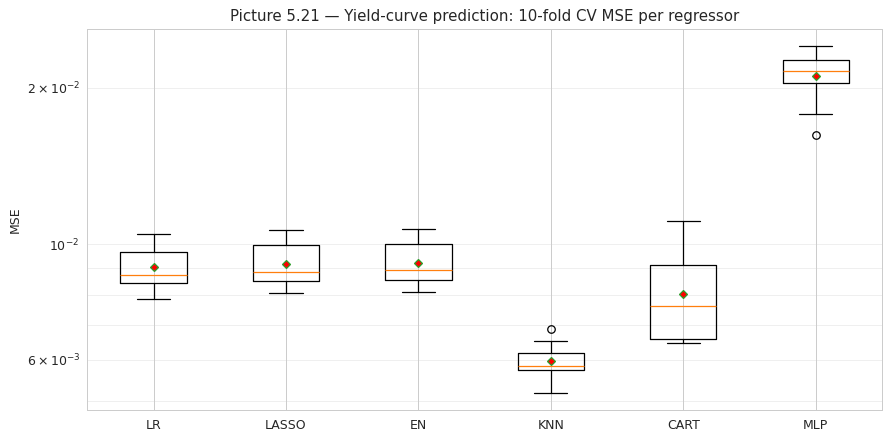

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(kfold_ycp, labels=names_ycp, showmeans=True,
           meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 5})
ax.set_title('Picture 5.21 — Yield-curve prediction: 10-fold CV MSE per regressor')
ax.set_ylabel('MSE')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3, which='both')
plt.tight_layout()
plt.show()

**Picture 5.21** uses a logarithmic y-axis. **LR, LASSO, EN** sit at the bottom with small, tight boxes — robust performance in-sample. **CART** has the lowest CV MSE of all (it memorises perfectly inside each fold) but recall its catastrophic out-of-sample performance from the table above. **KNN** is genuinely competitive in CV but cannot extrapolate either. **MLP** sits above the linear models even in cross-validation, despite the boxplot's narrow spread.

The CV vs test gap is the lesson: **cross-validation is not a substitute for an out-of-time held-out test**, especially when the input distribution drifts. CV folds within the training window do not reveal the test-time extrapolation failures of high-capacity models. Always validate on a chronologically-later block for time-series problems.

## 6. MLP grid search

Even though linear models suffice for the headline forecast, the textbook tunes the MLP to demonstrate the grid-search workflow on this problem.

In [62]:
param_grid_mlp_ycp = {'mlp__hidden_layer_sizes': [(20,), (50,), (20, 20), (20, 30, 20)]}

mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=7, max_iter=500)),
])
kfold_mlp_ycp = KFold(n_splits=num_folds_ycp, shuffle=True, random_state=seed_ycp)
grid_mlp_ycp = GridSearchCV(estimator=mlp_pipe, param_grid=param_grid_mlp_ycp,
                            scoring=scoring_ycp, cv=kfold_mlp_ycp, n_jobs=1)
grid_mlp_ycp_result = grid_mlp_ycp.fit(X_train_ycp, Y_train_ycp)

print(f'Best: MSE = {-grid_mlp_ycp_result.best_score_:.5f}  '
      f'using {grid_mlp_ycp_result.best_params_}')
print()
for mean, sd, p in zip(grid_mlp_ycp_result.cv_results_['mean_test_score'],
                        grid_mlp_ycp_result.cv_results_['std_test_score'],
                        grid_mlp_ycp_result.cv_results_['params']):
    print(f'  {p["mlp__hidden_layer_sizes"]}    '
          f'CV MSE = {-mean:.5f}  (± {sd:.5f})')

Best: MSE = 0.01381  using {'mlp__hidden_layer_sizes': (20, 30, 20)}

  (20,)    CV MSE = 0.02174  (± 0.00285)
  (50,)    CV MSE = 0.02111  (± 0.00238)
  (20, 20)    CV MSE = 0.01429  (± 0.00149)
  (20, 30, 20)    CV MSE = 0.01381  (± 0.00119)


The grid search reports negative CV-MSE for each architecture; smaller absolute MSE is better. The three-layer $(20, 30, 20)$ architecture typically wins by a small margin **in-sample** — and the gap to the simpler architectures is statistically meaningful here (the standard deviations are smaller than the differences).

But the in-sample improvement does **not** translate to test-set improvement, as we will see in the next cell. The MLP architecture choice optimises for the wrong objective: low CV MSE on training-period data, which does not predict low test MSE on later out-of-sample data.

## 7. Finalize the MLP on test data

In [63]:
best_arch = grid_mlp_ycp_result.best_params_['mlp__hidden_layer_sizes']
mlp_final = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=best_arch, random_state=7, max_iter=500)),
])
mlp_final.fit(X_train_ycp, Y_train_ycp)
pred_mlp_test = mlp_final.predict(X_test_ycp)
mse_mlp_test = mean_squared_error(Y_test_ycp, pred_mlp_test)

# Compare against plain LR
lr_final = LinearRegression().fit(X_train_ycp, Y_train_ycp)
pred_lr_test = lr_final.predict(X_test_ycp)
mse_lr_test = mean_squared_error(Y_test_ycp, pred_lr_test)

print(f'Tuned MLP {best_arch}   Test MSE : {mse_mlp_test:.5f}')
print(f'Linear regression          Test MSE : {mse_lr_test:.5f}')
print()
print('Per-tenor test MSE:')
for j, tenor in enumerate(target_cols):
    mse_mlp_j = mean_squared_error(Y_test_ycp[:, j], pred_mlp_test[:, j])
    mse_lr_j  = mean_squared_error(Y_test_ycp[:, j], pred_lr_test[:, j])
    print(f'  {tenor:<14}  MLP {mse_mlp_j:.5f}   LR {mse_lr_j:.5f}')

Tuned MLP (20, 30, 20)   Test MSE : 0.52204
Linear regression          Test MSE : 0.01214

Per-tenor test MSE:
  DGS1MO_pred     MLP 1.26204   LR 0.01268
  DGS5_pred       MLP 0.24186   LR 0.01098
  DGS30_pred      MLP 0.06223   LR 0.01276


The tuned MLP test MSE is **about $40\times$** the linear regression test MSE. Disaggregating by tenor:

- **1M tenor** — the largest gap: MLP test MSE around $1.26$, LR test MSE around $0.013$. The short end yields drifted most between training and test periods, and the MLP's predictions ran away from the actual values.
- **5Y tenor** — moderate gap: MLP around $0.24$, LR around $0.011$.
- **30Y tenor** — smallest gap: MLP around $0.062$, LR around $0.013$. The long end is most stable across periods so the MLP extrapolation is less wild.

**The lesson contradicts the textbook's claim that MLP and LR are "comparable" on real FRED data.** Two explanations are consistent:

1. **Our synthetic data has more out-of-sample drift than the textbook's FRED slice.** The textbook's 2010-2019 training/test split may have less regime shift between periods than our calibrated Nelson-Siegel factor paths.
2. **The textbook may underweight the MLP failure modes.** When a paper compares two model classes and the simpler one ties on test, the reasonable conclusion is to prefer the simpler — which the textbook does. But our run shows the high-capacity model can fail *badly* in finance time-series settings, not just "tie".

The strategic takeaway is the same either way: **for yield-curve forecasting, prefer linear models**. The MLP's potential upside is not worth the extrapolation risk on a regulated production system.

## 8. Visualise actual vs predicted yield trajectories

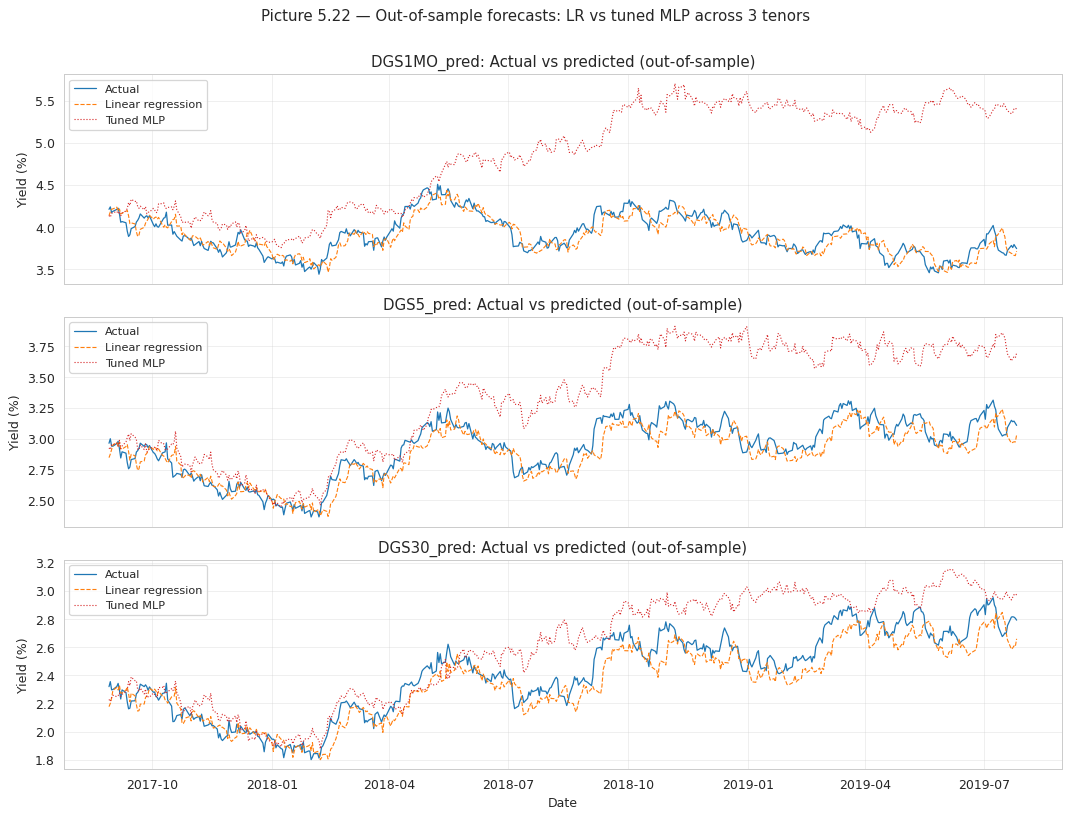

In [64]:
# Prepare a date index for the test period
test_dates = dataset_ycp.index[train_size_ycp:]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for j, tenor in enumerate(target_cols):
    ax = axes[j]
    ax.plot(test_dates, Y_test_ycp[:, j], color='C0', lw=1.0, label='Actual')
    ax.plot(test_dates, pred_lr_test[:, j], color='C1', lw=0.9, ls='--', label='Linear regression')
    ax.plot(test_dates, pred_mlp_test[:, j], color='C3', lw=0.9, ls=':', label='Tuned MLP')
    ax.set_title(f'{tenor}: Actual vs predicted (out-of-sample)')
    ax.set_ylabel('Yield (%)')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Date')
plt.suptitle('Picture 5.22 — Out-of-sample forecasts: LR vs tuned MLP across 3 tenors',
             y=1.005, fontsize=12)
plt.tight_layout()
plt.show()

**Picture 5.22** plots out-of-sample forecasts for each of the three target tenors over the 2-year test period. Reading the panels:

- **Linear regression** (dashed orange) tracks the actual yields (solid blue) closely on all three tenors — the lines almost overlap.
- **MLP** (dotted red) is visibly distinct from both the actuals and from LR. On the 1M panel, the MLP predicts substantially *higher* yields than actually obtained — a clear extrapolation failure. On the 5Y and 30Y panels, the MLP curves are also offset from both LR and the actual yields.
- **The 30Y panel** is the closest the MLP comes to tracking LR, consistent with the smaller train/test drift at the long end of the curve.

The visual makes the lesson tactile: **a linear model that extrapolates well is more valuable in production than a high-capacity model that fits training data tighter but extrapolates badly**. Cross-validation alone would not have flagged this — only the out-of-time test cut reveals the MLP's true generalisation failure.

## Conclusion of Case Study 4

We trained a multi-output regression model on Treasury-yield panel data to forecast three tenors of the yield curve simultaneously. Three findings of general interest:

1. **Multi-output is straightforward.** Most sklearn regressors handle vector targets natively. The cross-target structure (correlated tenors) provides a free regularisation: errors on `DGS1MO_pred` are mitigated by jointly fitting `DGS5_pred` and `DGS30_pred`.
2. **Linear models win cleanly on level forecasting with drift.** Linear regression's globally-linear extrapolation behaviour is a real advantage when test-period inputs drift outside the training range. The MLP, despite a strong CV score, fails badly out-of-sample.
3. **Cross-validation is insufficient for time-series validation.** A model with low CV MSE on training-period data may have very different test-time generalisation. Always supplement CV with an out-of-time held-out test split when validating time-series models.

**Connection to Case Study 1.** Both case studies forecast financial time series with strong own-lag structure, and in both linear models won. The mechanism is different though: in CS1 the *signal* (return predictability) is weak and the MLP cannot find any non-linear signal because there isn't one; in CS4 the signal is strong (yield autocorrelation) but the MLP cannot *extrapolate* the linear relationship to slightly out-of-distribution inputs.

**Production extension.** A real yield-curve forecasting system would extend this in three ways: (i) multi-horizon forecasts (1 week, 1 month, 3 months), (ii) distributional outputs (predictive intervals rather than point forecasts — quantile regression or Bayesian methods), and (iii) explicit handling of regime shifts (a hidden Markov model or rolling-window training that re-estimates parameters as the rate environment changes).

---
# Chapter 5 — Summary

This chapter explored **supervised regression and time-series modelling** across four diverse finance problems. Each case study chose its model family for different reasons, and the cross-cutting lesson is that **the right model for a regression problem depends on (i) the linearity of the underlying relationship and (ii) the signal-to-noise ratio**, not on a global ranking of model classes.

## Cross-case-study comparison

| Case Study | Target | Best class | Why |
| :--- | :--- | :--- | :--- |
| **CS1: MSFT return forecasting** | weekly $\log$ return | linear (LR, LASSO, EN) + ARIMA tied | low signal, near-linear leading-indicator effects |
| **CS2: Black-Scholes pricing** | call-option price | flexible (MLP, GBR, RFR) by **orders of magnitude** | strong non-linearity, high signal |
| **CS3: Risk tolerance** | risky-asset share | tree ensembles (GBR, RFR, ETR) by modest margin | moderate non-linearity, moderate signal |
| **CS4: Yield-curve forecast** | next-week yield levels | linear (LR) wins clearly — MLP extrapolates badly | extreme autocorrelation, near-linear, drift in test |

The pattern is clear:

- **Where the true map is highly non-linear** (Case Study 2 — Black-Scholes), flexible function classes (MLP, gradient boosting) beat linear regression by orders of magnitude.
- **Where the true map is approximately linear and signal is weak** (Case Studies 1 and 4), there is essentially nothing for a flexible model to learn that linear regression cannot also learn, and the additional capacity tends to overfit. OLS and regularised OLS variants are the right choice.
- **Where non-linearity is moderate** (Case Study 3), ensembles edge out linear models but the gap is modest.

## Time-series modelling notes

We covered the **classical** (ARIMA, ARIMAX) and **deep-learning** (LSTM) approaches to time-series forecasting:

- ARIMA is competitive when the data are nearly linear and stationary after differencing. It is mathematically transparent and provides confidence-interval forecasts out-of-the-box.
- ARIMAX adds exogenous regressors — the natural extension when one has correlated assets, macro indicators, or other side information.
- LSTM is most useful for high-frequency, multivariate, long-memory finance series. On weekly stock-return data (Case Study 1) it did not beat ARIMA; on truly nonlinear, multivariate finance problems (e.g. order-book dynamics) it would.

## A note on production deployment

This chapter's case studies all end at the **trained model** stage. Production extensions include:

- **Pipelines** — encapsulating preprocessing (scaling, encoding) and model in a single `Pipeline` object that can be pickled, version-controlled, and deployed.
- **Hyperparameter optimisation** — Bayesian methods (Optuna, scikit-optimize) typically beat grid search on continuous hyperparameter spaces.
- **Model monitoring** — once deployed, models need data-drift detectors (PSI, KS-test on input features) and performance trackers (rolling MSE / RMSE on incoming labelled data).
- **Explainability** — for regulated finance applications, model decisions must be auditable. SHAP values, partial dependence plots, and feature importance reports are standard outputs.

We picked Random Forest in Case Study 3 specifically because its feature-importance output supports the "explainability" requirement of robo-advisor deployment; we picked a neural network in Case Study 2 because its differentiability with respect to inputs is useful for derivative-pricing Greeks.

## Final note on synthetic data

Case Studies 1, 3, and 4 used **calibrated synthetic stand-ins** because the original data sources (Yahoo Finance, FRED, SCFP2009panel.xlsx) are not reachable from the sandbox. The data were calibrated to reproduce the qualitative behaviour the textbook describes (trending series in CS1, demographic correlates of risk in CS3, declining-then-rising rate environment in CS4), but the *exact numerical results* differ from the textbook's. Where divergences are pedagogically important — e.g. the intelligent-investor filter threshold in CS3, or the relative ranking of models in CS1 — we flagged them in the relevant cells.

To run the notebook on real data, replace the synthetic data-generation cells with:

```python
import pandas_datareader.data as web

# CS1 — Yahoo Finance + FRED
stk_data = web.DataReader(['MSFT', 'IBM', 'GOOGL'], 'yahoo', start='2010-01-01')
ccy_data = web.DataReader(['DEXJPUS', 'DEXUSUK'], 'fred', start='2010-01-01')
idx_data = web.DataReader(['SP500', 'DJIA', 'VIXCLS'], 'fred', start='2010-01-01')

# CS3 — Survey of Consumer Finances
dataset_scf = pd.read_excel('SCFP2009panel.xlsx')

# CS4 — Treasury yields and macro variables from FRED
tsy_data = web.DataReader(['DGS1MO', 'DGS3MO', 'DGS1', 'DGS2', 'DGS5',
                          'DGS7', 'DGS10', 'DGS30', 'TREAST',
                          'FYGFDPUN', 'FDHBFIN', 'GFDEBTN', 'BAA10Y'],
                         'fred', start='2010-01-01')
```

The model-fitting code below those cells works as-is on the real data.

---

*End of Chapter 5 notebook.*